# LAB016–LAB018 external holdout — frozen natural-must model

This notebook asks whether the **currently calibrated natural-must model** generalizes to LAB016/F1, LAB017/F2 and LAB018/F3 without using those experiments to estimate anything. The protocol is deliberately predictive: the natural kinetic parameter vector, the CO2 layer and every learned gain/activation/release parameter are loaded from their existing artifacts and kept frozen. No optimizer, profiling, offset correction or initial-condition adjustment is called.

The biological clock is `t = 0 = end of the real inoculation pump pulse`. Negative times are retained only for instrumental QC. Two predeclared ethanol scenarios are evaluated: **A**, `E0 = 0 g/L` (physical assumption at inoculation), and **B**, the median historical `E0` read from the LAB004–LAB012 calibration summary.


In [1]:
from pathlib import Path
from dataclasses import replace
import hashlib
import inspect
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

%matplotlib inline
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 110)

ROOT = Path.cwd().resolve()
while ROOT.name != 'pyomo-doe' and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if ROOT.name != 'pyomo-doe':
    raise RuntimeError(f'Project root pyomo-doe not found from {Path.cwd()}')
FM = ROOT / 'fermentation_model'
LAB_DIR = FM / 'laboratory_2026'
PILOT_DIR = FM / 'pilot_2025'
DATA_DIR = FM / 'data' / 'mem2026' / 'LAB016-018'
for path in (FM, LAB_DIR, PILOT_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from shared import run_new_must_glycerol_estimability_doe as base
from laboratory_2026 import run_co2_matrix_cross_validation_2026 as co2_cross

THETA_PATH = LAB_DIR / 'results' / 'estimability_historical_natural' / 'theta.csv'
HISTORICAL_BATCH_SUMMARY_PATH = LAB_DIR / 'results' / 'estimability_historical_natural' / 'batch_summary.csv'
CO2_PARAMETER_PATH = LAB_DIR / 'results' / 'co2_matrix_cross_validation_2026' / 'fit_parameters.csv'
WORKBOOK_PATH = DATA_DIR / 'LAB016-018-offline-measurements.xlsx'
PRIOR_MASK_NOTEBOOK = LAB_DIR / 'notebooks' / 'lab016_018_co2_temperature_visualization.ipynb'

LABS = {
    'LAB016': {'fermenter': 'F1', 'co2_raw': 'CO2_F1_LAB016.csv', 'co2_filt': 'CO2_FILT_F1_LAB016.csv', 'temp': 'Temp_F1_LAB016.csv'},
    'LAB017': {'fermenter': 'F2', 'co2_raw': 'CO2_F2_LAB017.csv', 'co2_filt': 'CO2_FILT_F2_LAB017.csv', 'temp': 'Temp_F2_LAB017.csv'},
    # The extra dot in the F3 temperature filename is literal on disk.
    'LAB018': {'fermenter': 'F3', 'co2_raw': 'CO2_F3_LAB018.csv', 'co2_filt': 'CO2_FILT_F3_LAB018.csv', 'temp': 'Temp_F3._LAB018.csv'},
}

def sha256(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

protected_paths = [THETA_PATH, CO2_PARAMETER_PATH, WORKBOOK_PATH]
for spec in LABS.values():
    protected_paths.extend(DATA_DIR / spec[key] for key in ('co2_raw', 'co2_filt', 'temp'))
HASHES_BEFORE = {str(path.relative_to(ROOT)): sha256(path) for path in protected_paths}
print('Python:', sys.executable)
print('Project root:', ROOT)
print('Protected input hashes recorded:', len(HASHES_BEFORE))


Python: D:\anaconda3\envs\fermentation\python.exe
Project root: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe
Protected input hashes recorded: 12


## 1. Frozen model and parameter provenance

The kinetic implementation is reused from `shared/run_new_must_glycerol_estimability_doe.py`. Its `simulate` routine integrates the existing ODEs and applies only explicitly supplied, known input pulses. The CO2 driver/cache and gas-release prediction are reused from `run_co2_matrix_cross_validation_2026.py`; internally that cache calls the existing `co2_production_g_l_h` function from the pilot CO2 module.


In [2]:
theta_artifact = pd.read_csv(THETA_PATH)
theta_frozen = co2_cross._load_theta(THETA_PATH)

theta_rows = []
artifact_by_name = theta_artifact.set_index('parameter')
for name, value in theta_frozen.items():
    if name in artifact_by_name.index:
        prior_reestimated = bool(artifact_by_name.loc[name, 'reestimated_in_this_notebook'])
        status = 'estimated in prior natural calibration; frozen here' if prior_reestimated else 'fixed in prior natural artifact; frozen here'
        source = str(THETA_PATH.relative_to(ROOT))
    else:
        status = 'fixed base.DEFAULT_THETA value; frozen here'
        source = str(Path(inspect.getsourcefile(base)).relative_to(ROOT)) + ': DEFAULT_THETA'
    theta_rows.append({'parameter': name, 'theta': value, 'status': status, 'source': source})
theta_inventory = pd.DataFrame(theta_rows)

co2_parameter_artifact = pd.read_csv(CO2_PARAMETER_PATH)
co2_parameter_inventory = co2_parameter_artifact.loc[
    co2_parameter_artifact['calibration_matrix'].eq('natural'),
    ['parameter', 'estimate', 'lower_bound', 'upper_bound', 'active_bound']
].copy()
co2_parameters_frozen = dict(zip(co2_parameter_inventory['parameter'], co2_parameter_inventory['estimate']))
required_co2_parameters = {
    'kCO2_release_h', 'CO2sat_scale', 'O2_qmax_mg_gdw_h', 'O2_initial_scale',
    'pulse_t_rise_h', 'pulse_activity_gain', 'chem_activation_start_fraction',
    'chem_activation_duration_fraction', 'matrix_gain',
}
assert required_co2_parameters == set(co2_parameters_frozen)

function_inventory = pd.DataFrame([
    {'function': 'base.simulate', 'source_file': inspect.getsourcefile(base.simulate), 'role': 'frozen kinetic ODE simulation'},
    {'function': 'base.temperature_at', 'source_file': inspect.getsourcefile(base.temperature_at), 'role': 'measured-temperature input interpolation'},
    {'function': 'base.initial_vector', 'source_file': inspect.getsourcefile(base.initial_vector), 'role': 'state-vector construction'},
    {'function': 'co2_cross.build_driver_cache', 'source_file': inspect.getsourcefile(co2_cross.build_driver_cache), 'role': 'fixed upstream and CO2 driver cache'},
    {'function': 'co2_cross.raw_qgas_grid_prediction', 'source_file': inspect.getsourcefile(co2_cross.raw_qgas_grid_prediction), 'role': 'fixed solubility/release prediction'},
    {'function': 'co2_cross._chemical_activity_bracket', 'source_file': inspect.getsourcefile(co2_cross._chemical_activity_bracket), 'role': 'existing chemistry-only activation anchor'},
])
function_inventory['source_file'] = function_inventory['source_file'].map(lambda p: str(Path(p).resolve().relative_to(ROOT)))

print('Natural theta loaded exactly from:', THETA_PATH.relative_to(ROOT))
print('Natural CO2 model:', co2_cross.MODEL_NAME)
print('Natural CO2 parameters loaded exactly from:', CO2_PARAMETER_PATH.relative_to(ROOT))
print('All values below are FROZEN. No fitting/optimization routine is invoked.')
display(theta_inventory)
print('Additional fixed kinetic constants:')
display(pd.DataFrame([{'constant': k, 'value': v} for k, v in base.FIXED_CONSTANTS.items()]))
print('Frozen natural CO2 layer:')
display(co2_parameter_inventory)
print('Reused functions:')
display(function_inventory)


Natural theta loaded exactly from: fermentation_model\laboratory_2026\results\estimability_historical_natural\theta.csv
Natural CO2 model: solubility_o2_nitrogen_boost_continuous_release
Natural CO2 parameters loaded exactly from: fermentation_model\laboratory_2026\results\co2_matrix_cross_validation_2026\fit_parameters.csv
All values below are FROZEN. No fitting/optimization routine is invoked.


,parameter,theta,status,source
0,mu0,0.078728,estimated in prior natural calibration; frozen here,fermentation_model\laboratory_2026\results\estimability_historical_natural\theta.csv
1,sN,18.000000,fixed base.DEFAULT_THETA value; frozen here,fermentation_model\shared\run_new_must_glycerol_estimability_doe.py: DEFAULT_THETA
2,qN,0.021080,estimated in prior natural calibration; frozen here,fermentation_model\laboratory_2026\results\estimability_historical_natural\theta.csv
3,qXG,0.112500,fixed base.DEFAULT_THETA value; frozen here,fermentation_model\shared\run_new_must_glycerol_estimability_doe.py: DEFAULT_THETA
4,qXF,0.112500,fixed base.DEFAULT_THETA value; frozen here,fermentation_model\shared\run_new_must_glycerol_estimability_doe.py: DEFAULT_THETA
5,betaG0,0.428878,estimated in prior natural calibration; frozen here,fermentation_model\laboratory_2026\results\estimability_historical_natural\theta.csv
6,sG,0.030000,fixed base.DEFAULT_THETA value; frozen here,fermentation_model\shared\run_new_must_glycerol_estimability_doe.py: DEFAULT_THETA
7,betaF0,3.440399,estimated in prior natural calibration; frozen here,fermentation_model\laboratory_2026\results\estimability_historical_natural\theta.csv
8,sF,0.030000,fixed base.DEFAULT_THETA value; frozen here,fermentation_model\shared\run_new_must_glycerol_estimability_doe.py: DEFAULT_THETA
9,qEG,1.712807,estimated in prior natural calibration; frozen here,fermentation_model\laboratory_2026\results\estimability_historical_natural\theta.csv


Additional fixed kinetic constants:


,constant,value
0,Cde,0.0415
1,Etd,130000.0000
2,R,8.3140
3,Eac,59453.0000
4,Eafe,11000.0000
5,EaKn,46055.0000
6,EaKg,46055.0000
7,EaKf,46055.0000
8,EaKig,46055.0000
9,EaKie,46055.0000


Frozen natural CO2 layer:


,parameter,estimate,lower_bound,upper_bound,active_bound
9,kCO2_release_h,0.424588,0.03,25.00,False
10,CO2sat_scale,0.351389,0.35,2.50,True
11,O2_qmax_mg_gdw_h,0.150000,0.15,6.00,True
12,O2_initial_scale,0.195400,0.05,1.50,False
13,pulse_t_rise_h,64.658714,1.00,72.00,False
14,pulse_activity_gain,0.250000,0.25,4.00,True
15,chem_activation_start_fraction,0.735057,0.01,0.95,False
16,chem_activation_duration_fraction,1.063910,0.35,2.00,False
17,matrix_gain,3.115757,0.10,20.00,False


Reused functions:


,function,source_file,role
0,base.simulate,fermentation_model\shared\run_new_must_glycerol_estimability_doe.py,frozen kinetic ODE simulation
1,base.temperature_at,fermentation_model\shared\run_new_must_glycerol_estimability_doe.py,measured-temperature input interpolation
2,base.initial_vector,fermentation_model\shared\run_new_must_glycerol_estimability_doe.py,state-vector construction
3,co2_cross.build_driver_cache,fermentation_model\laboratory_2026\run_co2_matrix_cross_validation_2026.py,fixed upstream and CO2 driver cache
4,co2_cross.raw_qgas_grid_prediction,fermentation_model\laboratory_2026\run_co2_matrix_cross_validation_2026.py,fixed solubility/release prediction
5,co2_cross._chemical_activity_bracket,fermentation_model\laboratory_2026\run_co2_matrix_cross_validation_2026.py,existing chemistry-only activation anchor


## 2. LAB016–LAB018 data inventory

The workbook and both offline files contain Brix, density, sample temperature and residual volume, but no measurements of `X`, `Xd`, `N/YAN`, `G`, `F`, `E`, `Gly` or `O2` during these fermentations. The `CondicionesIniciales` sheet contains proxy starting values inherited from the same must (LAB013-2/LAB014-2/LAB015-2, excluding PI), not direct LAB016–LAB018 assays. Repository inspection found aligned copies of the same sensor series but no additional state-observation source for these three LABs. Therefore Brix/density are retained as measured QC variables and are **not** treated as `G`, `F` or `G+F`: no validated observation function exists in the current pipeline.


In [3]:
excel = pd.ExcelFile(WORKBOOK_PATH)
offline = pd.read_excel(WORKBOOK_PATH, sheet_name='MedicionesOffline')
experiments = pd.read_excel(WORKBOOK_PATH, sheet_name='Experimentos')
initial_sheet = pd.read_excel(WORKBOOK_PATH, sheet_name='CondicionesIniciales')
offline_csv = pd.read_csv(DATA_DIR / 'LAB016-018-offline-measurements.csv')

signals = {}
inventory_rows = []
for lab, spec in LABS.items():
    signals[lab] = {
        'fermenter': spec['fermenter'],
        'co2_raw': pd.read_csv(DATA_DIR / spec['co2_raw'], parse_dates=['timestamp']),
        'co2_filt': pd.read_csv(DATA_DIR / spec['co2_filt'], parse_dates=['timestamp']),
        'temp': pd.read_csv(DATA_DIR / spec['temp'], parse_dates=['timestamp']),
    }
    for key in ('co2_raw', 'co2_filt', 'temp'):
        frame = signals[lab][key]
        inventory_rows.append({
            'LAB': lab, 'fermenter': spec['fermenter'], 'kind': key, 'file': spec[key],
            'rows': len(frame), 'start': frame['timestamp'].min(), 'end': frame['timestamp'].max(),
            'columns': ', '.join(frame.columns),
        })
sensor_inventory = pd.DataFrame(inventory_rows)
observable_inventory = pd.DataFrame([
    {'available_quantity': 'filtered CO2 flow (SCCM)', 'source': 'CO2_FILT_*', 'model correspondence': 'CO2 layer output after official in-memory unit conversion', 'used in holdout metrics': True},
    {'available_quantity': 'reactor temperature (degC)', 'source': 'Temp_*: T', 'model correspondence': 'known exogenous temperature input, not a predicted state', 'used in holdout metrics': False},
    {'available_quantity': 'Brix', 'source': 'MedicionesOffline', 'model correspondence': 'none validated for G/F/G+F', 'used in holdout metrics': False},
    {'available_quantity': 'density (g/L)', 'source': 'MedicionesOffline', 'model correspondence': 'none validated for G/F/G+F', 'used in holdout metrics': False},
    {'available_quantity': 'sample temperature / residual volume', 'source': 'MedicionesOffline', 'model correspondence': 'QC/context only', 'used in holdout metrics': False},
    {'available_quantity': 'X, Xd, N/YAN, G, F, E, Gly, O2 time series', 'source': 'not present', 'model correspondence': 'core states', 'used in holdout metrics': False},
])
print('Workbook sheets:', excel.sheet_names)
print('Offline Excel rows:', len(offline), '| duplicate CSV rows:', len(offline_csv))
display(sensor_inventory)
display(observable_inventory)
display(initial_sheet)


Workbook sheets: ['MedicionesOffline', 'Experimentos', 'CondicionesIniciales']
Offline Excel rows: 24 | duplicate CSV rows: 24


,LAB,fermenter,kind,file,rows,start,end,columns
0,LAB016,F1,co2_raw,CO2_F1_LAB016.csv,47785,2026-08-31 17:17:29,2026-09-07 08:09:56,"timestamp, fermentador, flow_sccm, status"
1,LAB016,F1,co2_filt,CO2_FILT_F1_LAB016.csv,47785,2026-08-31 17:17:29,2026-09-07 08:09:56,"timestamp, fermentador, flow_filt_sccm, status, is_spike"
2,LAB016,F1,temp,Temp_F1_LAB016.csv,95143,2026-08-31 17:17:27,2026-09-07 08:09:55,"timestamp, fermentador, T, SP, banda, cold, hot, nutricion_activa, freq_nut"
3,LAB017,F2,co2_raw,CO2_F2_LAB017.csv,47788,2026-08-31 17:16:58,2026-09-07 08:09:56,"timestamp, fermentador, flow_sccm, status"
4,LAB017,F2,co2_filt,CO2_FILT_F2_LAB017.csv,47787,2026-08-31 17:17:09,2026-09-07 08:09:56,"timestamp, fermentador, flow_filt_sccm, status, is_spike"
5,LAB017,F2,temp,Temp_F2_LAB017.csv,95153,2026-08-31 17:16:54,2026-09-07 08:09:55,"timestamp, fermentador, T, SP, banda, cold, hot, nutricion_activa, freq_nut"
6,LAB018,F3,co2_raw,CO2_F3_LAB018.csv,47788,2026-08-31 17:16:58,2026-09-07 08:09:56,"timestamp, fermentador, flow_sccm, status"
7,LAB018,F3,co2_filt,CO2_FILT_F3_LAB018.csv,47788,2026-08-31 17:16:58,2026-09-07 08:09:56,"timestamp, fermentador, flow_filt_sccm, status, is_spike"
8,LAB018,F3,temp,Temp_F3._LAB018.csv,95154,2026-08-31 17:16:51,2026-09-07 08:09:56,"timestamp, fermentador, T, SP, banda, cold, hot, nutricion_activa, freq_nut"


,available_quantity,source,model correspondence,used in holdout metrics
0,filtered CO2 flow (SCCM),CO2_FILT_*,CO2 layer output after official in-memory unit conversion,True
1,reactor temperature (degC),Temp_*: T,"known exogenous temperature input, not a predicted state",False
2,Brix,MedicionesOffline,none validated for G/F/G+F,False
3,density (g/L),MedicionesOffline,none validated for G/F/G+F,False
4,sample temperature / residual volume,MedicionesOffline,QC/context only,False
5,"X, Xd, N/YAN, G, F, E, Gly, O2 time series",not present,core states,False


,CodigoLab,Fermentador,Lote_Mosto,Fecha,Hora,Glucosa_g_L,Fructosa_g_L,YAN_mg_L,Etanol_g_L,Glicerol_g_L,Fuente,Observaciones
0,LAB016,F1,NaN,2026-09-01,00:03:55,74.05,77.73,244.33,NaN,1.14,Heredado: promedio LAB013-2/LAB014-2/LAB015-2 de Y15_LAB013-015.txt,"Condición inicial heredada del mismo mosto: promedio de las primeras muestras de reactor LAB013-2, LAB014-..."
1,LAB017,F2,NaN,2026-09-01,00:04:00,74.05,77.73,244.33,NaN,1.14,Heredado: promedio LAB013-2/LAB014-2/LAB015-2 de Y15_LAB013-015.txt,"Condición inicial heredada del mismo mosto: promedio de las primeras muestras de reactor LAB013-2, LAB014-..."
2,LAB018,F3,NaN,2026-09-01,00:04:07,74.05,77.73,244.33,NaN,1.14,Heredado: promedio LAB013-2/LAB014-2/LAB015-2 de Y15_LAB013-015.txt,"Condición inicial heredada del mismo mosto: promedio de las primeras muestras de reactor LAB013-2, LAB014-..."


## 3. Real inoculation clock, pulse ledger and faithful CO2 artifact mask

The workbook timestamp is independently checked against the falling edge of `nutricion_activa`. The pulse ending at that timestamp is the inoculation, not a nitrogen addition. Later events near 57 h are only **possible nutrition** because neither composition nor dose is documented. Consequently the core receives no invented N jump, and interpretation after the first such event is explicitly conditional.

The artifact mask reconstructs the earlier audit's criterion: preceding 1200 s raw-CO2 baseline, robust Hampel threshold `max(3.5 × sigma, 0.5 SCCM)`, event interval through 120 s after pump-off, and a common causal-filter recovery tail estimated from the isolated low-CO2 reference pulse. Its 95th percentile is rounded upward and must reproduce 90 min. Only `nutricion_activa` events crossing the raw threshold trigger exclusion. Points are flagged, never deleted.


In [4]:
def combine_date_time(date_value, time_value):
    date_part = pd.Timestamp(date_value).date()
    if not hasattr(time_value, 'hour'):
        time_value = pd.to_datetime(str(time_value)).time()
    return pd.Timestamp.combine(date_part, time_value)

initial_sheet['timestamp_inoculation'] = initial_sheet.apply(
    lambda row: combine_date_time(row['Fecha'], row['Hora']), axis=1
)
T0_BY_LAB = dict(zip(initial_sheet['CodigoLab'], initial_sheet['timestamp_inoculation']))

HAMPEL_WINDOW_S = 120.0
HAMPEL_K = 3.5
HAMPEL_MIN_ABS_SCCM = 0.5
IIR_TAU_S = 1200.0
IIR_ORDER = 3

def extract_binary_pulses(lab, temp):
    state = pd.to_numeric(temp['nutricion_activa'], errors='raise').astype(int)
    if not set(state.unique()).issubset({0, 1}):
        raise ValueError(f'{lab}: nutricion_activa is not binary')
    rising = state.eq(1) & ~state.shift(fill_value=0).eq(1)
    falling = state.eq(0) & state.shift(fill_value=0).eq(1)
    starts = np.flatnonzero(rising.to_numpy())
    falls = np.flatnonzero(falling.to_numpy())
    median_dt_s = float(temp['timestamp'].diff().dt.total_seconds().median())
    rows = []
    for number, start_i in enumerate(starts, start=1):
        fall_position = np.searchsorted(falls, start_i + 1)
        has_fall = fall_position < len(falls)
        start = temp['timestamp'].iloc[start_i]
        end = temp['timestamp'].iloc[falls[fall_position]] if has_fall else temp['timestamp'].iloc[-1] + pd.to_timedelta(median_dt_s, unit='s')
        rows.append({
            'LAB': lab, 'fermenter': LABS[lab]['fermenter'], 'pulse_number': number,
            'rising_edge_observed': bool(start_i > 0), 'falling_edge_observed': bool(has_fall),
            'pulse_start': start, 'pulse_end': end,
            'duration_min': (end - start).total_seconds() / 60.0,
        })
    return pd.DataFrame(rows)

pulse_table = pd.concat([extract_binary_pulses(lab, signals[lab]['temp']) for lab in LABS], ignore_index=True)
pulse_table['t0'] = pulse_table['LAB'].map(T0_BY_LAB)
pulse_table['pulse_start_h'] = (pulse_table['pulse_start'] - pulse_table['t0']).dt.total_seconds() / 3600.0
pulse_table['pulse_end_h'] = (pulse_table['pulse_end'] - pulse_table['t0']).dt.total_seconds() / 3600.0

def classify_pulse(row):
    if abs(row['pulse_end_h']) <= 5.0 / 3600.0:
        return 'inoculation (defines t=0; not nutrition)'
    if row['pulse_end_h'] < 0:
        return 'pre-inoculation / commissioning'
    if row['pulse_start_h'] >= 48.0:
        return 'possible later nutrition; dose unknown; not modeled'
    return 'unresolved post-inoculation process/sampling pulse; not modeled'

pulse_table['classification'] = pulse_table.apply(classify_pulse, axis=1)
for lab in LABS:
    lab_pulses = pulse_table[pulse_table['LAB'].eq(lab)]
    matches = lab_pulses['pulse_end'].eq(T0_BY_LAB[lab])
    assert matches.sum() == 1, f'{lab}: t0 does not match exactly one pump falling edge'
FIRST_POSSIBLE_NUTRITION_H = (
    pulse_table[pulse_table['classification'].str.startswith('possible later nutrition')]
    .groupby('LAB')['pulse_start_h'].min().to_dict()
)

def score_pulse_against_raw(row):
    raw = signals[row['LAB']]['co2_raw'].sort_values('timestamp')
    ts_ns = raw['timestamp'].astype('int64').to_numpy()
    values = raw['flow_sccm'].to_numpy(dtype=float)
    start_ns, end_ns = pd.Timestamp(row['pulse_start']).value, pd.Timestamp(row['pulse_end']).value
    p0, p1 = np.searchsorted(ts_ns, [start_ns - int(IIR_TAU_S * 1e9), start_ns])
    e0 = np.searchsorted(ts_ns, start_ns)
    e1 = np.searchsorted(ts_ns, end_ns + int(HAMPEL_WINDOW_S * 1e9), side='right')
    pre, event = values[p0:p1], values[e0:e1]
    baseline_span_min = (ts_ns[p1 - 1] - ts_ns[p0]) / 60e9 if len(pre) >= 2 else np.nan
    if len(pre) < 3 or len(event) == 0:
        return pd.Series({'baseline_raw_sccm': np.nan, 'baseline_sigma_sccm': np.nan, 'artifact_threshold_sccm': np.nan, 'peak_deviation_sccm': np.nan, 'event_score': np.nan, 'artifact_candidate': pd.NA, 'artifact_onset': pd.NaT, 'baseline_span_min': baseline_span_min})
    baseline = float(np.median(pre))
    sigma = float(1.4826 * np.median(np.abs(pre - baseline)))
    threshold = max(HAMPEL_K * sigma, HAMPEL_MIN_ABS_SCCM)
    deviation = np.abs(event - baseline)
    crossings = np.flatnonzero(deviation > threshold)
    detected = bool(len(crossings))
    onset = pd.to_datetime(ts_ns[e0 + crossings[0]]) if detected else pd.NaT
    return pd.Series({'baseline_raw_sccm': baseline, 'baseline_sigma_sccm': sigma, 'artifact_threshold_sccm': threshold, 'peak_deviation_sccm': float(deviation.max()), 'event_score': float(deviation.max() / threshold), 'artifact_candidate': detected, 'artifact_onset': onset, 'baseline_span_min': baseline_span_min})

pulse_scores = pd.concat([pulse_table, pulse_table.apply(score_pulse_against_raw, axis=1)], axis=1)
pulse_scores['artifact_candidate'] = pulse_scores['artifact_candidate'].astype('boolean')
eligible_reference = pulse_scores['artifact_candidate'].fillna(False) & pulse_scores['baseline_span_min'].ge(0.95 * IIR_TAU_S / 60.0)
reference_events = (pulse_scores.loc[eligible_reference].assign(baseline_abs=lambda d: d['baseline_raw_sccm'].abs()).sort_values(['LAB', 'baseline_abs', 'pulse_start']).groupby('LAB', group_keys=False).head(1))
assert set(reference_events['LAB']) == set(LABS)

def estimate_filtered_recovery(row):
    raw = signals[row['LAB']]['co2_raw'].sort_values('timestamp').copy()
    filt = signals[row['LAB']]['co2_filt'].sort_values('timestamp').copy()
    raw_dt_s = float(raw['timestamp'].diff().dt.total_seconds().median())
    filt_dt_s = float(filt['timestamp'].diff().dt.total_seconds().median())
    min_periods = max(3, int(round((IIR_TAU_S / raw_dt_s) / 4.0)))
    raw_trend = raw.set_index('timestamp')['flow_sccm'].rolling(f'{int(IIR_TAU_S)}s', center=True, min_periods=min_periods).median()
    trend_frame = raw_trend.rename('raw_robust_trend_sccm').dropna().reset_index()
    aligned = pd.merge_asof(filt, trend_frame, on='timestamp', direction='nearest', tolerance=pd.to_timedelta(raw_dt_s, unit='s')).dropna(subset=['raw_robust_trend_sccm'])
    aligned['filter_residual_sccm'] = aligned['flow_filt_sccm'] - aligned['raw_robust_trend_sccm']
    start, end = row['pulse_start'], row['pulse_end']
    pre = aligned.loc[aligned['timestamp'].between(start - pd.to_timedelta(IIR_TAU_S, unit='s'), start, inclusive='left'), 'filter_residual_sccm']
    center = float(pre.median())
    sigma = float(1.4826 * np.median(np.abs(pre - center)))
    tolerance = max(HAMPEL_K * sigma, HAMPEL_MIN_ABS_SCCM)
    post = aligned.loc[aligned['timestamp'].ge(end)].copy()
    post['compatible'] = post['filter_residual_sccm'].sub(center).abs().le(tolerance)
    sustain_n = max(1, int(round(IIR_TAU_S / filt_dt_s)))
    fraction = post['compatible'].rolling(sustain_n, min_periods=sustain_n).mean()
    endings = np.flatnonzero(fraction.to_numpy() >= 0.90)
    if not len(endings):
        return pd.Series({'recovery_start': pd.NaT, 'recovery_after_pulse_end_min': np.nan, 'recovery_tolerance_sccm': tolerance})
    recovery_i = max(0, int(endings[0]) - sustain_n + 1)
    recovery = post['timestamp'].iloc[recovery_i]
    return pd.Series({'recovery_start': recovery, 'recovery_after_pulse_end_min': (recovery - end).total_seconds() / 60.0, 'recovery_tolerance_sccm': tolerance})

recovery_diagnostics = pd.concat([reference_events.reset_index(drop=True), reference_events.apply(estimate_filtered_recovery, axis=1).reset_index(drop=True)], axis=1)
assert recovery_diagnostics['recovery_after_pulse_end_min'].notna().all()
COMMON_RECOVERY_MIN = int(np.ceil(recovery_diagnostics['recovery_after_pulse_end_min'].quantile(0.95)))
assert COMMON_RECOVERY_MIN == 90, f'Faithful mask audit no longer reproduces 90 min (got {COMMON_RECOVERY_MIN})'

artifact_table = pulse_scores.copy()
artifact_table['artifact_detected'] = artifact_table['artifact_candidate'].astype('boolean')
artifact_table['artifact_start'] = artifact_table['artifact_onset']
artifact_table['artifact_end'] = pd.NaT
detected = artifact_table['artifact_detected'].fillna(False)
artifact_table.loc[detected, 'artifact_end'] = artifact_table.loc[detected, 'pulse_end'] + pd.to_timedelta(COMMON_RECOVERY_MIN, unit='min')

def merge_windows(frame):
    merged = []
    for start, end in sorted(zip(frame['artifact_start'], frame['artifact_end'])):
        if not merged or start > merged[-1][1]:
            merged.append([start, end])
        else:
            merged[-1][1] = max(merged[-1][1], end)
    return [(start, end) for start, end in merged]

EXCLUSION_WINDOWS = {}
mask_audit_rows = []
for lab in LABS:
    co2 = signals[lab]['co2_filt']
    t0 = T0_BY_LAB[lab]
    co2['time_h'] = (co2['timestamp'] - t0).dt.total_seconds() / 3600.0
    signals[lab]['temp']['time_h'] = (signals[lab]['temp']['timestamp'] - t0).dt.total_seconds() / 3600.0
    lab_detected = artifact_table[artifact_table['LAB'].eq(lab) & artifact_table['artifact_detected'].fillna(False)]
    EXCLUSION_WINDOWS[lab] = merge_windows(lab_detected)
    co2['co2_valid_for_fitting'] = True
    for start, end in EXCLUSION_WINDOWS[lab]:
        co2.loc[co2['timestamp'].between(start, end, inclusive='both'), 'co2_valid_for_fitting'] = False
    mask_audit_rows.append({'LAB': lab, 'excluded_pct_all_record': 100.0 * (~co2['co2_valid_for_fitting']).sum() / len(co2), 'n_exclusion_windows': len(EXCLUSION_WINDOWS[lab])})
mask_audit = pd.DataFrame(mask_audit_rows)

t0_table = pd.DataFrame([{'LAB': lab, 'fermenter': LABS[lab]['fermenter'], 't0_inoculation': T0_BY_LAB[lab], 'verification': 'exactly matches pump falling edge', 'first_possible_nutrition_h': FIRST_POSSIBLE_NUTRITION_H[lab]} for lab in LABS])
display(t0_table)
display(pulse_table[['LAB', 'fermenter', 'pulse_start', 'pulse_end', 'pulse_start_h', 'pulse_end_h', 'duration_min', 'classification']].round(4))
print('Reference-event recovery audit; P95 rounded up =', COMMON_RECOVERY_MIN, 'min')
display(recovery_diagnostics[['LAB', 'pulse_start_h', 'duration_min', 'recovery_after_pulse_end_min', 'recovery_tolerance_sccm']].round(4))
print('Faithful all-record mask check (matches the prior ~3.57%, 2.47%, 3.36% audit):')
display(mask_audit.round(4))


,LAB,fermenter,t0_inoculation,verification,first_possible_nutrition_h
0,LAB016,F1,2026-09-01 00:03:55,exactly matches pump falling edge,56.935556
1,LAB017,F2,2026-09-01 00:04:00,exactly matches pump falling edge,56.933611
2,LAB018,F3,2026-09-01 00:04:07,exactly matches pump falling edge,56.931667


,LAB,fermenter,pulse_start,pulse_end,pulse_start_h,pulse_end_h,duration_min,classification
0,LAB016,F1,2026-08-31 17:17:27,2026-08-31 17:18:05,-6.7744,-6.7639,0.6333,pre-inoculation / commissioning
1,LAB016,F1,2026-08-31 17:20:05,2026-08-31 17:20:39,-6.7306,-6.7211,0.5667,pre-inoculation / commissioning
2,LAB016,F1,2026-09-01 00:00:03,2026-09-01 00:03:55,-0.0644,0.0000,3.8667,inoculation (defines t=0; not nutrition)
3,LAB016,F1,2026-09-01 08:52:38,2026-09-01 08:55:07,8.8119,8.8533,2.4833,unresolved post-inoculation process/sampling pulse; not modeled
4,LAB016,F1,2026-09-01 09:05:26,2026-09-01 09:06:44,9.0253,9.0469,1.3000,unresolved post-inoculation process/sampling pulse; not modeled
5,LAB016,F1,2026-09-01 09:19:43,2026-09-01 09:21:29,9.2633,9.2928,1.7667,unresolved post-inoculation process/sampling pulse; not modeled
6,LAB016,F1,2026-09-03 09:00:03,2026-09-03 09:03:53,56.9356,56.9994,3.8333,possible later nutrition; dose unknown; not modeled
7,LAB017,F2,2026-08-31 17:20:02,2026-08-31 17:22:08,-6.7328,-6.6978,2.1000,pre-inoculation / commissioning
8,LAB017,F2,2026-08-31 17:24:39,2026-08-31 17:25:37,-6.6558,-6.6397,0.9667,pre-inoculation / commissioning
9,LAB017,F2,2026-09-01 00:00:04,2026-09-01 00:04:00,-0.0656,0.0000,3.9333,inoculation (defines t=0; not nutrition)


Reference-event recovery audit; P95 rounded up = 90 min


,LAB,pulse_start_h,duration_min,recovery_after_pulse_end_min,recovery_tolerance_sccm
0,LAB016,-0.0644,3.8667,89.3833,0.5
1,LAB017,-0.0656,3.9333,86.0500,0.5
2,LAB018,-0.0683,4.1000,81.6667,0.5


Faithful all-record mask check (matches the prior ~3.57%, 2.47%, 3.36% audit):


,LAB,excluded_pct_all_record,n_exclusion_windows
0,LAB016,3.5681,3
1,LAB017,2.4651,2
2,LAB018,3.3649,3


## 4. Initial conditions and the two predeclared E0 scenarios

`G0`, `F0`, `YAN0` and `Gly0` are read directly from `CondicionesIniciales`. YAN is converted with the existing pipeline convention `1 mg/L = 10⁻³ kg/m³`, so `N0 = 0.24433 kg/m³`. There is no LAB-specific biomass assay; the existing natural pipeline fallback is used transparently (`X0 = 0.45 kg/m³`, `Xd0 = 0`). The workbook has no initial ethanol measurement. Scenario B is computed from, rather than typed independently of, the historical calibration summary.


In [5]:
historical_summary = pd.read_csv(HISTORICAL_BATCH_SUMMARY_PATH)
historical_e0_values = pd.to_numeric(historical_summary.loc[historical_summary['batch'].str.match(r'LAB00[4-9]|LAB01[0-2]', na=False), 'E0'], errors='raise')
E0_HISTORICAL_MEDIAN = float(historical_e0_values.median())
SCENARIOS = {
    'A_physical_E0_0': {'E0': 0.0, 'label': 'E0 = 0 g/L — physical assumption at inoculation'},
    'B_historical_E0_median': {'E0': E0_HISTORICAL_MEDIAN, 'label': 'historical LAB004–LAB012 median E0 sensitivity'},
}

table1_rows = []
base_batches = {}
for lab in LABS:
    row = initial_sheet.loc[initial_sheet['CodigoLab'].eq(lab)].iloc[0]
    initials_without_e = {
        'X': 0.45, 'Xd': 0.0, 'N': float(row['YAN_mg_L']) * 1e-3,
        'G': float(row['Glucosa_g_L']), 'F': float(row['Fructosa_g_L']),
        'Gly': float(row['Glicerol_g_L']),
    }
    co2 = signals[lab]['co2_filt']
    horizon_h = float(co2.loc[co2['time_h'].ge(0), 'time_h'].max())
    grid = np.arange(0.0, horizon_h + co2_cross.DRIVER_GRID_H, co2_cross.DRIVER_GRID_H)
    grid = grid[grid <= horizon_h + 1e-9]
    if not np.isclose(grid[-1], horizon_h):
        grid = np.append(grid, horizon_h)
    temp = signals[lab]['temp'].loc[signals[lab]['temp']['time_h'].ge(0)].copy()
    temperature_grid = np.interp(grid, temp['time_h'], temp['T'])
    observations = {state: np.full(len(grid), np.nan) for state in base.STATE_NAMES}
    empty_pulses = {channel: tuple() for channel in base.INPUT_CHANNELS}
    base_batches[lab] = base.BatchData(
        medium='natural', batch=lab, time=grid, temperature_c=temperature_grid,
        pulses=empty_pulses, observations=observations, initials={**initials_without_e, 'E': 0.0},
    )
    for scenario, definition in SCENARIOS.items():
        table1_rows.append({
            'LAB': lab, 'scenario': scenario, 'X0': initials_without_e['X'], 'Xd0': initials_without_e['Xd'],
            'N0': initials_without_e['N'], 'G0': initials_without_e['G'], 'F0': initials_without_e['F'],
            'E0': definition['E0'], 'Gly0': initials_without_e['Gly'],
            'source/assumption': 'G/F/N/Gly: workbook proxy; X/Xd: natural-pipeline fallback; E: predeclared scenario; no N pulses because dose is unknown',
        })
table1 = pd.DataFrame(table1_rows)
print('Historical LAB004–LAB012 E0 values [g/L]:', historical_e0_values.to_list())
print('Scenario B median E0 [g/L]:', E0_HISTORICAL_MEDIAN)
print('Table 1 — state units: X, Xd, N in kg/m3; G, F, E, Gly in g/L')
display(table1)


Historical LAB004–LAB012 E0 values [g/L]: [9.707652, 9.786576, 9.8655, 11.759676, 9.234108, 9.707652, 9.313032, 9.313032, 9.391956]
Scenario B median E0 [g/L]: 9.707652
Table 1 — state units: X, Xd, N in kg/m3; G, F, E, Gly in g/L


,LAB,scenario,X0,Xd0,N0,G0,F0,E0,Gly0,source/assumption
0,LAB016,A_physical_E0_0,0.45,0.0,0.24433,74.05,77.73,0.000000,1.14,G/F/N/Gly: workbook proxy; X/Xd: natural-pipeline fallback; E: predeclared scenario; no N pulses because d...
1,LAB016,B_historical_E0_median,0.45,0.0,0.24433,74.05,77.73,9.707652,1.14,G/F/N/Gly: workbook proxy; X/Xd: natural-pipeline fallback; E: predeclared scenario; no N pulses because d...
2,LAB017,A_physical_E0_0,0.45,0.0,0.24433,74.05,77.73,0.000000,1.14,G/F/N/Gly: workbook proxy; X/Xd: natural-pipeline fallback; E: predeclared scenario; no N pulses because d...
3,LAB017,B_historical_E0_median,0.45,0.0,0.24433,74.05,77.73,9.707652,1.14,G/F/N/Gly: workbook proxy; X/Xd: natural-pipeline fallback; E: predeclared scenario; no N pulses because d...
4,LAB018,A_physical_E0_0,0.45,0.0,0.24433,74.05,77.73,0.000000,1.14,G/F/N/Gly: workbook proxy; X/Xd: natural-pipeline fallback; E: predeclared scenario; no N pulses because d...
5,LAB018,B_historical_E0_median,0.45,0.0,0.24433,74.05,77.73,9.707652,1.14,G/F/N/Gly: workbook proxy; X/Xd: natural-pipeline fallback; E: predeclared scenario; no N pulses because d...


## 5. Fully frozen kinetic and CO2 predictions

The `calibratable=True` field below is only the existing cache builder's inclusion flag; no fit method is called. The cache's chemistry activation bracket cannot be identified for these holdouts because no `G`, `F` or `E` time series exists. The existing function therefore returns its documented zero-width fallback bracket at `t=0`; this is retained unchanged and is an important limitation of the CO2 assessment.


In [6]:
scenario_batches = {}
predictions = {}
driver_diagnostics = []
for scenario, definition in SCENARIOS.items():
    scenario_batches[scenario] = {
        lab: replace(batch, initials={**batch.initials, 'E': definition['E0']})
        for lab, batch in base_batches.items()
    }
    cache_api_rows = pd.DataFrame([
        {'batch': lab, 'matrix': 'natural', 'calibratable': True, 'chemistry_last_h': float(batch.time[-1]), 't_h': 0.0}
        for lab, batch in scenario_batches[scenario].items()
    ])
    caches, diagnostics = co2_cross.build_driver_cache(scenario_batches[scenario], {'natural': theta_frozen}, cache_api_rows)
    diagnostics['scenario'] = scenario
    driver_diagnostics.append(diagnostics)
    for lab, batch in scenario_batches[scenario].items():
        core = base.simulate(batch, theta_frozen, batch.time)
        if core is None:
            raise RuntimeError(f'Frozen core simulation failed: {lab}, {scenario}')
        cache = caches[lab]
        qgas, qprod, o2, phi_ana = co2_cross.raw_qgas_grid_prediction(
            cache,
            k_release_h=co2_parameters_frozen['kCO2_release_h'],
            sat_scale=co2_parameters_frozen['CO2sat_scale'],
            o2_qmax_mg_gdw_h=co2_parameters_frozen['O2_qmax_mg_gdw_h'],
            o2_initial_scale=co2_parameters_frozen['O2_initial_scale'],
            chemistry_aligned=True, nitrogen_boost_transition=True,
            pulse_t_rise_h=co2_parameters_frozen['pulse_t_rise_h'],
            pulse_activity_gain=co2_parameters_frozen['pulse_activity_gain'],
            continuous_release=True, bounded_chemical_activation=True,
            chem_activation_start_fraction=co2_parameters_frozen['chem_activation_start_fraction'],
            chem_activation_duration_fraction=co2_parameters_frozen['chem_activation_duration_fraction'],
        )
        result = core.copy()
        result.insert(0, 'time_h', cache.time_h)
        result['qCO2_production_g_L_h'] = qprod
        result['O2_model_mg_L'] = o2
        result['phi_anaerobic'] = phi_ana
        result['CO2_pred_g_L_h'] = co2_parameters_frozen['matrix_gain'] * qgas
        assert np.isfinite(result.to_numpy(dtype=float)).all()
        predictions[(scenario, lab)] = result
driver_diagnostics = pd.concat(driver_diagnostics, ignore_index=True)
assert (driver_diagnostics['chemical_activity_lower_h'].eq(0) & driver_diagnostics['chemical_activity_upper_h'].eq(0)).all()
print('Frozen simulations complete. Optimizers called: 0. Parameters changed: 0.')
display(driver_diagnostics[['scenario', 'batch', 'theta_source', 'driver_horizon_h', 'n_pulse_amount_kg_m3', 'chemical_activity_lower_h', 'chemical_activity_upper_h', 'temperature_used_mean_c']].round(4))


Frozen simulations complete. Optimizers called: 0. Parameters changed: 0.


,scenario,batch,theta_source,driver_horizon_h,n_pulse_amount_kg_m3,chemical_activity_lower_h,chemical_activity_upper_h,temperature_used_mean_c
0,A_physical_E0_0,LAB016,estimability_historical_natural/theta.csv,152.1003,0.0,0.0,0.0,20.0459
1,A_physical_E0_0,LAB017,estimability_historical_natural/theta.csv,152.0989,0.0,0.0,0.0,20.0063
2,A_physical_E0_0,LAB018,estimability_historical_natural/theta.csv,152.0969,0.0,0.0,0.0,19.9690
3,B_historical_E0_median,LAB016,estimability_historical_natural/theta.csv,152.1003,0.0,0.0,0.0,20.0459
4,B_historical_E0_median,LAB017,estimability_historical_natural/theta.csv,152.0989,0.0,0.0,0.0,20.0063
5,B_historical_E0_median,LAB018,estimability_historical_natural/theta.csv,152.0969,0.0,0.0,0.0,19.9690


## 6. Offline observables and kinetic holdout status

There is no defensible predicted-versus-measured core-state panel: the available offline quantities do not map to a modeled state through a validated observation function. The measured-only plot below documents the available Brix/density trajectories without using them as sugar residuals. Table 2 therefore reports `n = 0` and undefined errors rather than manufacturing comparisons. This means the upstream kinetic model's external generalization is **not identifiable from LAB016–LAB018 as currently measured**.


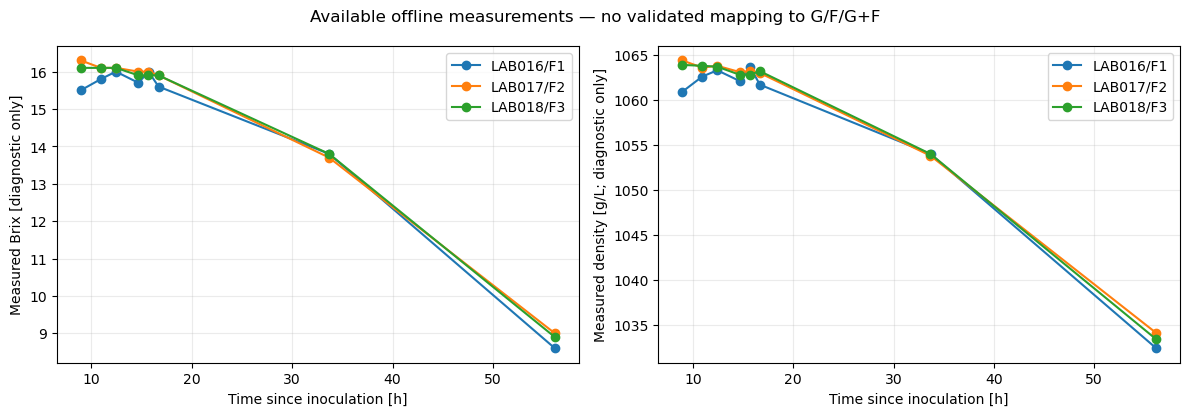

Table 2 — kinetic-state metrics (honest non-estimability report)


,LAB,scenario,observable,n,RMSE,MAE,bias
0,LAB016,A_physical_E0_0,none — no validated core-state observation,0,NaN,NaN,NaN
1,LAB016,B_historical_E0_median,none — no validated core-state observation,0,NaN,NaN,NaN
2,LAB017,A_physical_E0_0,none — no validated core-state observation,0,NaN,NaN,NaN
3,LAB017,B_historical_E0_median,none — no validated core-state observation,0,NaN,NaN,NaN
4,LAB018,A_physical_E0_0,none — no validated core-state observation,0,NaN,NaN,NaN
5,LAB018,B_historical_E0_median,none — no validated core-state observation,0,NaN,NaN,NaN
6,GLOBAL,A_physical_E0_0,none — no validated core-state observation,0,NaN,NaN,NaN
7,GLOBAL,B_historical_E0_median,none — no validated core-state observation,0,NaN,NaN,NaN


In [7]:
offline['timestamp'] = offline.apply(lambda row: combine_date_time(row['Fecha'], row['Hora']), axis=1)
offline['time_h'] = offline.apply(lambda row: (row['timestamp'] - T0_BY_LAB[row['CodigoLab']]).total_seconds() / 3600.0, axis=1)
colors = {'LAB016': 'tab:blue', 'LAB017': 'tab:orange', 'LAB018': 'tab:green'}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
for lab, group in offline.groupby('CodigoLab'):
    axes[0].plot(group['time_h'], group['Brix'], marker='o', color=colors[lab], label=f"{lab}/{LABS[lab]['fermenter']}")
    axes[1].plot(group['time_h'], group['Densidad_g_L'], marker='o', color=colors[lab], label=f"{lab}/{LABS[lab]['fermenter']}")
axes[0].set_ylabel('Measured Brix [diagnostic only]')
axes[1].set_ylabel('Measured density [g/L; diagnostic only]')
for ax in axes:
    ax.set_xlabel('Time since inoculation [h]')
    ax.grid(alpha=0.25)
    ax.legend()
fig.suptitle('Available offline measurements — no validated mapping to G/F/G+F')
fig.tight_layout()
plt.show()

table2 = pd.DataFrame([
    {'LAB': lab, 'scenario': scenario, 'observable': 'none — no validated core-state observation', 'n': 0, 'RMSE': np.nan, 'MAE': np.nan, 'bias': np.nan}
    for lab in [*LABS, 'GLOBAL'] for scenario in SCENARIOS
])
print('Table 2 — kinetic-state metrics (honest non-estimability report)')
display(table2)


## 7. Sensitivity to the initial-ethanol convention

These are two forward predictions with the same frozen parameter vector. Their difference is sensitivity to the historical clock convention, not an E0 fit.


,LAB,variable,max_abs_B_minus_A,end_B_minus_A
0,LAB016,X,0.00000,-0.00000
1,LAB016,G,7.06300,0.76289
2,LAB016,F,7.56688,6.43068
3,LAB016,E,9.70765,5.13794
4,LAB016,Gly,0.47751,-0.05664
5,LAB016,CO2_pred_g_L_h,0.16312,0.05834
6,LAB017,X,0.00001,0.00000
7,LAB017,G,7.07251,0.77177
8,LAB017,F,7.58592,6.45661
9,LAB017,E,9.70765,5.11803


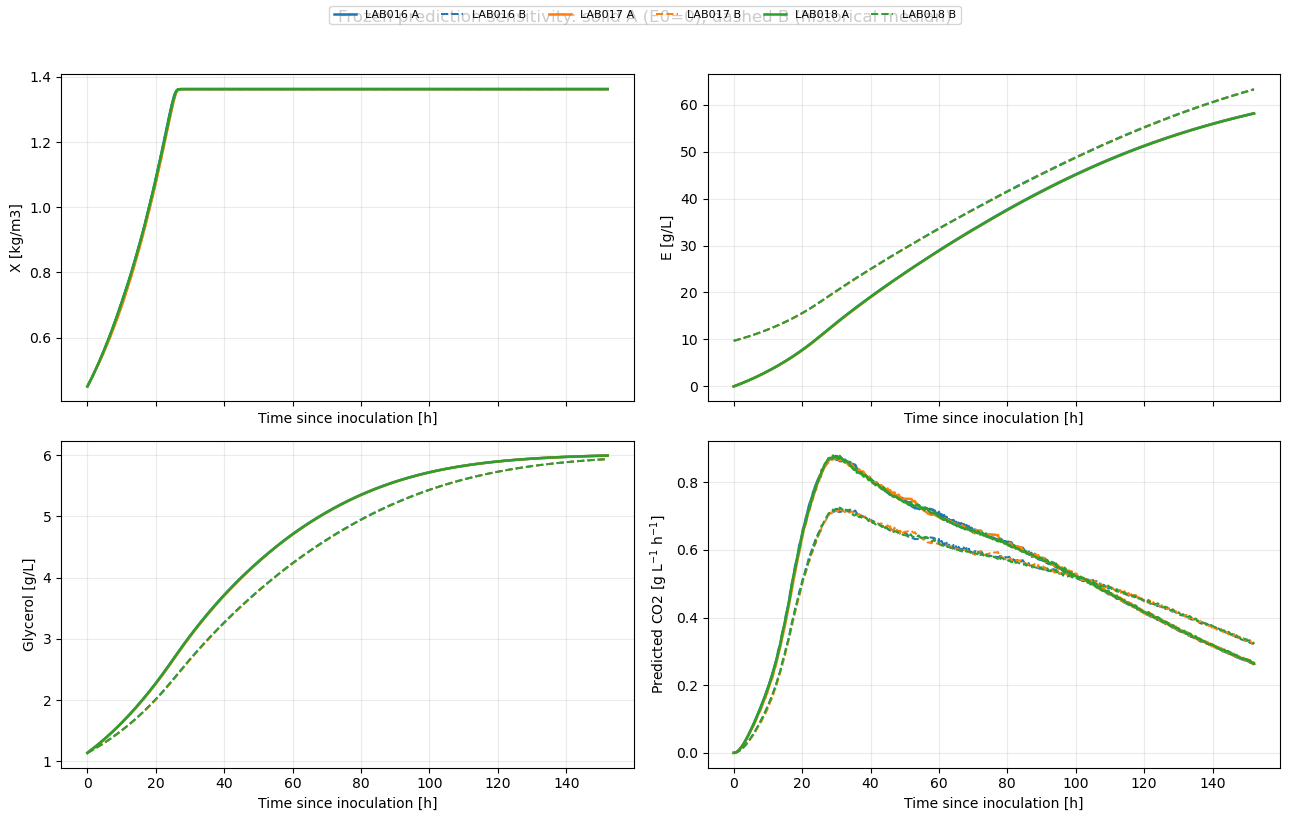

In [8]:
sensitivity_rows = []
for lab in LABS:
    a = predictions[('A_physical_E0_0', lab)]
    b = predictions[('B_historical_E0_median', lab)]
    for variable in ('X', 'G', 'F', 'E', 'Gly', 'CO2_pred_g_L_h'):
        sensitivity_rows.append({'LAB': lab, 'variable': variable, 'max_abs_B_minus_A': float(np.max(np.abs(b[variable] - a[variable]))), 'end_B_minus_A': float(b[variable].iloc[-1] - a[variable].iloc[-1])})
e0_sensitivity = pd.DataFrame(sensitivity_rows)
display(e0_sensitivity.round(5))

plot_variables = [('X', 'X [kg/m3]'), ('E', 'E [g/L]'), ('Gly', 'Glycerol [g/L]'), ('CO2_pred_g_L_h', 'Predicted CO2 [g L$^{-1}$ h$^{-1}$]')]
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, (variable, ylabel) in zip(axes.flat, plot_variables):
    for lab in LABS:
        a = predictions[('A_physical_E0_0', lab)]
        b = predictions[('B_historical_E0_median', lab)]
        ax.plot(a['time_h'], a[variable], color=colors[lab], lw=1.8, label=f'{lab} A')
        ax.plot(b['time_h'], b[variable], color=colors[lab], lw=1.4, ls='--', label=f'{lab} B')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.set_xlabel('Time since inoculation [h]')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=6, fontsize=8)
fig.suptitle('Frozen prediction sensitivity: solid A (E0=0), dashed B (historical median)', y=1.02)
fig.tight_layout()
plt.show()


## 8. CO2 holdout metrics

`CO2_FILT_*` remains untouched in SCCM. In memory it is converted with the official LAB logger convention used by the prior audit: molar volume 24.16 L/mol, CO2 molar mass 44.0095 g/mol, 2.0 L working volume and 0.74 correction factor. No baseline offset or gain is estimated. Metrics use only `time_h >= 0` and unmasked samples. AUC uses adjacent valid sample pairs only, rejects the logger gap, and never bridges artifact windows.

Two domains are reported: `pre_nutrition_clean` (primary causal holdout, ending immediately before the first possible late nutrition) and `full_record_context` (descriptive only after that point because the unknown addition is omitted).


In [9]:
STANDARD_MOLAR_VOLUME_L_PER_MOL = 24.16
CO2_MOLAR_MASS_G_PER_MOL = 44.0095
REACTOR_WORKING_VOLUME_L = 2.0
CO2_FLOW_CORRECTION_FACTOR = 0.74
CO2_G_L_H_PER_SCCM = CO2_MOLAR_MASS_G_PER_MOL * 60.0 * CO2_FLOW_CORRECTION_FACTOR / (1000.0 * STANDARD_MOLAR_VOLUME_L_PER_MOL * REACTOR_WORKING_VOLUME_L)
print(f'Official conversion: 1 SCCM = {CO2_G_L_H_PER_SCCM:.8f} g L^-1 h^-1')
for lab in LABS:
    signals[lab]['co2_filt']['CO2_obs_g_L_h'] = signals[lab]['co2_filt']['flow_filt_sccm'] * CO2_G_L_H_PER_SCCM

def metrics_on_domain(lab, scenario, domain_name, candidate):
    co2 = signals[lab]['co2_filt']
    candidate = np.asarray(candidate, dtype=bool)
    valid = candidate & co2['co2_valid_for_fitting'].to_numpy(dtype=bool) & np.isfinite(co2['CO2_obs_g_L_h'].to_numpy(dtype=float))
    time_h = co2['time_h'].to_numpy(dtype=float)
    observed_all = co2['CO2_obs_g_L_h'].to_numpy(dtype=float)
    prediction = predictions[(scenario, lab)]
    predicted_all = np.interp(time_h, prediction['time_h'], prediction['CO2_pred_g_L_h'])
    observed, predicted, times = observed_all[valid], predicted_all[valid], time_h[valid]
    error = predicted - observed
    denominator = float(np.sum((observed - observed.mean()) ** 2))
    r2 = 1.0 - float(np.sum(error ** 2)) / denominator if denominator > 0 else np.nan
    dt = np.diff(time_h)
    median_dt = float(np.median(dt[dt > 0]))
    pair_ok = valid[:-1] & valid[1:] & (dt > 0) & (dt <= 1.5 * median_dt)
    auc_obs = float(np.sum(0.5 * (observed_all[:-1] + observed_all[1:]) * dt * pair_ok))
    auc_pred = float(np.sum(0.5 * (predicted_all[:-1] + predicted_all[1:]) * dt * pair_ok))
    return {
        'LAB': lab, 'scenario': scenario, 'domain': domain_name, 'n_valid_CO2': int(valid.sum()),
        'excluded_pct': 100.0 * int((candidate & ~co2['co2_valid_for_fitting'].to_numpy(dtype=bool)).sum()) / max(int(candidate.sum()), 1),
        'RMSE': float(np.sqrt(np.mean(error ** 2))), 'MAE': float(np.mean(np.abs(error))), 'bias': float(np.mean(error)), 'R2': r2,
        'peak_obs': float(observed.max()), 'peak_pred': float(predicted.max()),
        'tpeak_obs': float(times[np.argmax(observed)]), 'tpeak_pred': float(times[np.argmax(predicted)]),
        'AUC_obs': auc_obs, 'AUC_pred': auc_pred,
    }

metric_rows = []
for lab in LABS:
    co2 = signals[lab]['co2_filt']
    post_inoculation = co2['time_h'].ge(0).to_numpy()
    clean = (co2['time_h'].ge(0) & co2['time_h'].lt(FIRST_POSSIBLE_NUTRITION_H[lab])).to_numpy()
    for scenario in SCENARIOS:
        metric_rows.append(metrics_on_domain(lab, scenario, 'pre_nutrition_clean', clean))
        metric_rows.append(metrics_on_domain(lab, scenario, 'full_record_context', post_inoculation))
co2_metrics = pd.DataFrame(metric_rows)
print('Table 3 — CO2 holdout (bias = predicted - observed; AUCs use identical non-bridged support)')
display(co2_metrics.round(5))


Official conversion: 1 SCCM = 0.04043919 g L^-1 h^-1
Table 3 — CO2 holdout (bias = predicted - observed; AUCs use identical non-bridged support)


,LAB,scenario,domain,n_valid_CO2,excluded_pct,RMSE,MAE,bias,R2,peak_obs,peak_pred,tpeak_obs,tpeak_pred,AUC_obs,AUC_pred
0,LAB016,A_physical_E0_0,pre_nutrition_clean,18162,5.94511,0.37585,0.27701,0.27592,-0.48876,0.79181,0.87750,47.15278,29.74972,17.22309,31.00863
1,LAB016,A_physical_E0_0,full_record_context,43723,3.70656,0.28841,0.22407,0.22361,-0.27379,0.79181,0.87750,47.15278,29.74972,43.52651,74.18828
2,LAB016,B_historical_E0_median,pre_nutrition_clean,18162,5.94511,0.28304,0.20421,0.16967,0.15574,0.79181,0.72176,47.15278,30.24917,17.22309,25.70727
3,LAB016,B_historical_E0_median,full_record_context,43723,3.70656,0.25014,0.19915,0.17783,0.04180,0.79181,0.72176,47.15278,30.24917,43.52651,68.92781
4,LAB017,A_physical_E0_0,pre_nutrition_clean,18782,2.72930,0.31229,0.22101,0.21727,0.09505,0.81422,0.87334,40.98417,29.50000,19.85932,31.18540
5,LAB017,A_physical_E0_0,full_record_context,44250,2.54377,0.26910,0.21259,0.18270,0.24577,0.87610,0.87334,62.64611,29.50000,48.15357,74.24815
6,LAB017,B_historical_E0_median,pre_nutrition_clean,18782,2.72930,0.23178,0.17327,0.11340,0.50149,0.81422,0.71955,40.98417,30.75028,19.85932,25.82417
7,LAB017,B_historical_E0_median,full_record_context,44250,2.54377,0.25146,0.21094,0.13694,0.34142,0.87610,0.71955,62.64611,30.75028,48.15357,68.91866
8,LAB018,A_physical_E0_0,pre_nutrition_clean,18782,2.72930,0.32621,0.23480,0.23196,-0.03401,0.79757,0.87861,40.77889,29.00139,19.13913,31.27569
9,LAB018,A_physical_E0_0,full_record_context,44342,2.34115,0.27332,0.21585,0.21120,0.03192,0.79757,0.87861,40.77889,29.00139,44.40365,74.43953


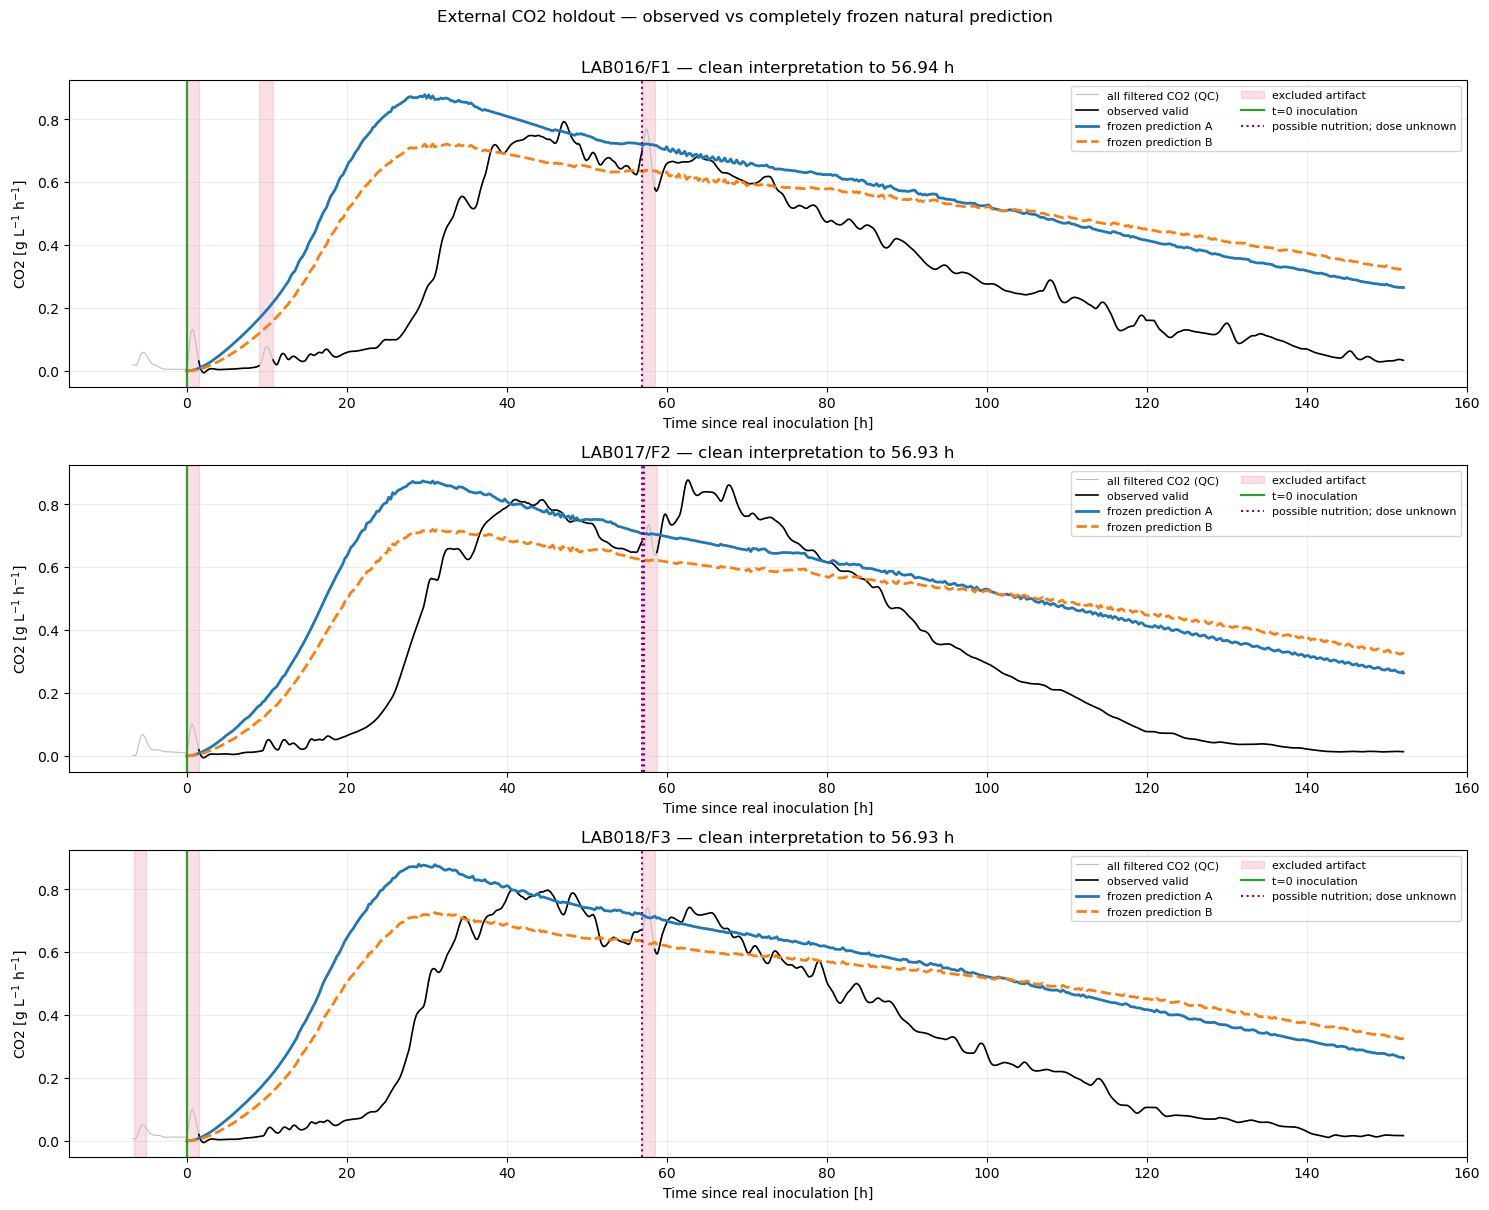

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=False, sharey=True)
for ax, lab in zip(axes, LABS):
    co2 = signals[lab]['co2_filt']
    y = co2['CO2_obs_g_L_h']
    valid = co2['co2_valid_for_fitting'] & co2['time_h'].ge(0)
    ax.plot(co2['time_h'], y, color='0.75', lw=0.8, label='all filtered CO2 (QC)')
    ax.plot(co2['time_h'], y.where(valid), color='black', lw=1.2, label='observed valid')
    for scenario, style in [('A_physical_E0_0', '-'), ('B_historical_E0_median', '--')]:
        pred = predictions[(scenario, lab)]
        ax.plot(pred['time_h'], pred['CO2_pred_g_L_h'], ls=style, lw=2.0, label=f'frozen prediction {scenario[0]}')
    for number, (start, end) in enumerate(EXCLUSION_WINDOWS[lab]):
        ax.axvspan((start - T0_BY_LAB[lab]).total_seconds() / 3600.0, (end - T0_BY_LAB[lab]).total_seconds() / 3600.0, color='crimson', alpha=0.13, label='excluded artifact' if number == 0 else None)
    ax.axvline(0, color='tab:green', lw=1.6, label='t=0 inoculation')
    late_events = pulse_table[pulse_table['LAB'].eq(lab) & pulse_table['classification'].str.startswith('possible later nutrition')]
    for number, event in enumerate(late_events.itertuples()):
        ax.axvline(event.pulse_start_h, color='purple', ls=':', lw=1.5, label='possible nutrition; dose unknown' if number == 0 else None)
    ax.set_title(f"{lab}/{LABS[lab]['fermenter']} — clean interpretation to {FIRST_POSSIBLE_NUTRITION_H[lab]:.2f} h")
    ax.set_ylabel('CO2 [g L$^{-1}$ h$^{-1}$]')
    ax.set_xlabel('Time since real inoculation [h]')
    ax.grid(alpha=0.22)
    ax.legend(loc='upper right', fontsize=8, ncol=2)
fig.suptitle('External CO2 holdout — observed vs completely frozen natural prediction', y=1.005)
fig.tight_layout()
plt.show()


## LAB016–LAB018 external holdout


In [11]:
primary = co2_metrics[co2_metrics['domain'].eq('pre_nutrition_clean')].copy()
primary['relative_RMSE_to_peak'] = primary['RMSE'] / primary['peak_obs']
scenario_a = primary[primary['scenario'].eq('A_physical_E0_0')].copy()
best_lab = scenario_a.loc[scenario_a['RMSE'].idxmin(), 'LAB']
worst_lab = scenario_a.loc[scenario_a['RMSE'].idxmax(), 'LAB']
median_r2 = float(scenario_a['R2'].median())
median_relative_rmse = float(scenario_a['relative_RMSE_to_peak'].median())
co2_reasonable = median_r2 >= 0.5 and median_relative_rmse <= 0.25
bias_signs = np.sign(scenario_a['bias'].to_numpy())
shared_bias = 'positive (systematic overprediction)' if np.all(bias_signs > 0) else ('negative (systematic underprediction)' if np.all(bias_signs < 0) else 'not shared in sign across F1/F2/F3')
max_co2_e0_change = float(e0_sensitivity.loc[e0_sensitivity['variable'].eq('CO2_pred_g_L_h'), 'max_abs_B_minus_A'].max())
relative_co2_e0_change = max_co2_e0_change / float(scenario_a['peak_obs'].median())
clean_text = ', '.join(f'{lab}: {FIRST_POSSIBLE_NUTRITION_H[lab]:.2f} h' for lab in LABS)
verdict = 'sí, según los criterios descriptivos predeclarados' if co2_reasonable else 'no de manera razonable para la salida CO2 con este protocolo congelado'
display(Markdown(f'''
1. **¿Generaliza razonablemente?** Para el modelo cinético upstream no puede emitirse un veredicto porque no hay estados medidos con correspondencia válida (`n=0`). Para la cadena completa observada vía CO2, **{verdict}**: en el escenario físico, la mediana pre-nutrición de R² es {median_r2:.3f} y la mediana de RMSE/peak observado es {median_relative_rmse:.1%}.
2. **¿Qué variables predice mejor?** No existe un conjunto de variables core evaluables que permita ordenarlas. Entre los únicos outputs evaluables (CO2 por reactor), {best_lab} tiene el menor RMSE absoluto pre-nutrición.
3. **¿Qué variables predice peor?** La única variable contrastable es CO2; {worst_lab} presenta el mayor RMSE pre-nutrición. Brix y densidad no se convierten artificialmente en azúcar.
4. **¿Hay sesgo compartido?** El signo del bias `predicho − observado` es **{shared_bias}**. La tabla conserva magnitud y signo por reactor.
5. **Efecto de E0.** Cambiar de 0 a la mediana histórica ({E0_HISTORICAL_MEDIAN:.6f} g/L) altera el CO2 predicho como máximo {max_co2_e0_change:.5f} g L⁻¹ h⁻¹ ({relative_co2_e0_change:.1%} del peak observado mediano). La tabla de sensibilidad muestra además el efecto sobre X, E y Gly; no se optimizó E0.
6. **¿Upstream, capa CO2 o ambas?** El error end-to-end es identificable, pero su reparto **no**: faltan mediciones core y falta el ancla química que la capa CO2 usa para activar la fermentación. El fallback de activación de ancho cero fue conservado. Por tanto, cinética upstream y capa CO2 siguen siendo explicaciones plausibles; no es válido atribuir el residuo sólo a una.
7. **Nutriciones posteriores.** Las señales tardías tienen timestamp, pero no dosis/composición. Introducir un salto de N inventado confundiría validación con ajuste; por eso no se modelan y el tramo posterior es sólo contexto.
8. **Ventana limpia.** Antes del primer pulso tardío potencialmente nutritivo: {clean_text}. Dentro de ella también se excluyen `time_h < 0` y las ventanas instrumentales de 90 min.
9. **¿Justifica recalibrar luego con LAB013–LAB018?** El desajuste de CO2 puede motivar una auditoría y un diseño de recalibración posterior, pero este holdout por sí solo no justifica absorber LAB016–LAB018 en el fit: primero se necesitan estados químicos/biomasa, dosis de nutrición y un ancla de activación verificable. LAB013–LAB015 debe evaluarse por su propia cobertura. **No se recalibra aquí.**

**Limitación adicional de escala:** la señal LAB016–LAB018 usa la conversión oficial del logger (24.16 L/mol y factor 0.74), mientras que el loader del artefacto CO2 congelado documenta 22.414 L/mol sin ese factor. Se respetaron ambas implementaciones sin renormalizar `matrix_gain`; esta incompatibilidad de convención puede contribuir al sesgo y debe resolverse antes de cualquier futura recalibración.
'''))



1. **¿Generaliza razonablemente?** Para el modelo cinético upstream no puede emitirse un veredicto porque no hay estados medidos con correspondencia válida (`n=0`). Para la cadena completa observada vía CO2, **no de manera razonable para la salida CO2 con este protocolo congelado**: en el escenario físico, la mediana pre-nutrición de R² es -0.034 y la mediana de RMSE/peak observado es 40.9%.
2. **¿Qué variables predice mejor?** No existe un conjunto de variables core evaluables que permita ordenarlas. Entre los únicos outputs evaluables (CO2 por reactor), LAB017 tiene el menor RMSE absoluto pre-nutrición.
3. **¿Qué variables predice peor?** La única variable contrastable es CO2; LAB016 presenta el mayor RMSE pre-nutrición. Brix y densidad no se convierten artificialmente en azúcar.
4. **¿Hay sesgo compartido?** El signo del bias `predicho − observado` es **positive (systematic overprediction)**. La tabla conserva magnitud y signo por reactor.
5. **Efecto de E0.** Cambiar de 0 a la mediana histórica (9.707652 g/L) altera el CO2 predicho como máximo 0.16354 g L⁻¹ h⁻¹ (20.5% del peak observado mediano). La tabla de sensibilidad muestra además el efecto sobre X, E y Gly; no se optimizó E0.
6. **¿Upstream, capa CO2 o ambas?** El error end-to-end es identificable, pero su reparto **no**: faltan mediciones core y falta el ancla química que la capa CO2 usa para activar la fermentación. El fallback de activación de ancho cero fue conservado. Por tanto, cinética upstream y capa CO2 siguen siendo explicaciones plausibles; no es válido atribuir el residuo sólo a una.
7. **Nutriciones posteriores.** Las señales tardías tienen timestamp, pero no dosis/composición. Introducir un salto de N inventado confundiría validación con ajuste; por eso no se modelan y el tramo posterior es sólo contexto.
8. **Ventana limpia.** Antes del primer pulso tardío potencialmente nutritivo: LAB016: 56.94 h, LAB017: 56.93 h, LAB018: 56.93 h. Dentro de ella también se excluyen `time_h < 0` y las ventanas instrumentales de 90 min.
9. **¿Justifica recalibrar luego con LAB013–LAB018?** El desajuste de CO2 puede motivar una auditoría y un diseño de recalibración posterior, pero este holdout por sí solo no justifica absorber LAB016–LAB018 en el fit: primero se necesitan estados químicos/biomasa, dosis de nutrición y un ancla de activación verificable. LAB013–LAB015 debe evaluarse por su propia cobertura. **No se recalibra aquí.**

**Limitación adicional de escala:** la señal LAB016–LAB018 usa la conversión oficial del logger (24.16 L/mol y factor 0.74), mientras que el loader del artefacto CO2 congelado documenta 22.414 L/mol sin ese factor. Se respetaron ambas implementaciones sin renormalizar `matrix_gain`; esta incompatibilidad de convención puede contribuir al sesgo y debe resolverse antes de cualquier futura recalibración.


## 10. Reproducibility and no-fit checks


In [12]:
HASHES_AFTER = {str(path.relative_to(ROOT)): sha256(path) for path in protected_paths}
assert HASHES_AFTER == HASHES_BEFORE
assert sha256(THETA_PATH) == HASHES_BEFORE[str(THETA_PATH.relative_to(ROOT))]
assert sha256(CO2_PARAMETER_PATH) == HASHES_BEFORE[str(CO2_PARAMETER_PATH.relative_to(ROOT))]
assert all(batch.pulses['N'] == tuple() for batches in scenario_batches.values() for batch in batches.values())
assert SCENARIOS['A_physical_E0_0']['E0'] == 0.0
assert np.isclose(SCENARIOS['B_historical_E0_median']['E0'], historical_e0_values.median())
print('VALIDATION PASSED')
print('- protected theta/CO2/data SHA256 hashes unchanged')
print('- frozen core simulations:', len(predictions))
print('- optimizer/fitting calls executed: 0')
print('- parameters/gains/offsets estimated here: 0')
print('- invented N additions: 0')
print('- artifact recovery reproduced:', COMMON_RECOVERY_MIN, 'min')
print('- kinetic state observations eligible for metrics: 0')
print('- CO2 metric rows:', len(co2_metrics))


VALIDATION PASSED
- protected theta/CO2/data SHA256 hashes unchanged
- frozen core simulations: 6
- optimizer/fitting calls executed: 0
- parameters/gains/offsets estimated here: 0
- invented N additions: 0
- artifact recovery reproduced: 90 min
- kinetic state observations eligible for metrics: 0
- CO2 metric rows: 12


## 11. DIAGNÓSTICO adicional de onset/lag — NO es holdout externo

Esta sección se añade **después** del baseline estricto, que permanece intacto arriba. No recalibra, no llama optimizadores y no modifica theta, la capa de CO2, matrix_gain, condiciones del baseline ni datos. La predicción primaria sigue siendo el escenario físico congelado A (E0 = 0).

El único escenario nuevo es **“diagnostic onset-aligned prediction — NOT external holdout”**. Usa el CO2 observado para medir el onset y por ello no constituye validación externa. La máscara event-aware ya auditada se reutiliza sin cambios: t = 0 continúa siendo el fin del pulso de inoculación y la recuperación causal de 90 min queda excluida.


In [13]:
DIAGNOSTIC_LABEL = 'diagnostic onset-aligned prediction — NOT external holdout'
DIAGNOSTIC_SCENARIO = 'A_physical_E0_0'
ONSET_CONSECUTIVE_POINTS = 3

def diagnostic_hourly_profile(lab):
    """Historical 1 h observation support, after the existing event-aware mask."""
    co2 = signals[lab]['co2_filt']
    valid = (
        co2['time_h'].ge(0)
        & co2['time_h'].lt(FIRST_POSSIBLE_NUTRITION_H[lab])
        & co2['co2_valid_for_fitting']
        & np.isfinite(co2['CO2_obs_g_L_h'])
    )
    profile = co2.loc[valid, ['time_h', 'CO2_obs_g_L_h']].copy()
    profile['bin_h'] = np.round(profile['time_h'] / co2_cross.OBSERVATION_BIN_H) * co2_cross.OBSERVATION_BIN_H
    profile = (
        profile.groupby('bin_h', as_index=False)
        .agg(t_h=('time_h', 'median'), co2_rate_g_l_h=('CO2_obs_g_L_h', 'median'))
        .sort_values('t_h')
    )
    profile['detection_limit_g_l_h'] = co2_cross.CO2_DETECTION_LIMIT_G_L_H
    prediction = predictions[(DIAGNOSTIC_SCENARIO, lab)]
    profile['prediction_g_l_h'] = np.interp(profile['t_h'], prediction['time_h'], prediction['CO2_pred_g_L_h'])
    return profile

onset_profiles = {}
onset_rows = []
for lab in LABS:
    profile = diagnostic_hourly_profile(lab)
    threshold = co2_cross._onset_threshold(profile)
    onset_obs = co2_cross._sustained_onset_h(
        profile['t_h'].to_numpy(), profile['co2_rate_g_l_h'].to_numpy(),
        threshold, consecutive=ONSET_CONSECUTIVE_POINTS,
    )
    onset_pred = co2_cross._sustained_onset_h(
        profile['t_h'].to_numpy(), profile['prediction_g_l_h'].to_numpy(),
        threshold, consecutive=ONSET_CONSECUTIVE_POINTS,
    )
    delta = onset_obs - onset_pred
    assert np.isfinite([threshold, onset_obs, onset_pred, delta]).all()
    onset_profiles[lab] = profile
    onset_rows.append({
        'LAB': lab, 'onset_obs_h': onset_obs, 'threshold_g_L_h': threshold,
        'onset_pred_h': onset_pred, 'delta_onset_h_obs_minus_pred': delta,
        'comment': 'inoculation transient excluded by audited event-aware mask',
    })

onset_table = pd.DataFrame(onset_rows)
print('Observed threshold = max(LOD, baseline + 0.10*(peak-baseline)); 3 consecutive hourly points.')
print('The same observed threshold is applied to the frozen prediction for a comparable delta.')
display(onset_table.round(4))


Observed threshold = max(LOD, baseline + 0.10*(peak-baseline)); 3 consecutive hourly points.
The same observed threshold is applied to the frozen prediction for a comparable delta.


,LAB,onset_obs_h,threshold_g_L_h,onset_pred_h,delta_onset_h_obs_minus_pred,comment
0,LAB016,24.2491,0.0839,5.7239,18.5251,inoculation transient excluded by audited event-aware mask
1,LAB017,22.2981,0.0896,6.1939,16.1042,inoculation transient excluded by audited event-aware mask
2,LAB018,22.6475,0.0863,5.8699,16.7775,inoculation transient excluded by audited event-aware mask


### 11.1 Time-shift only and like-for-like metrics

For each reactor, the diagnostic curve is exactly
\(q_{\mathrm{shift}}(t)=q_{\mathrm{pred}}(t-\Delta t_{\mathrm{onset}})\),
with \(\Delta t_{\mathrm{onset}}=t_{\mathrm{obs}}-t_{\mathrm{pred}}\). Values before the translated model origin are zero. There is no amplitude scaling, curve deformation or optimized shift. Original and shifted metrics use the identical valid pre-nutrition mask and the same no-gap AUC support.


In [14]:
def shifted_prediction_at(times_h, prediction, delta_h):
    """Pure translation only; no scale, gain, offset, warp or fitted quantity."""
    return np.interp(
        np.asarray(times_h, dtype=float) - float(delta_h),
        prediction['time_h'].to_numpy(dtype=float),
        prediction['CO2_pred_g_L_h'].to_numpy(dtype=float),
        left=0.0, right=float(prediction['CO2_pred_g_L_h'].iloc[-1]),
    )

def diagnostic_metrics(lab, predicted_all):
    co2 = signals[lab]['co2_filt']
    times_all = co2['time_h'].to_numpy(dtype=float)
    observed_all = co2['CO2_obs_g_L_h'].to_numpy(dtype=float)
    candidate = (co2['time_h'].ge(0) & co2['time_h'].lt(FIRST_POSSIBLE_NUTRITION_H[lab])).to_numpy(dtype=bool)
    valid = candidate & co2['co2_valid_for_fitting'].to_numpy(dtype=bool) & np.isfinite(observed_all) & np.isfinite(predicted_all)
    times, observed = times_all[valid], observed_all[valid]
    predicted = np.asarray(predicted_all, dtype=float)[valid]
    error = predicted - observed
    denominator = float(np.sum((observed - observed.mean()) ** 2))
    r2 = 1.0 - float(np.sum(error ** 2)) / denominator if denominator > 0 else np.nan
    dt = np.diff(times_all)
    median_dt = float(np.median(dt[dt > 0]))
    pair_ok = valid[:-1] & valid[1:] & (dt > 0) & (dt <= 1.5 * median_dt)
    auc_obs = float(np.sum(0.5 * (observed_all[:-1] + observed_all[1:]) * dt * pair_ok))
    predicted_all = np.asarray(predicted_all, dtype=float)
    auc_pred = float(np.sum(0.5 * (predicted_all[:-1] + predicted_all[1:]) * dt * pair_ok))
    tpeak_obs, tpeak_pred = float(times[np.argmax(observed)]), float(times[np.argmax(predicted)])
    return {
        'n': int(valid.sum()), 'RMSE': float(np.sqrt(np.mean(error ** 2))),
        'bias': float(np.mean(error)), 'R2': r2,
        'peak_obs': float(observed.max()), 'peak_pred': float(predicted.max()),
        'tpeak_obs_h': tpeak_obs, 'tpeak_pred_h': tpeak_pred,
        'peak_time_error_h': tpeak_pred - tpeak_obs,
        'peak_time_abs_error_h': abs(tpeak_pred - tpeak_obs),
        'AUC_obs': auc_obs, 'AUC_pred': auc_pred,
    }

diagnostic_metric_rows = []
shifted_at_observation_times = {}
for row in onset_table.itertuples(index=False):
    lab = row.LAB
    co2 = signals[lab]['co2_filt']
    prediction = predictions[(DIAGNOSTIC_SCENARIO, lab)]
    original_all = np.interp(co2['time_h'], prediction['time_h'], prediction['CO2_pred_g_L_h'])
    shifted_all = shifted_prediction_at(co2['time_h'], prediction, row.delta_onset_h_obs_minus_pred)
    shifted_at_observation_times[lab] = shifted_all
    for curve, values in [
        ('original frozen', diagnostic_metrics(lab, original_all)),
        (DIAGNOSTIC_LABEL, diagnostic_metrics(lab, shifted_all)),
    ]:
        diagnostic_metric_rows.append({
            'LAB': lab, 'curve': curve,
            'delta_onset_h': 0.0 if curve == 'original frozen' else row.delta_onset_h_obs_minus_pred,
            **values,
        })
diagnostic_metrics_table = pd.DataFrame(diagnostic_metric_rows)

baseline_a = co2_metrics[
    co2_metrics['scenario'].eq(DIAGNOSTIC_SCENARIO)
    & co2_metrics['domain'].eq('pre_nutrition_clean')
].set_index('LAB')
for lab in LABS:
    original = diagnostic_metrics_table[
        diagnostic_metrics_table['LAB'].eq(lab)
        & diagnostic_metrics_table['curve'].eq('original frozen')
    ].iloc[0]
    for diagnostic_name, baseline_name in [
        ('RMSE', 'RMSE'), ('bias', 'bias'), ('R2', 'R2'),
        ('peak_obs', 'peak_obs'), ('peak_pred', 'peak_pred'),
        ('tpeak_obs_h', 'tpeak_obs'), ('tpeak_pred_h', 'tpeak_pred'),
        ('AUC_obs', 'AUC_obs'), ('AUC_pred', 'AUC_pred'),
    ]:
        assert np.isclose(original[diagnostic_name], baseline_a.loc[lab, baseline_name])

comparison_rows = []
for lab in LABS:
    original = diagnostic_metrics_table.query("LAB == @lab and curve == 'original frozen'").iloc[0]
    shifted = diagnostic_metrics_table.query("LAB == @lab and curve == @DIAGNOSTIC_LABEL").iloc[0]
    comparison_rows.append({
        'LAB': lab, 'RMSE original': original['RMSE'], 'RMSE shifted': shifted['RMSE'],
        'RMSE improvement %': 100.0 * (1.0 - shifted['RMSE'] / original['RMSE']),
        'bias original': original['bias'], 'bias shifted': shifted['bias'],
        'R2 original': original['R2'], 'R2 shifted': shifted['R2'],
        'peak obs': original['peak_obs'], 'peak pred original': original['peak_pred'],
        'peak pred shifted': shifted['peak_pred'],
        'peak-time error original h': original['peak_time_error_h'],
        'peak-time error shifted h': shifted['peak_time_error_h'],
        'AUC obs': original['AUC_obs'], 'AUC original': original['AUC_pred'],
        'AUC shifted': shifted['AUC_pred'],
    })
comparison_table = pd.DataFrame(comparison_rows)
display(comparison_table.round(4))


,LAB,RMSE original,RMSE shifted,RMSE improvement %,bias original,bias shifted,R2 original,R2 shifted,peak obs,peak pred original,peak pred shifted,peak-time error original h,peak-time error shifted h,AUC obs,AUC original,AUC shifted
0,LAB016,0.3759,0.0892,76.2677,0.2759,0.0241,-0.4888,0.9162,0.7918,0.8775,0.8775,-17.4031,1.1214,17.2231,31.0086,18.6292
1,LAB017,0.3123,0.0883,71.7145,0.2173,-0.0006,0.0950,0.9276,0.8142,0.8733,0.8733,-11.4842,4.6197,19.8593,31.1854,20.0055
2,LAB018,0.3262,0.0953,70.7921,0.2320,0.0060,-0.0340,0.9118,0.7976,0.8786,0.8786,-11.7775,4.9975,19.1391,31.2757,19.6959


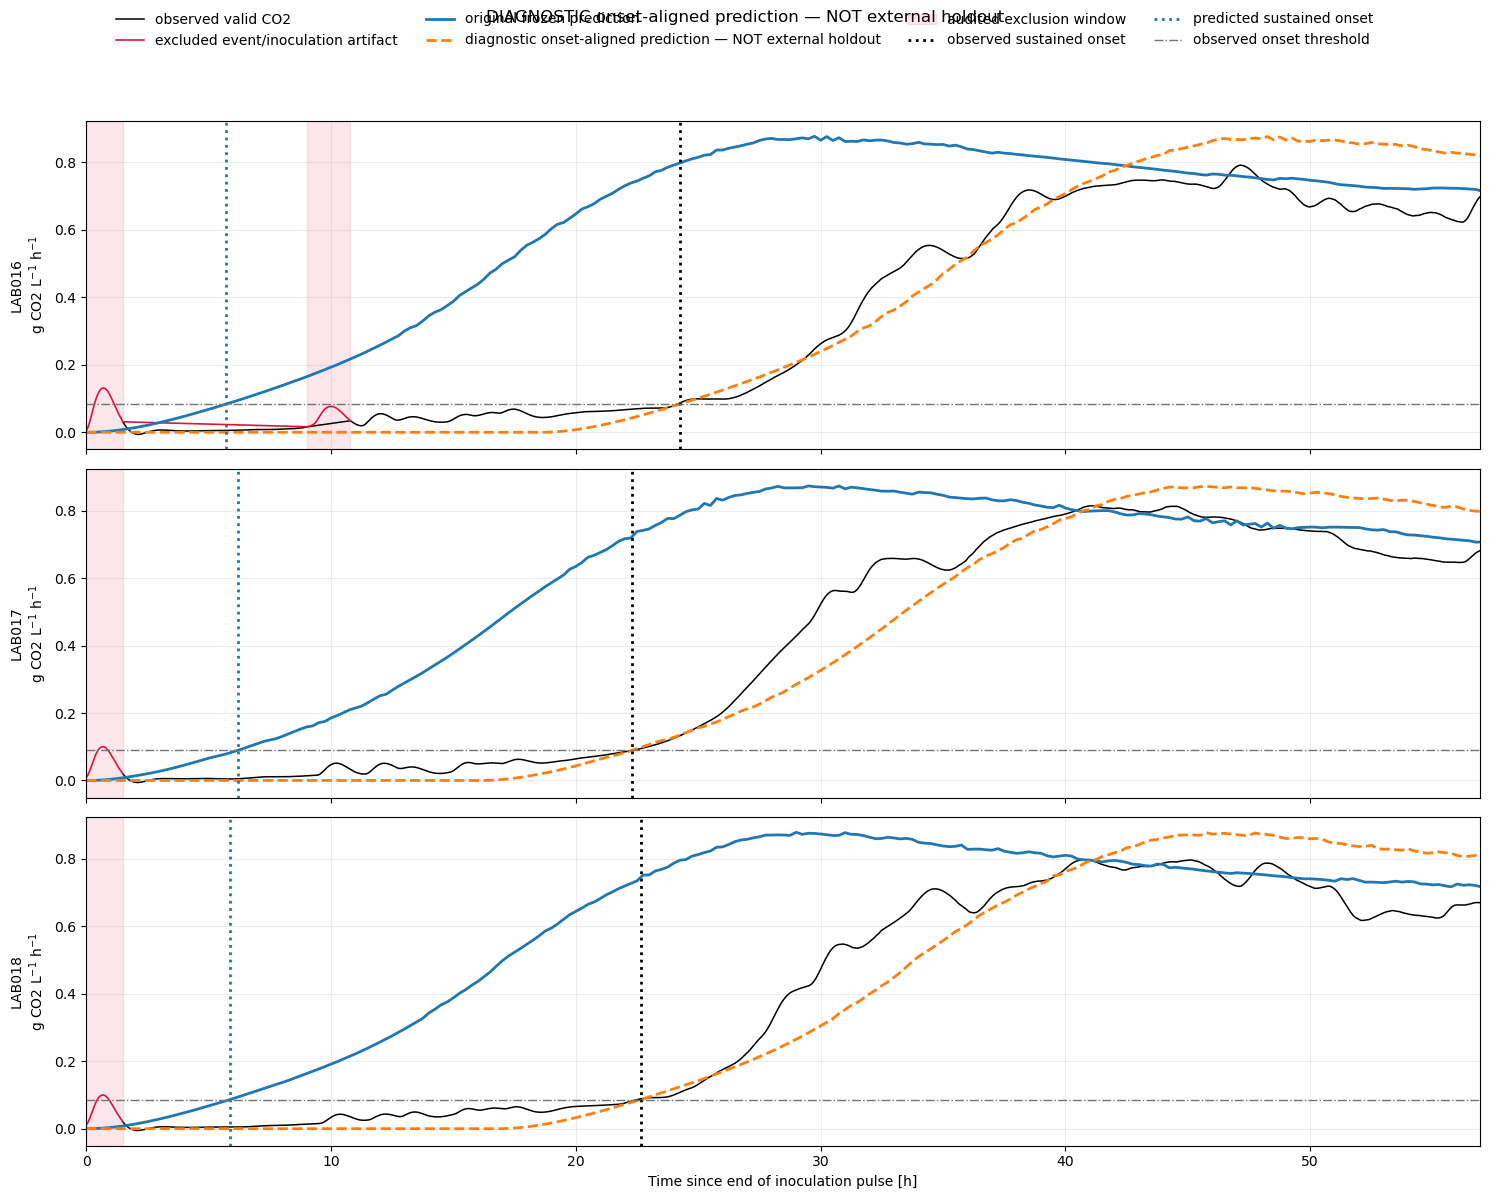

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True, sharey=True)
for ax, onset in zip(axes, onset_table.itertuples(index=False)):
    lab = onset.LAB
    co2 = signals[lab]['co2_filt']
    prediction = predictions[(DIAGNOSTIC_SCENARIO, lab)]
    pre = co2['time_h'].ge(0) & co2['time_h'].lt(FIRST_POSSIBLE_NUTRITION_H[lab])
    valid, excluded = pre & co2['co2_valid_for_fitting'], pre & ~co2['co2_valid_for_fitting']
    ax.plot(co2.loc[valid, 'time_h'], co2.loc[valid, 'CO2_obs_g_L_h'], color='black', lw=1.1, label='observed valid CO2')
    ax.plot(co2.loc[excluded, 'time_h'], co2.loc[excluded, 'CO2_obs_g_L_h'], color='crimson', lw=1.2, label='excluded event/inoculation artifact')
    ax.plot(prediction['time_h'], prediction['CO2_pred_g_L_h'], color='tab:blue', lw=2.0, label='original frozen prediction')
    shifted_grid = shifted_prediction_at(prediction['time_h'], prediction, onset.delta_onset_h_obs_minus_pred)
    ax.plot(prediction['time_h'], shifted_grid, color='tab:orange', lw=2.0, ls='--', label=DIAGNOSTIC_LABEL)
    for number, (start, end) in enumerate(EXCLUSION_WINDOWS[lab]):
        start_h = (start - T0_BY_LAB[lab]).total_seconds() / 3600.0
        end_h = (end - T0_BY_LAB[lab]).total_seconds() / 3600.0
        if end_h >= 0 and start_h < FIRST_POSSIBLE_NUTRITION_H[lab]:
            ax.axvspan(max(0.0, start_h), min(FIRST_POSSIBLE_NUTRITION_H[lab], end_h), color='crimson', alpha=0.10, label='audited exclusion window' if number == 0 else None)
    ax.axvline(onset.onset_obs_h, color='black', ls=':', lw=2.0, label='observed sustained onset')
    ax.axvline(onset.onset_pred_h, color='tab:blue', ls=':', lw=2.0, label='predicted sustained onset')
    ax.axhline(onset.threshold_g_L_h, color='0.45', ls='-.', lw=1.0, label='observed onset threshold')
    ax.set_xlim(0, FIRST_POSSIBLE_NUTRITION_H[lab])
    ax.set_ylabel(f'{lab}\ng CO2 L$^{{-1}}$ h$^{{-1}}$')
    ax.grid(alpha=0.23)
axes[-1].set_xlabel('Time since end of inoculation pulse [h]')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False)
fig.suptitle('DIAGNOSTIC onset-aligned prediction — NOT external holdout', y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()


### 11.2 LAB013–LAB015 chemical activity brackets (diagnostic only)

The brackets below are calculated independently with the existing _chemical_activity_bracket() implementation and the correct experimental clock (t0 = numbered reactor sample 1). Only actual paired glucose and fructose assays are supplied. Ethanol is absent and remains NaN; it is neither invented nor inferred. These brackets are not transferred to LAB016–LAB018, whose temperature regime differs.


In [16]:
CHEM_DIR = FM / 'data' / 'mem2026' / 'LAB013-015'
CHEM_SOURCE = CHEM_DIR / 'LAB013-LAB015-offline-combined.csv'
CHEM_SCHEDULE_SOURCE = CHEM_DIR / 'LAB013-LAB015-offline-measurements.csv'
DIAGNOSTIC_REPORT_PATHS = sorted(
    path for path in (FM / 'data' / 'mem2026').glob('LAB*/LAB*_OCULYZE/report.csv')
    if path.parent.name.replace('_OCULYZE', '') in tuple(f'LAB{i:03d}' for i in range(13, 19))
)
DIAGNOSTIC_INPUT_PATHS = [
    CHEM_SOURCE, CHEM_SCHEDULE_SOURCE, CHEM_DIR / 'Y15_LAB013-015.csv',
    DATA_DIR / 'LAB016-018-offline-measurements.csv',
    *(CHEM_DIR / f'Temp_{fermenter}_LAB{number:03d}.csv'
      for fermenter, number in zip(('F1', 'F2', 'F3'), (13, 14, 15))),
    *DIAGNOSTIC_REPORT_PATHS,
]
DIAGNOSTIC_HASHES_BEFORE = {str(path.relative_to(ROOT)): sha256(path) for path in DIAGNOSTIC_INPUT_PATHS}
chem_source = pd.read_csv(CHEM_SOURCE)
chem_schedule = pd.read_csv(CHEM_SCHEDULE_SOURCE)
chem_schedule['sample_datetime'] = pd.to_datetime(
    chem_schedule['fecha_muestreo'].astype(str) + ' ' + chem_schedule['hora_muestreo'].astype(str), errors='raise',
)
chem_t0 = chem_schedule[chem_schedule['sample_id'].str.endswith('-1')].set_index('lab_id')['sample_datetime'].to_dict()
chem_source['sample_datetime'] = pd.to_datetime(
    chem_source['fecha_muestreo'].astype(str) + ' ' + chem_source['hora_muestreo'].astype(str), errors='raise',
)
chem_source['time_h_diag'] = [
    (stamp - chem_t0[lab]).total_seconds() / 3600.0
    for lab, stamp in zip(chem_source['lab_id'], chem_source['sample_datetime'])
]
chemical_batches, chemical_rows = {}, []
for lab in ('LAB013', 'LAB014', 'LAB015'):
    group = chem_source[
        chem_source['lab_id'].eq(lab)
    ].sort_values('time_h_diag').drop_duplicates('time_h_diag')
    time_h = group['time_h_diag'].to_numpy(dtype=float)
    observations = {state: np.full(len(time_h), np.nan) for state in base.STATE_NAMES}
    observations['G'] = pd.to_numeric(group['glucose_g_L'], errors='coerce').to_numpy(dtype=float)
    observations['F'] = pd.to_numeric(group['fructose_g_L'], errors='coerce').to_numpy(dtype=float)
    observations['E'] = np.full(len(time_h), np.nan)
    batch = base.BatchData(
        medium='natural', batch=lab, time=time_h, temperature_c=np.full(len(time_h), np.nan),
        pulses={channel: tuple() for channel in base.INPUT_CHANNELS},
        observations=observations, initials={state: 0.0 for state in base.STATE_NAMES},
    )
    chemical_batches[lab] = batch
    bracket = co2_cross._chemical_activity_bracket(batch)
    sugar = observations['G'] + observations['F']
    sugar_initial = sugar[np.isfinite(sugar)][0]
    sugar_cross = np.isfinite(sugar) & (sugar <= sugar_initial - co2_cross.CHEMISTRY_SUGAR_DROP_G_L)
    ethanol_cross = np.zeros(len(time_h), dtype=bool)
    upper_index = int(np.flatnonzero(sugar_cross | ethanol_cross)[0])
    criteria = []
    if sugar_cross[upper_index]:
        criteria.append('G+F drop >= 5 g/L')
    if ethanol_cross[upper_index]:
        criteria.append('E rise >= 2 g/L')
    chemical_rows.append({
        'LAB': lab, 't_bracket_start_h': bracket['lower_h'], 't_bracket_end_h': bracket['upper_h'],
        'first_criterion': ' + '.join(criteria),
        'data_used': f'G and F: {np.isfinite(sugar).sum()} paired samples; E unavailable',
        't0': chem_t0[lab], 'source': str(CHEM_SOURCE.relative_to(ROOT)),
    })
chemical_bracket_table = pd.DataFrame(chemical_rows)
display(chemical_bracket_table)


,LAB,t_bracket_start_h,t_bracket_end_h,first_criterion,data_used,t0,source
0,LAB013,23.0,29.0,G+F drop >= 5 g/L,G and F: 7 paired samples; E unavailable,2026-08-18 10:00:00,fermentation_model\data\mem2026\LAB013-015\LAB013-LAB015-offline-combined.csv
1,LAB014,2.5,4.5,G+F drop >= 5 g/L,G and F: 7 paired samples; E unavailable,2026-08-18 10:00:00,fermentation_model\data\mem2026\LAB013-015\LAB013-LAB015-offline-combined.csv
2,LAB015,29.0,47.5,G+F drop >= 5 g/L,G and F: 7 paired samples; E unavailable,2026-08-18 10:00:00,fermentation_model\data\mem2026\LAB013-015\LAB013-LAB015-offline-combined.csv


### 11.3 Short biomass search and frozen X comparison

A short repository search now finds Oculyze report.csv files for all six LABs. This new evidence is used only here; the earlier strict-baseline inventory and its original conclusion remain unchanged as provenance.

Oculyze Concentration is total million cells/mL and Viability is percent. The historical conversion is applied consistently with the modeled viable state:
\(X_{\mathrm{obs}}=\mathrm{Concentration}\times\mathrm{Viability}/100\times0.03\ \mathrm{kg\,m^{-3}}\).
Sample timestamps come from the matching offline sampling ledger, which also resolves a duplicated LAB015-1 label and avoids relying on missing or malformed free-text descriptions. No data file is edited.


In [17]:
MEM2026_DIR = FM / 'data' / 'mem2026'
BIOMASS_LABS = tuple(f'LAB{i:03d}' for i in range(13, 19))
biomass_report_paths = {
    path.parent.name.replace('_OCULYZE', ''): path
    for path in MEM2026_DIR.glob('LAB*/LAB*_OCULYZE/report.csv')
    if path.parent.name.replace('_OCULYZE', '') in BIOMASS_LABS
}
assert set(biomass_report_paths) == set(BIOMASS_LABS)
schedule_13_15 = pd.read_csv(CHEM_SCHEDULE_SOURCE)
schedule_13_15['sample_id'] = schedule_13_15['sample_id'].astype(str)
schedule_13_15['sample_timestamp'] = pd.to_datetime(
    schedule_13_15['fecha_muestreo'].astype(str) + ' ' + schedule_13_15['hora_muestreo'].astype(str), errors='raise',
)
schedule_16_18 = pd.read_csv(DATA_DIR / 'LAB016-018-offline-measurements.csv')
schedule_16_18['sample_id'] = schedule_16_18['CodigoLab'].astype(str) + '-' + schedule_16_18['Muestra'].astype(int).astype(str)
schedule_16_18['lab_id'] = schedule_16_18['CodigoLab']
schedule_16_18['sample_timestamp'] = schedule_16_18.apply(lambda row: combine_date_time(row['Fecha'], row['Hora']), axis=1)
sample_schedule = pd.concat([
    schedule_13_15[['sample_id', 'lab_id', 'sample_timestamp']],
    schedule_16_18[['sample_id', 'lab_id', 'sample_timestamp']],
], ignore_index=True)

def align_oculyze_report(lab, path):
    report = pd.read_csv(path).copy()
    available = sample_schedule[sample_schedule['lab_id'].eq(lab)].copy()
    available_by_id = available.set_index('sample_id')['sample_timestamp'].to_dict()
    used, aligned_ids, alignment_notes = set(), [], []
    for item in report.itertuples(index=False):
        raw_id = str(item.Name).strip()
        if raw_id in available_by_id and raw_id not in used:
            chosen, note = raw_id, 'matched unique sample ID to offline ledger'
        else:
            parsed = pd.to_datetime(str(item.Description), dayfirst=True, errors='coerce')
            candidates = available[~available['sample_id'].isin(used)].copy()
            if pd.isna(parsed) or candidates.empty:
                raise ValueError(f'{lab}: cannot align Oculyze row {raw_id}')
            distance = (candidates['sample_timestamp'] - parsed).abs()
            chosen = str(candidates.loc[distance.idxmin(), 'sample_id'])
            note = f'repaired duplicate label {raw_id} by nearest ledger timestamp'
        used.add(chosen)
        aligned_ids.append(chosen)
        alignment_notes.append(note)
    report['lab_id'], report['sample_id_raw'], report['sample_id'] = lab, report['Name'].astype(str), aligned_ids
    report['timestamp_source'] = alignment_notes
    report = report.merge(sample_schedule[['sample_id', 'sample_timestamp']], on='sample_id', how='left', validate='one_to_one')
    report['Concentration'] = pd.to_numeric(report['Concentration'], errors='raise')
    report['Viability'] = pd.to_numeric(report['Viability'], errors='raise')
    report['X_total_kg_m3'] = report['Concentration'] * 0.03
    report['X_obs_kg_m3'] = report['X_total_kg_m3'] * report['Viability'] / 100.0
    return report

biomass_observations = pd.concat(
    [align_oculyze_report(lab, biomass_report_paths[lab]) for lab in BIOMASS_LABS], ignore_index=True,
)
biomass_t0 = {**chem_t0, **T0_BY_LAB}
biomass_observations['time_h'] = [
    (stamp - biomass_t0[lab]).total_seconds() / 3600.0
    for lab, stamp in zip(biomass_observations['lab_id'], biomass_observations['sample_timestamp'])
]
y15_source = pd.read_csv(CHEM_DIR / 'Y15_LAB013-015.csv')
pi_source = y15_source[y15_source['sample_type'].eq('pre_inoculum')].set_index('lab_id')
fermenter_13_15 = {'LAB013': 'F1', 'LAB014': 'F2', 'LAB015': 'F3'}
x_predictions = {lab: predictions[(DIAGNOSTIC_SCENARIO, lab)][['time_h', 'X']].copy() for lab in LABS}
for lab, fermenter in fermenter_13_15.items():
    ledger = schedule_13_15[schedule_13_15['lab_id'].eq(lab)].sort_values('sample_timestamp')
    x_group = biomass_observations[biomass_observations['lab_id'].eq(lab)]
    horizon_h = float(x_group['time_h'].max())
    temp = pd.read_csv(CHEM_DIR / f'Temp_{fermenter}_{lab}.csv', usecols=['timestamp', 'T', 'nutricion_activa'])
    temp['timestamp'], temp['T'] = pd.to_datetime(temp['timestamp'], errors='raise'), pd.to_numeric(temp['T'], errors='raise')
    assert pd.to_numeric(temp['nutricion_activa'], errors='coerce').fillna(0).eq(0).all()
    temp = temp.dropna(subset=['timestamp', 'T']).set_index('timestamp')['T'].resample('30min').median().dropna().reset_index()
    temp['time_h'] = (temp['timestamp'] - chem_t0[lab]).dt.total_seconds() / 3600.0
    first_temperature = float(pd.to_numeric(
        ledger.loc[ledger['sample_id'].eq(f'{lab}-1'), 'temperature_C'], errors='raise',
    ).iloc[0])
    temp_grid = pd.concat([
        pd.DataFrame({'timestamp': [chem_t0[lab]], 'T': [first_temperature], 'time_h': [0.0]}),
        temp[['timestamp', 'T', 'time_h']],
    ], ignore_index=True).sort_values('time_h').drop_duplicates('time_h')
    model_time = np.unique(np.concatenate([
        np.arange(0.0, horizon_h + co2_cross.DRIVER_GRID_H, co2_cross.DRIVER_GRID_H),
        x_group['time_h'].to_numpy(dtype=float), np.array([horizon_h]),
    ]))
    model_time = model_time[(model_time >= 0) & (model_time <= horizon_h + 1e-9)]
    pi = pi_source.loc[lab]
    batch = base.BatchData(
        medium='natural', batch=lab, time=model_time,
        temperature_c=np.interp(model_time, temp_grid['time_h'], temp_grid['T']),
        pulses={channel: tuple() for channel in base.INPUT_CHANNELS},
        observations={state: np.full(len(model_time), np.nan) for state in base.STATE_NAMES},
        initials={
            'X': 0.45, 'Xd': 0.0, 'N': float(pi['YAN_mg_L']) * 1e-3,
            'G': float(pi['glucose_g_L']), 'F': float(pi['fructose_g_L']),
            'E': 0.0, 'Gly': float(pi['glycerol_g_L']),
        },
    )
    simulation = base.simulate(batch, theta_frozen, batch.time)
    if simulation is None:
        raise RuntimeError(f'Frozen diagnostic X simulation failed for {lab}')
    x_predictions[lab] = pd.DataFrame({'time_h': model_time, 'X': simulation['X'].to_numpy(dtype=float)})

biomass_rows, biomass_point_rows = [], []
for lab in BIOMASS_LABS:
    observed = biomass_observations[biomass_observations['lab_id'].eq(lab)].sort_values('time_h').copy()
    pred = x_predictions[lab]
    observed['X_pred_kg_m3'] = np.interp(observed['time_h'], pred['time_h'], pred['X'])
    observed['residual_pred_minus_obs'] = observed['X_pred_kg_m3'] - observed['X_obs_kg_m3']
    biomass_point_rows.append(observed)
    error = observed['residual_pred_minus_obs'].to_numpy(dtype=float)
    denominator = float(np.sum((observed['X_obs_kg_m3'] - observed['X_obs_kg_m3'].mean()) ** 2))
    biomass_rows.append({
        'LAB': lab, 'n': len(observed), 'RMSE_X_kg_m3': float(np.sqrt(np.mean(error ** 2))),
        'bias_X_kg_m3': float(np.mean(error)),
        'R2_X': 1.0 - float(np.sum(error ** 2)) / denominator if denominator > 0 else np.nan,
        'prediction': 'frozen physical E0=0; theta unchanged',
    })
biomass_point_table = pd.concat(biomass_point_rows, ignore_index=True)
biomass_metrics_table = pd.DataFrame(biomass_rows)
display(biomass_metrics_table.round(4))
display(biomass_point_table[
    ['lab_id', 'sample_id_raw', 'sample_id', 'sample_timestamp', 'time_h',
     'Concentration', 'Viability', 'X_obs_kg_m3', 'X_pred_kg_m3',
     'residual_pred_minus_obs', 'timestamp_source']
].round(4))


,LAB,n,RMSE_X_kg_m3,bias_X_kg_m3,R2_X,prediction
0,LAB013,9,0.5558,0.2912,-0.0682,frozen physical E0=0; theta unchanged
1,LAB014,9,0.4317,0.3428,-1.0396,frozen physical E0=0; theta unchanged
2,LAB015,9,0.4440,0.2804,-0.0119,frozen physical E0=0; theta unchanged
3,LAB016,3,0.3038,0.2240,0.6274,frozen physical E0=0; theta unchanged
4,LAB017,3,0.4260,0.4061,0.0306,frozen physical E0=0; theta unchanged
5,LAB018,3,0.4362,0.1814,0.6170,frozen physical E0=0; theta unchanged


,lab_id,sample_id_raw,sample_id,sample_timestamp,time_h,Concentration,Viability,X_obs_kg_m3,X_pred_kg_m3,residual_pred_minus_obs,timestamp_source
0,LAB013,LAB013-1,LAB013-1,2026-08-18 10:00:00,0.0000,15.21,90.15,0.4114,0.4500,0.0386,matched unique sample ID to offline ledger
1,LAB013,LAB013-2,LAB013-2,2026-08-18 12:30:00,2.5000,14.52,88.10,0.3838,0.4894,0.1056,matched unique sample ID to offline ledger
2,LAB013,LAB013-4,LAB013-4,2026-08-18 17:00:00,7.0000,17.93,88.65,0.4768,0.5640,0.0871,matched unique sample ID to offline ledger
3,LAB013,LAB013-5,LAB013-5,2026-08-19 09:00:00,23.0000,17.97,97.01,0.5230,0.9351,0.4121,matched unique sample ID to offline ledger
4,LAB013,LAB013-6,LAB013-6,2026-08-19 15:00:00,29.0000,14.75,72.40,0.3204,1.1267,0.8064,matched unique sample ID to offline ledger
5,LAB013,LAB013-7,LAB013-7,2026-08-20 09:30:00,47.5000,22.35,89.69,0.6014,1.3799,0.7786,matched unique sample ID to offline ledger
6,LAB013,LAB013-8,LAB013-8,2026-08-20 15:00:00,53.0000,23.73,74.11,0.5276,1.3799,0.8523,matched unique sample ID to offline ledger
7,LAB013,LAB013-9,LAB013-9,2026-08-21 09:30:00,71.5000,37.67,98.17,1.1094,1.3799,0.2705,matched unique sample ID to offline ledger
8,LAB013,LAB013-10,LAB013-10,2026-08-24 09:30:00,143.5000,70.93,99.19,2.1107,1.3799,-0.7307,matched unique sample ID to offline ledger
9,LAB014,LAB014-1,LAB014-1,2026-08-18 10:00:00,0.0000,15.44,94.28,0.4367,0.4500,0.0133,matched unique sample ID to offline ledger


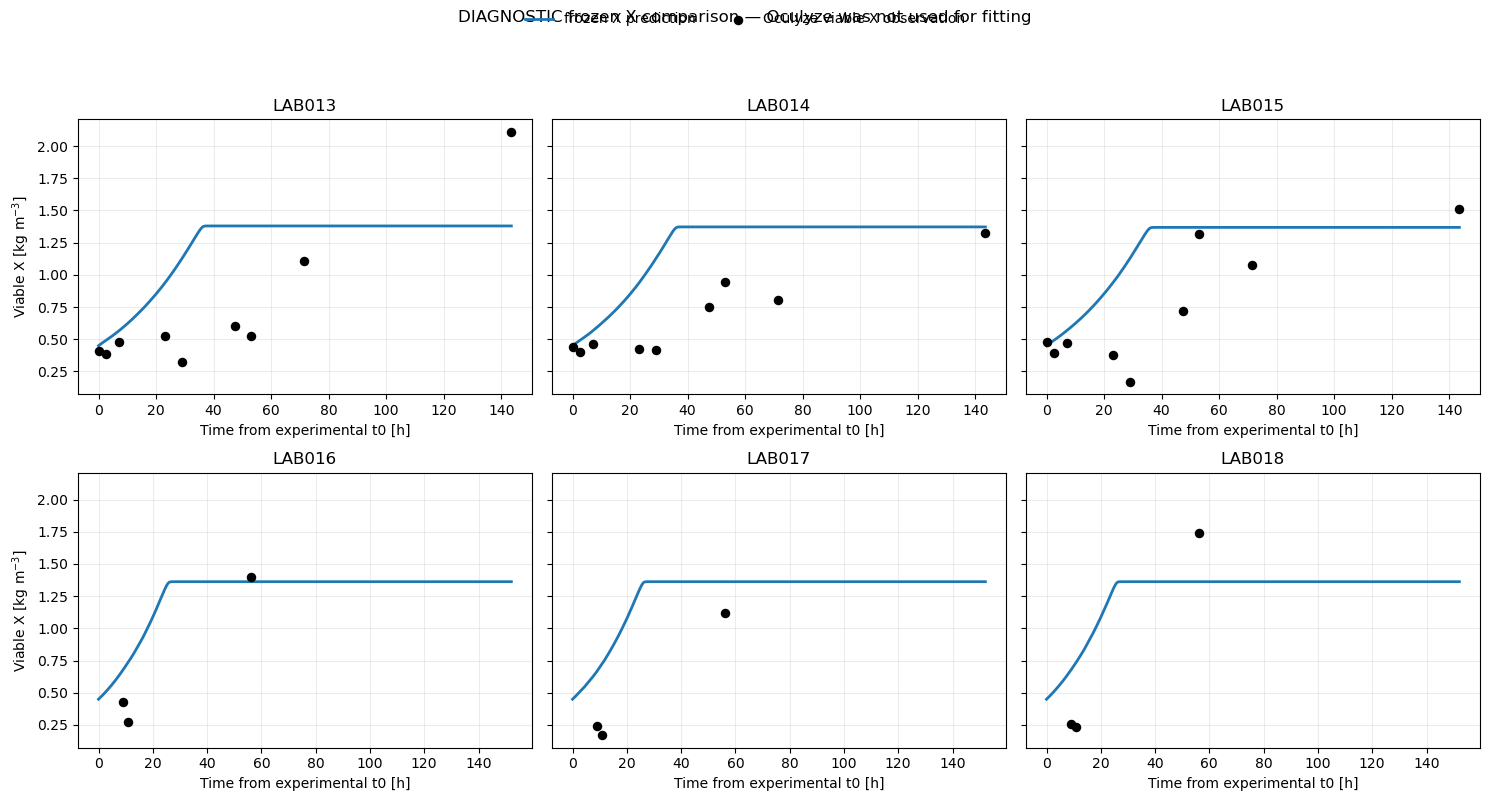

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, lab in zip(axes.flat, BIOMASS_LABS):
    pred = x_predictions[lab]
    observed = biomass_point_table[biomass_point_table['lab_id'].eq(lab)]
    ax.plot(pred['time_h'], pred['X'], color='tab:blue', lw=2.0, label='frozen X prediction')
    ax.scatter(observed['time_h'], observed['X_obs_kg_m3'], color='black', s=34, zorder=3, label='Oculyze viable X observation')
    ax.set_title(lab)
    ax.set_xlabel('Time from experimental t0 [h]')
    ax.grid(alpha=0.23)
axes[0, 0].set_ylabel('Viable X [kg m$^{-3}$]')
axes[1, 0].set_ylabel('Viable X [kg m$^{-3}$]')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('DIAGNOSTIC frozen X comparison — Oculyze was not used for fitting', y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()


### 11.4 Diagnostic conclusion


In [19]:
onset_indexed = onset_table.set_index('LAB')
comparison_indexed = comparison_table.set_index('LAB')
chemical_indexed = chemical_bracket_table.set_index('LAB')
onset_text = ', '.join(f"{lab}: {onset_indexed.loc[lab, 'onset_obs_h']:.2f} h" for lab in LABS)
early_text = ', '.join(f"{lab}: {onset_indexed.loc[lab, 'delta_onset_h_obs_minus_pred']:.2f} h" for lab in LABS)
rmse_text = ', '.join(
    f"{lab}: {comparison_indexed.loc[lab, 'RMSE original']:.3f} → "
    f"{comparison_indexed.loc[lab, 'RMSE shifted']:.3f} g L⁻¹ h⁻¹ "
    f"({comparison_indexed.loc[lab, 'RMSE improvement %']:.1f}% reduction)"
    for lab in LABS
)
peak_text = ', '.join(
    f"{lab}: {comparison_indexed.loc[lab, 'peak-time error original h']:+.2f} → "
    f"{comparison_indexed.loc[lab, 'peak-time error shifted h']:+.2f} h" for lab in LABS
)
auc_text = ', '.join(
    f"{lab}: obs {comparison_indexed.loc[lab, 'AUC obs']:.2f}, "
    f"original {comparison_indexed.loc[lab, 'AUC original']:.2f}, "
    f"shifted {comparison_indexed.loc[lab, 'AUC shifted']:.2f}" for lab in LABS
)
bracket_text = '; '.join(
    f"{lab}: {chemical_indexed.loc[lab, 't_bracket_start_h']:.1f}–"
    f"{chemical_indexed.loc[lab, 't_bracket_end_h']:.1f} h "
    f"({chemical_indexed.loc[lab, 'first_criterion']}; E unavailable)"
    for lab in ('LAB013', 'LAB014', 'LAB015')
)
display(Markdown(f"""
1. **Sustained onset real:** {onset_text}. El peak instrumental de inoculación quedó fuera por la máscara event-aware ya auditada.
2. **Inicio demasiado temprano de la predicción:** {early_text}; estos valores son exactamente onset_obs - onset_pred, no shifts optimizados.
3. **Mejora de RMSE solo por timing:** {rmse_text}.
4. **Error temporal del peak:** {peak_text}. Se reduce mucho, pero no desaparece en todos los LABs; después del shift queda un retraso residual de aproximadamente 1.1–5.0 h.
5. **Amplitud/AUC tras corregir timing:** los peaks predichos permanecen cerca de 0.873–0.878 frente a 0.792–0.814 observados, porque la amplitud no fue modificada. Las AUC son {auc_text}; el gran exceso de AUC original casi desaparece, aunque quedan diferencias de amplitud/forma.
6. **Diagnóstico causal:** el error end-to-end parece **principalmente lag/activation, con un residuo de cinética/amplitud/forma**. Esta atribución es diagnóstica porque el onset observado se usó para desplazar la curva; no cambia ni reemplaza la conclusión del holdout estricto.
7. **Brackets químicos LAB013–LAB015:** {bracket_text}. Solo LAB013 solapa directamente el rango de onsets observados de LAB016–LAB018 (22.30–24.25 h); LAB014 es mucho más temprano y LAB015 más tardío. La comparación es temporalmente sugerente, no una equivalencia ni una transferencia, porque las temperaturas difieren.

**Respuesta principal:** alinear exclusivamente el onset explica aproximadamente {comparison_table['RMSE improvement %'].min():.1f}%–{comparison_table['RMSE improvement %'].max():.1f}% del RMSE según la reducción relativa, pero no corrige por construcción la amplitud ni demuestra qué componente físico origina el lag.
"""))



1. **Sustained onset real:** LAB016: 24.25 h, LAB017: 22.30 h, LAB018: 22.65 h. El peak instrumental de inoculación quedó fuera por la máscara event-aware ya auditada.
2. **Inicio demasiado temprano de la predicción:** LAB016: 18.53 h, LAB017: 16.10 h, LAB018: 16.78 h; estos valores son exactamente onset_obs - onset_pred, no shifts optimizados.
3. **Mejora de RMSE solo por timing:** LAB016: 0.376 → 0.089 g L⁻¹ h⁻¹ (76.3% reduction), LAB017: 0.312 → 0.088 g L⁻¹ h⁻¹ (71.7% reduction), LAB018: 0.326 → 0.095 g L⁻¹ h⁻¹ (70.8% reduction).
4. **Error temporal del peak:** LAB016: -17.40 → +1.12 h, LAB017: -11.48 → +4.62 h, LAB018: -11.78 → +5.00 h. Se reduce mucho, pero no desaparece en todos los LABs; después del shift queda un retraso residual de aproximadamente 1.1–5.0 h.
5. **Amplitud/AUC tras corregir timing:** los peaks predichos permanecen cerca de 0.873–0.878 frente a 0.792–0.814 observados, porque la amplitud no fue modificada. Las AUC son LAB016: obs 17.22, original 31.01, shifted 18.63, LAB017: obs 19.86, original 31.19, shifted 20.01, LAB018: obs 19.14, original 31.28, shifted 19.70; el gran exceso de AUC original casi desaparece, aunque quedan diferencias de amplitud/forma.
6. **Diagnóstico causal:** el error end-to-end parece **principalmente lag/activation, con un residuo de cinética/amplitud/forma**. Esta atribución es diagnóstica porque el onset observado se usó para desplazar la curva; no cambia ni reemplaza la conclusión del holdout estricto.
7. **Brackets químicos LAB013–LAB015:** LAB013: 23.0–29.0 h (G+F drop >= 5 g/L; E unavailable); LAB014: 2.5–4.5 h (G+F drop >= 5 g/L; E unavailable); LAB015: 29.0–47.5 h (G+F drop >= 5 g/L; E unavailable). Solo LAB013 solapa directamente el rango de onsets observados de LAB016–LAB018 (22.30–24.25 h); LAB014 es mucho más temprano y LAB015 más tardío. La comparación es temporalmente sugerente, no una equivalencia ni una transferencia, porque las temperaturas difieren.

**Respuesta principal:** alinear exclusivamente el onset explica aproximadamente 70.8%–76.3% del RMSE según la reducción relativa, pero no corrige por construcción la amplitud ni demuestra qué componente físico origina el lag.


In [20]:
DIAGNOSTIC_HASHES_AFTER = {str(path.relative_to(ROOT)): sha256(path) for path in DIAGNOSTIC_INPUT_PATHS}
assert DIAGNOSTIC_HASHES_AFTER == DIAGNOSTIC_HASHES_BEFORE
assert HASHES_AFTER == HASHES_BEFORE
assert COMMON_RECOVERY_MIN == 90
assert np.allclose(
    diagnostic_metrics_table.query("curve == @DIAGNOSTIC_LABEL")['delta_onset_h'].to_numpy(),
    onset_table['delta_onset_h_obs_minus_pred'].to_numpy(),
)
assert all(batch.pulses['N'] == tuple() for batch in chemical_batches.values())
print('DIAGNOSTIC VALIDATION PASSED')
print('- strict baseline retained and reproduced exactly')
print('- optimizer/fitting calls added: 0')
print('- theta, CO2 parameters, matrix_gain and data files changed: 0')
print('- diagnostic time shifts equal observed-minus-predicted sustained onset exactly')
print('- diagnostic source hashes checked:', len(DIAGNOSTIC_HASHES_AFTER))


DIAGNOSTIC VALIDATION PASSED
- strict baseline retained and reproduced exactly
- optimizer/fitting calls added: 0
- theta, CO2 parameters, matrix_gain and data files changed: 0
- diagnostic time shifts equal observed-minus-predicted sustained onset exactly
- diagnostic source hashes checked: 13


## 12. DIAGNÓSTICO adicional: onset-conditioned chemical activation — NO es holdout externo

Esta prueba mantiene intactos el holdout estricto y el diagnóstico anterior de time-shift. No desplaza la trayectoria upstream ni la curva CO2 final: únicamente reemplaza, dentro de la cadena histórica, la ubicación temporal del gate químico. Usa el sustained onset de CO2 observado y, por tanto, **no es predictiva ni equivale a un bracket químico medido**.

### Mecanismo histórico exacto

La función _chemical_activity_bracket() define \(L\) como la última muestra química anterior y \(U\) como la primera muestra que evidencia actividad por caída de \(G+F\geq5\) g/L o aumento de \(E\geq2\) g/L. Para \(B=U-L>0\), _bounded_smoothstep_activation() usa exactamente:

\[
t_s=L+sB,\qquad D=\max(dB,\Delta t_{\mathrm{grid}}),\qquad
z(t)=\operatorname{clip}\!\left(\frac{t-t_s}{D},0,1\right),\qquad
A(t)=z^2(3-2z),
\]

donde \(s=\) chem_activation_start_fraction y \(d=\) chem_activation_duration_fraction, ambos congelados. Si \(U\leq L\), la implementación devuelve el escalón \(\mathbf{1}(t\geq U)\).

Aquí se usa el pseudo-bracket mínimo \([L,U]=[0,t_{\mathrm{onset,obs}}]\). Es metodológicamente coherente con la semántica histórica: \(U\) es la **primera evidencia de actividad**, no el final de la rampa. Con los valores naturales congelados \(s=0.735057\) y \(d=1.063910\), la rampa empieza en \(0.735057\,t_{\mathrm{onset}}\), termina en \(1.798967\,t_{\mathrm{onset}}\) y \(A(t_{\mathrm{onset}})\approx0.155\). No se fuerza \(A=1\) en el onset ni se deriva un segundo tiempo a partir de una sola referencia.

effective_qprod_grid() conserva la producción biológica, el consumo de O2 y la fracción anaeróbica originales, y aplica \(q_{\mathrm{prod}}=A(t)\,[q_{\mathrm{bio}}f_{\mathrm{ferm}}+q_{\mathrm{resp}}]\). Luego raw_qgas_grid_prediction() integra el mismo pool disuelto y la misma rama continuous_release: fracción disuelta \(C/(C+C_{\mathrm{sat}})\), fracción de liberación \(f_0+(1-f_0)C/(C+C_{\mathrm{sat}})\), liberación potencial \(k_{\mathrm{release}}C f\), limitada por el CO2 disponible. Todos esos parámetros permanecen congelados.


In [21]:
GATE_DIAGNOSTIC_LABEL = 'diagnostic onset-conditioned chemical activation — NOT external holdout'
GATE_SCENARIO = 'A_physical_E0_0'
GATE_START_FRACTION = float(co2_parameters_frozen['chem_activation_start_fraction'])
GATE_DURATION_FRACTION = float(co2_parameters_frozen['chem_activation_duration_fraction'])
GATE_CO2_PARAMETER_SNAPSHOT = dict(co2_parameters_frozen)
STRICT_BASELINE_TABLE_SNAPSHOT = co2_metrics.copy(deep=True)
TIME_SHIFT_TABLE_SNAPSHOT = diagnostic_metrics_table.copy(deep=True)
UPSTREAM_STATES = ('X', 'N', 'G', 'F', 'E', 'Gly')
UPSTREAM_STATE_SNAPSHOT = {
    lab: predictions[(GATE_SCENARIO, lab)][list(UPSTREAM_STATES)].to_numpy(dtype=float).copy()
    for lab in LABS
}

gate_cache_rows = pd.DataFrame([
    {
        'batch': lab, 'matrix': 'natural', 'calibratable': True,
        'chemistry_last_h': float(batch.time[-1]), 't_h': 0.0,
    }
    for lab, batch in scenario_batches[GATE_SCENARIO].items()
])
gate_baseline_caches, gate_cache_diagnostics = co2_cross.build_driver_cache(
    scenario_batches[GATE_SCENARIO], {'natural': theta_frozen}, gate_cache_rows,
)

GATE_FORWARD_KWARGS = {
    'k_release_h': co2_parameters_frozen['kCO2_release_h'],
    'sat_scale': co2_parameters_frozen['CO2sat_scale'],
    'o2_qmax_mg_gdw_h': co2_parameters_frozen['O2_qmax_mg_gdw_h'],
    'o2_initial_scale': co2_parameters_frozen['O2_initial_scale'],
    'chemistry_aligned': True,
    'nitrogen_boost_transition': True,
    'pulse_t_rise_h': co2_parameters_frozen['pulse_t_rise_h'],
    'pulse_activity_gain': co2_parameters_frozen['pulse_activity_gain'],
    'continuous_release': True,
    'bounded_chemical_activation': True,
    'chem_activation_start_fraction': GATE_START_FRACTION,
    'chem_activation_duration_fraction': GATE_DURATION_FRACTION,
}

gate_predictions = {}
gate_pseudo_brackets = {}
gate_mechanism_rows = []
for onset in onset_table.itertuples(index=False):
    lab = onset.LAB
    cache = gate_baseline_caches[lab]
    observed_onset_h = float(onset.onset_obs_h)
    baseline_activation = co2_cross._bounded_smoothstep_activation(
        cache.time_h, cache.chemical_activity_lower_h, cache.chemical_activity_upper_h,
        GATE_START_FRACTION, GATE_DURATION_FRACTION,
    )
    baseline_qgas, baseline_qprod, baseline_o2, baseline_phi = co2_cross.raw_qgas_grid_prediction(
        cache, **GATE_FORWARD_KWARGS
    )
    existing = predictions[(GATE_SCENARIO, lab)]
    assert np.allclose(cache.time_h, existing['time_h'])
    assert np.allclose(
        co2_parameters_frozen['matrix_gain'] * baseline_qgas,
        existing['CO2_pred_g_L_h'], rtol=1e-11, atol=1e-12,
    )
    pre_gate_qprod, pre_gate_o2, pre_gate_phi = co2_cross.effective_qprod_grid(
        cache,
        o2_qmax_mg_gdw_h=co2_parameters_frozen['O2_qmax_mg_gdw_h'],
        o2_initial_scale=co2_parameters_frozen['O2_initial_scale'],
        chemistry_aligned=False,
        nitrogen_boost_transition=True,
        pulse_t_rise_h=co2_parameters_frozen['pulse_t_rise_h'],
        pulse_activity_gain=co2_parameters_frozen['pulse_activity_gain'],
        bounded_chemical_activation=True,
        chem_activation_start_fraction=GATE_START_FRACTION,
        chem_activation_duration_fraction=GATE_DURATION_FRACTION,
    )
    assert np.allclose(pre_gate_o2, baseline_o2)
    assert np.allclose(pre_gate_phi, baseline_phi)
    assert np.allclose(baseline_qprod, baseline_activation * pre_gate_qprod)

    lower_h, upper_h = 0.0, observed_onset_h
    center_h = 0.5 * (lower_h + upper_h)
    scale_h = max(
        co2_cross.CHEMISTRY_ACTIVATION_MIN_SCALE_H,
        (upper_h - lower_h) / (2.0 * np.log(9.0)),
    )
    conditioned_cache = replace(
        cache,
        chemical_activity_lower_h=lower_h,
        chemical_activity_upper_h=upper_h,
        chemical_activity_center_h=center_h,
        chemical_activity_scale_h=scale_h,
    )
    conditioned_activation = co2_cross._bounded_smoothstep_activation(
        cache.time_h, lower_h, upper_h, GATE_START_FRACTION, GATE_DURATION_FRACTION,
    )
    conditioned_qgas, conditioned_qprod, conditioned_o2, conditioned_phi = (
        co2_cross.raw_qgas_grid_prediction(conditioned_cache, **GATE_FORWARD_KWARGS)
    )
    assert np.allclose(conditioned_o2, baseline_o2)
    assert np.allclose(conditioned_phi, baseline_phi)
    assert np.allclose(conditioned_qprod, conditioned_activation * pre_gate_qprod)

    gate_pseudo_brackets[lab] = conditioned_cache
    gate_predictions[lab] = pd.DataFrame({
        'time_h': cache.time_h,
        'activation_baseline': baseline_activation,
        'activation_conditioned': conditioned_activation,
        'pre_chemical_gate_qprod_g_L_h': pre_gate_qprod,
        'effective_qprod_conditioned_g_L_h': conditioned_qprod,
        'qgas_conditioned_g_L_h': conditioned_qgas,
        'CO2_activation_conditioned_g_L_h': co2_parameters_frozen['matrix_gain'] * conditioned_qgas,
    })
    ramp_start_h = lower_h + GATE_START_FRACTION * (upper_h - lower_h)
    ramp_duration_h = max(
        GATE_DURATION_FRACTION * (upper_h - lower_h), co2_cross.DRIVER_GRID_H,
    )
    gate_mechanism_rows.append({
        'LAB': lab, 'pseudo_bracket_start_h': lower_h,
        'pseudo_bracket_end_h': upper_h, 'ramp_start_h': ramp_start_h,
        'ramp_end_h': ramp_start_h + ramp_duration_h,
        'activation_at_observed_onset': float(np.interp(
            observed_onset_h, cache.time_h, conditioned_activation
        )),
        'start_fraction_frozen': GATE_START_FRACTION,
        'duration_fraction_frozen': GATE_DURATION_FRACTION,
    })

gate_mechanism_table = pd.DataFrame(gate_mechanism_rows)
display(gate_mechanism_table.round(4))


,LAB,pseudo_bracket_start_h,pseudo_bracket_end_h,ramp_start_h,ramp_end_h,activation_at_observed_onset,start_fraction_frozen,duration_fraction_frozen
0,LAB016,0.0,24.2491,17.8244,43.6232,0.1552,0.7351,1.0639
1,LAB017,0.0,22.2981,16.3904,40.1136,0.1552,0.7351,1.0639
2,LAB018,0.0,22.6475,16.6472,40.7420,0.1552,0.7351,1.0639


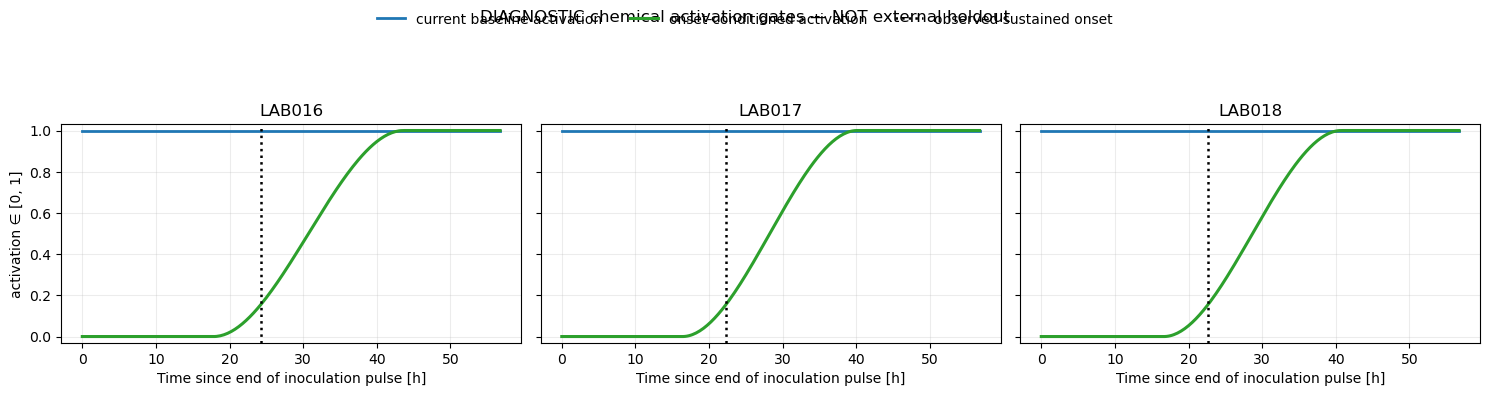

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharex=False, sharey=True)
for ax, onset in zip(axes, onset_table.itertuples(index=False)):
    lab = onset.LAB
    profile = gate_predictions[lab]
    within = profile['time_h'].le(FIRST_POSSIBLE_NUTRITION_H[lab])
    ax.plot(profile.loc[within, 'time_h'], profile.loc[within, 'activation_baseline'], color='tab:blue', lw=2.0, label='current baseline activation')
    ax.plot(profile.loc[within, 'time_h'], profile.loc[within, 'activation_conditioned'], color='tab:green', lw=2.2, label='onset-conditioned activation')
    ax.axvline(onset.onset_obs_h, color='black', ls=':', lw=1.8, label='observed sustained onset')
    ax.set_title(lab)
    ax.set_xlabel('Time since end of inoculation pulse [h]')
    ax.set_ylim(-0.03, 1.03)
    ax.grid(alpha=0.23)
axes[0].set_ylabel('activation ∈ [0, 1]')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
fig.suptitle('DIAGNOSTIC chemical activation gates — NOT external holdout', y=1.03)
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()


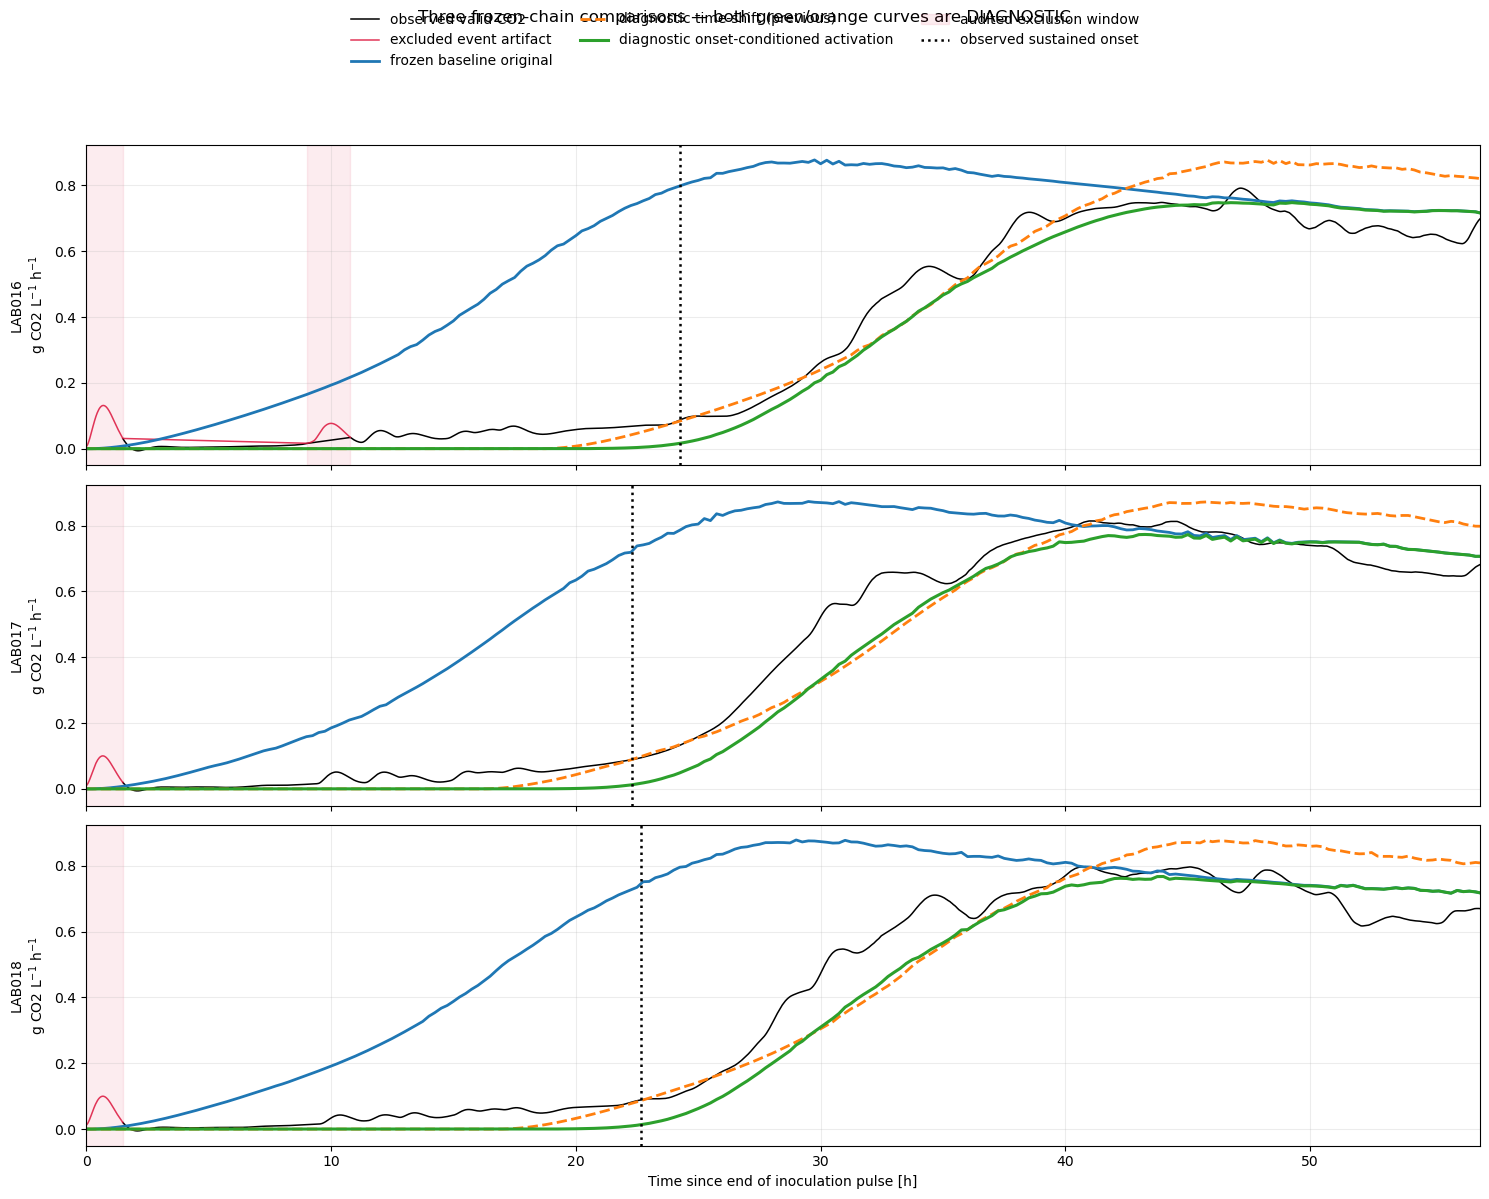

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True, sharey=True)
for ax, onset in zip(axes, onset_table.itertuples(index=False)):
    lab = onset.LAB
    co2 = signals[lab]['co2_filt']
    baseline = predictions[(GATE_SCENARIO, lab)]
    conditioned = gate_predictions[lab]
    pre = co2['time_h'].ge(0) & co2['time_h'].lt(FIRST_POSSIBLE_NUTRITION_H[lab])
    valid = pre & co2['co2_valid_for_fitting']
    excluded = pre & ~co2['co2_valid_for_fitting']
    ax.plot(co2.loc[valid, 'time_h'], co2.loc[valid, 'CO2_obs_g_L_h'], color='black', lw=1.1, label='observed valid CO2')
    ax.plot(co2.loc[excluded, 'time_h'], co2.loc[excluded, 'CO2_obs_g_L_h'], color='crimson', lw=1.1, alpha=0.85, label='excluded event artifact')
    ax.plot(baseline['time_h'], baseline['CO2_pred_g_L_h'], color='tab:blue', lw=2.0, label='frozen baseline original')
    shifted_grid = shifted_prediction_at(baseline['time_h'], baseline, onset.delta_onset_h_obs_minus_pred)
    ax.plot(baseline['time_h'], shifted_grid, color='tab:orange', lw=2.0, ls='--', label='diagnostic time-shift (previous)')
    ax.plot(conditioned['time_h'], conditioned['CO2_activation_conditioned_g_L_h'], color='tab:green', lw=2.2, label='diagnostic onset-conditioned activation')
    for number, (start, end) in enumerate(EXCLUSION_WINDOWS[lab]):
        start_h = (start - T0_BY_LAB[lab]).total_seconds() / 3600.0
        end_h = (end - T0_BY_LAB[lab]).total_seconds() / 3600.0
        if end_h >= 0 and start_h < FIRST_POSSIBLE_NUTRITION_H[lab]:
            ax.axvspan(
                max(0.0, start_h), min(FIRST_POSSIBLE_NUTRITION_H[lab], end_h),
                color='crimson', alpha=0.08,
                label='audited exclusion window' if number == 0 else None,
            )
    ax.axvline(onset.onset_obs_h, color='black', ls=':', lw=1.8, label='observed sustained onset')
    ax.set_xlim(0, FIRST_POSSIBLE_NUTRITION_H[lab])
    ax.set_ylabel(f'{lab}\ng CO2 L$^{{-1}}$ h$^{{-1}}$')
    ax.grid(alpha=0.23)
axes[-1].set_xlabel('Time since end of inoculation pulse [h]')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
fig.suptitle('Three frozen-chain comparisons — both green/orange curves are DIAGNOSTIC', y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()


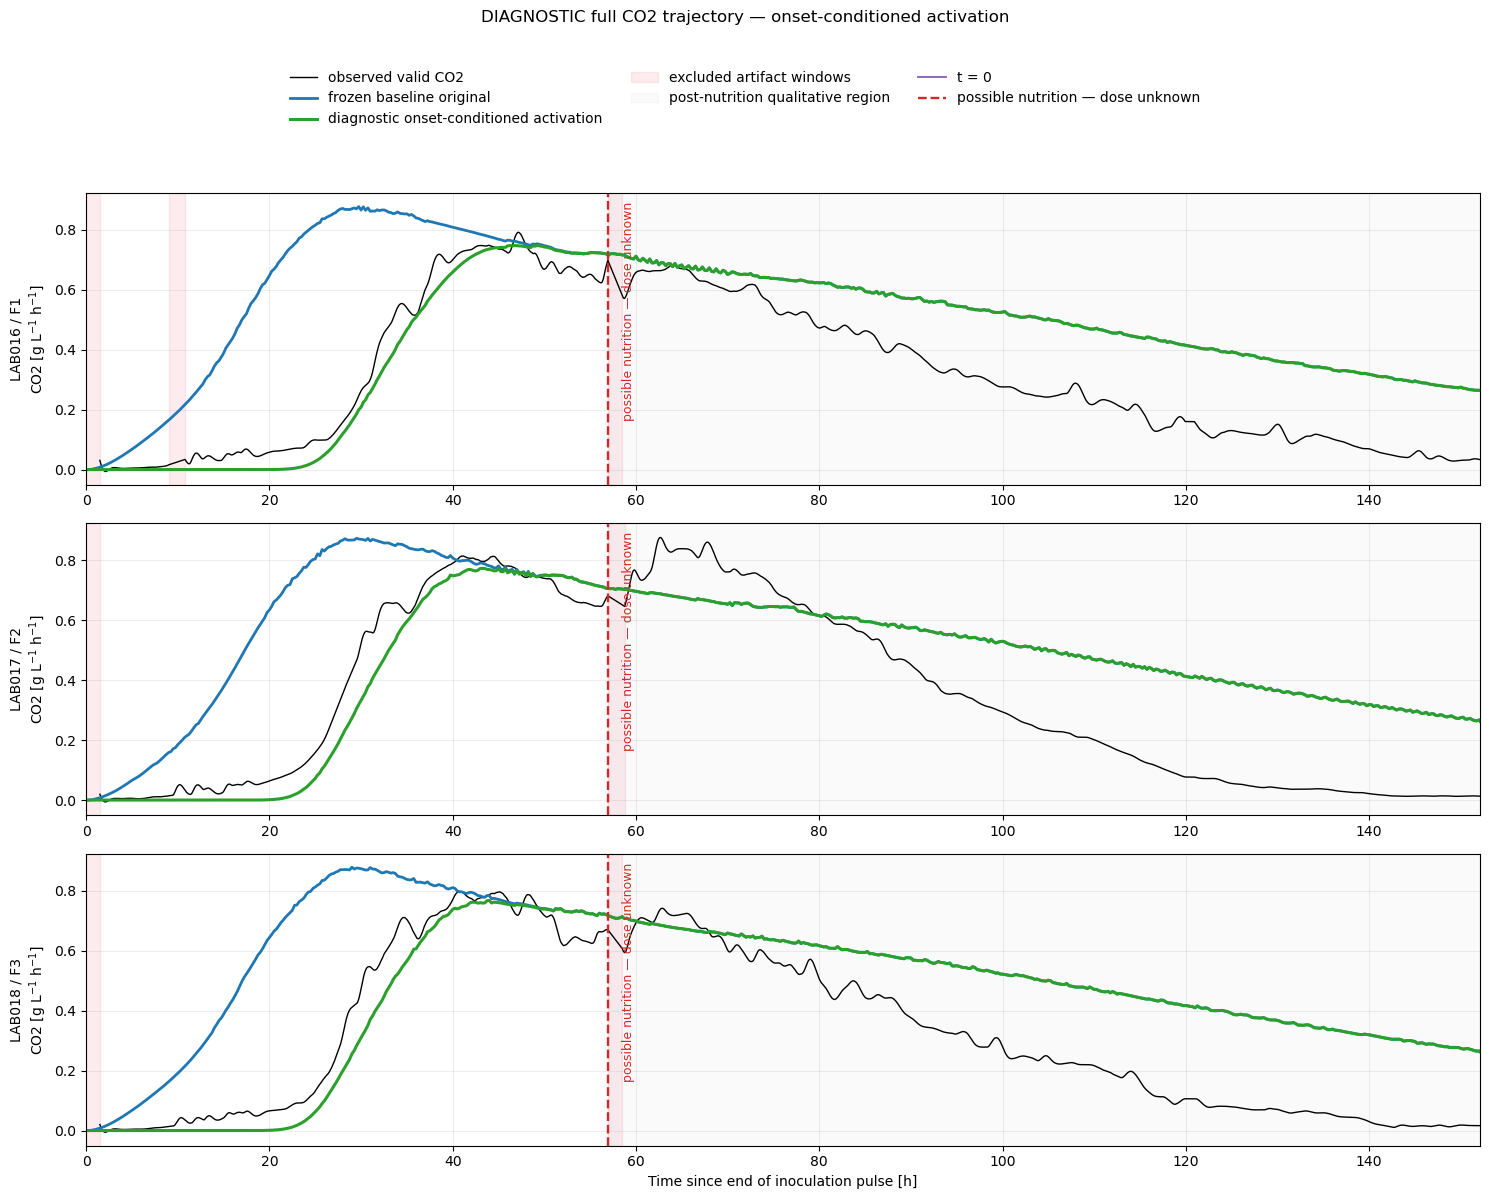

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=False, sharey=True)
for ax, lab in zip(axes, LABS):
    co2 = signals[lab]['co2_filt']
    baseline = predictions[(GATE_SCENARIO, lab)]
    conditioned = gate_predictions[lab]
    record = co2['time_h'].ge(0)
    valid = (
        record
        & co2['co2_valid_for_fitting']
        & np.isfinite(co2['CO2_obs_g_L_h'])
    )
    x_max = float(co2.loc[record, 'time_h'].max())
    nutrition_h = float(FIRST_POSSIBLE_NUTRITION_H[lab])

    ax.plot(
        co2.loc[valid, 'time_h'], co2.loc[valid, 'CO2_obs_g_L_h'],
        color='black', lw=1.0, label='observed valid CO2',
    )
    ax.plot(
        baseline['time_h'], baseline['CO2_pred_g_L_h'],
        color='tab:blue', lw=2.0, label='frozen baseline original',
    )
    ax.plot(
        conditioned['time_h'], conditioned['CO2_activation_conditioned_g_L_h'],
        color='tab:green', lw=2.2,
        label='diagnostic onset-conditioned activation',
    )

    for number, (start, end) in enumerate(EXCLUSION_WINDOWS[lab]):
        start_h = (start - T0_BY_LAB[lab]).total_seconds() / 3600.0
        end_h = (end - T0_BY_LAB[lab]).total_seconds() / 3600.0
        if end_h >= 0 and start_h <= x_max:
            ax.axvspan(
                max(0.0, start_h), min(x_max, end_h),
                color='crimson', alpha=0.08,
                label='excluded artifact windows' if number == 0 else None,
            )

    ax.axvspan(
        nutrition_h, x_max, color='0.5', alpha=0.035,
        label='post-nutrition qualitative region',
    )
    ax.axvline(0.0, color='tab:purple', lw=1.4, label='t = 0')
    ax.axvline(
        nutrition_h, color='tab:red', ls='--', lw=1.7,
        label='possible nutrition — dose unknown',
    )
    ax.text(
        nutrition_h + 1.5, 0.97, 'possible nutrition — dose unknown',
        transform=ax.get_xaxis_transform(), color='tab:red',
        rotation=90, va='top', ha='left', fontsize=9,
    )
    ax.set_xlim(0.0, x_max)
    ax.set_ylabel(f"{lab} / {LABS[lab]['fermenter']}\nCO2 [g L$^{{-1}}$ h$^{{-1}}$]")
    ax.grid(alpha=0.22)
axes[-1].set_xlabel('Time since end of inoculation pulse [h]')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc='upper center', ncol=3, frameon=False,
    bbox_to_anchor=(0.5, 0.955),
)
fig.suptitle(
    'DIAGNOSTIC full CO2 trajectory — onset-conditioned activation',
    y=0.995,
)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()


### 12.1 Full CO2 trajectory — qualitative diagnostic

The onset-focused figure above is retained unchanged. The panels above extend the same already-generated activation-conditioned trajectory to the end of each real record.

> Post-nutrition behavior is shown for qualitative diagnosis only because the nutrition dose/composition is not documented and no N jump is introduced in the frozen model.

The quantitative metrics below remain restricted to the clean pre-nutrition window.


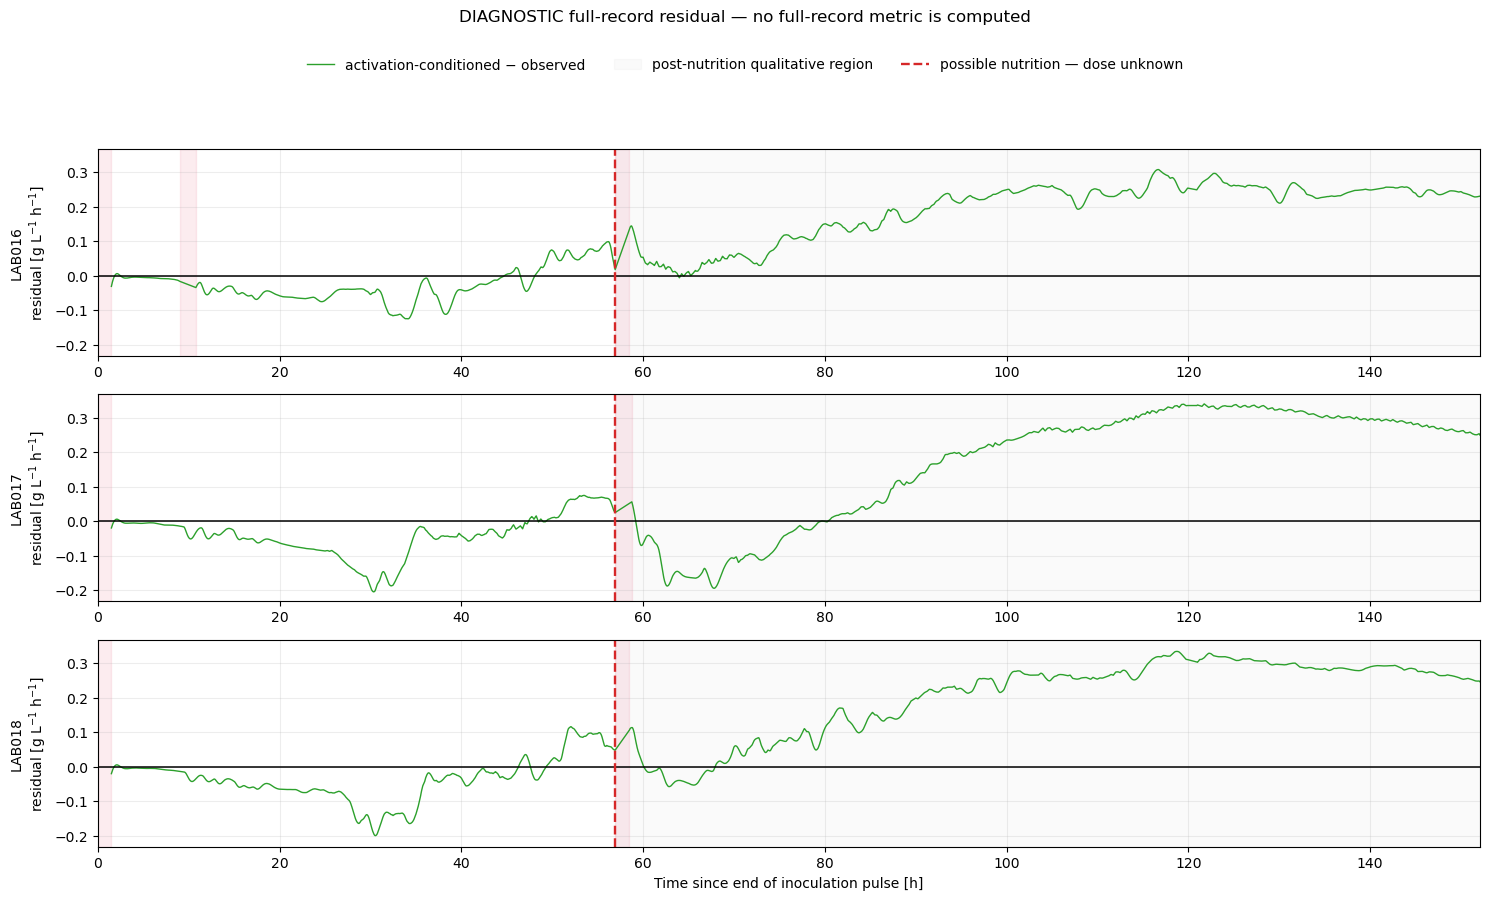

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=False, sharey=True)
for ax, lab in zip(axes, LABS):
    co2 = signals[lab]['co2_filt']
    conditioned = gate_predictions[lab]
    record = co2['time_h'].ge(0)
    valid = (
        record
        & co2['co2_valid_for_fitting']
        & np.isfinite(co2['CO2_obs_g_L_h'])
    )
    x_max = float(co2.loc[record, 'time_h'].max())
    nutrition_h = float(FIRST_POSSIBLE_NUTRITION_H[lab])
    conditioned_at_observations = np.interp(
        co2['time_h'],
        conditioned['time_h'],
        conditioned['CO2_activation_conditioned_g_L_h'],
    )
    residual = conditioned_at_observations - co2['CO2_obs_g_L_h'].to_numpy(dtype=float)

    ax.plot(
        co2.loc[valid, 'time_h'], residual[valid],
        color='tab:green', lw=1.0,
        label='activation-conditioned − observed',
    )
    ax.axhline(0.0, color='black', lw=1.1)
    ax.axvspan(
        nutrition_h, x_max, color='0.5', alpha=0.035,
        label='post-nutrition qualitative region',
    )
    ax.axvline(
        nutrition_h, color='tab:red', ls='--', lw=1.7,
        label='possible nutrition — dose unknown',
    )
    for start, end in EXCLUSION_WINDOWS[lab]:
        start_h = (start - T0_BY_LAB[lab]).total_seconds() / 3600.0
        end_h = (end - T0_BY_LAB[lab]).total_seconds() / 3600.0
        if end_h >= 0 and start_h <= x_max:
            ax.axvspan(
                max(0.0, start_h), min(x_max, end_h),
                color='crimson', alpha=0.08,
            )
    ax.set_xlim(0.0, x_max)
    ax.set_ylabel(f'{lab}\nresidual [g L$^{{-1}}$ h$^{{-1}}$]')
    ax.grid(alpha=0.22)
axes[-1].set_xlabel('Time since end of inoculation pulse [h]')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc='upper center', ncol=3, frameon=False,
    bbox_to_anchor=(0.5, 0.955),
)
fig.suptitle(
    'DIAGNOSTIC full-record residual — no full-record metric is computed',
    y=0.995,
)
fig.tight_layout(rect=(0, 0, 1, 0.89))
plt.show()


**Visual reading of the complete trajectory.** The activation-conditioned mechanism approximately corrects the onset, with the previously reported residual delay of about 2.9–3.1 h. Peak timing is also reasonably aligned (about 2.1–3.2 h late) and peak amplitude is slightly low but comparable to observation. The decline and final tail do not remain uniformly aligned over the complete record. The clean pre-nutrition interval contains the interpretable timing improvement; the most consequential later discrepancies are visible after the possible nutrition event and remain qualitative because its dose and composition are unknown.


In [26]:
gate_metric_rows = []
gate_onset_rows = []
for onset in onset_table.itertuples(index=False):
    lab = onset.LAB
    co2 = signals[lab]['co2_filt']
    conditioned = gate_predictions[lab]
    conditioned_at_observations = np.interp(
        co2['time_h'], conditioned['time_h'], conditioned['CO2_activation_conditioned_g_L_h'],
    )
    conditioned_metrics = diagnostic_metrics(lab, conditioned_at_observations)
    gate_metric_rows.append({'LAB': lab, **conditioned_metrics})
    hourly = onset_profiles[lab]
    conditioned_hourly = np.interp(
        hourly['t_h'], conditioned['time_h'], conditioned['CO2_activation_conditioned_g_L_h'],
    )
    conditioned_onset_h = co2_cross._sustained_onset_h(
        hourly['t_h'].to_numpy(), conditioned_hourly, onset.threshold_g_L_h,
        consecutive=ONSET_CONSECUTIVE_POINTS,
    )
    assert np.isfinite(conditioned_onset_h)
    gate_onset_rows.append({
        'LAB': lab, 'onset_obs_h': onset.onset_obs_h,
        'onset_baseline_h': onset.onset_pred_h,
        'onset_activation_conditioned_h': conditioned_onset_h,
        'error_baseline_h': onset.onset_pred_h - onset.onset_obs_h,
        'error_activation_conditioned_h': conditioned_onset_h - onset.onset_obs_h,
    })

gate_metrics_table = pd.DataFrame(gate_metric_rows).set_index('LAB')
gate_onset_table = pd.DataFrame(gate_onset_rows)
gate_comparison_rows = []
for lab in LABS:
    baseline = comparison_indexed.loc[lab]
    conditioned = gate_metrics_table.loc[lab]
    gate_comparison_rows.append({
        'LAB': lab,
        'RMSE baseline': baseline['RMSE original'],
        'RMSE time-shift': baseline['RMSE shifted'],
        'RMSE activation-conditioned': conditioned['RMSE'],
        'RMSE reduction vs baseline %': 100.0 * (1.0 - conditioned['RMSE'] / baseline['RMSE original']),
        'bias baseline': baseline['bias original'],
        'bias activation-conditioned': conditioned['bias'],
        'peak time obs': conditioned['tpeak_obs_h'],
        'peak time baseline': baseline['peak-time error original h'] + conditioned['tpeak_obs_h'],
        'peak time activation-conditioned': conditioned['tpeak_pred_h'],
        'peak amplitude obs': conditioned['peak_obs'],
        'peak amplitude baseline': baseline['peak pred original'],
        'peak amplitude activation-conditioned': conditioned['peak_pred'],
        'AUC obs': conditioned['AUC_obs'],
        'AUC baseline': baseline['AUC original'],
        'AUC activation-conditioned': conditioned['AUC_pred'],
    })
gate_comparison_table = pd.DataFrame(gate_comparison_rows)
print('Same audited artifact mask and pre-nutrition support as the strict baseline and time-shift diagnostic.')
display(gate_comparison_table.round(4))
display(gate_onset_table.round(4))


Same audited artifact mask and pre-nutrition support as the strict baseline and time-shift diagnostic.


,LAB,RMSE baseline,RMSE time-shift,RMSE activation-conditioned,RMSE reduction vs baseline %,bias baseline,bias activation-conditioned,peak time obs,peak time baseline,peak time activation-conditioned,peak amplitude obs,peak amplitude baseline,peak amplitude activation-conditioned,AUC obs,AUC baseline,AUC activation-conditioned
0,LAB016,0.3759,0.0892,0.0532,85.8448,0.2759,-0.0241,47.1528,29.7497,49.2500,0.7918,0.8775,0.7478,17.2231,31.0086,16.1230
1,LAB017,0.3123,0.0883,0.0715,77.1055,0.2173,-0.0399,40.9842,29.5000,43.2508,0.8142,0.8733,0.7732,19.8593,31.1854,17.8628
2,LAB018,0.3262,0.0953,0.0711,78.1996,0.2320,-0.0346,40.7789,29.0014,43.9978,0.7976,0.8786,0.7676,19.1391,31.2757,17.4898


,LAB,onset_obs_h,onset_baseline_h,onset_activation_conditioned_h,error_baseline_h,error_activation_conditioned_h
0,LAB016,24.2491,5.7239,27.1071,-18.5251,2.8581
1,LAB017,22.2981,6.1939,25.4240,-16.1042,3.1259
2,LAB018,22.6475,5.8699,25.6466,-16.7775,2.9991


### Interpretación permitida

El sustained onset de CO2 **no es químicamente equivalente** a _chemical_activity_bracket(). El pseudo-bracket usa CO2 observado únicamente para posicionar el mecanismo histórico y aislar su efecto; no aporta mediciones post-inoculación de G/F/E, no es un holdout predictivo y no debe presentarse como una solución o parametrización final.


In [27]:
gate_comparison_indexed = gate_comparison_table.set_index('LAB')
gate_onset_indexed = gate_onset_table.set_index('LAB')
gate_rmse_text = ', '.join(
    f"{lab}: {gate_comparison_indexed.loc[lab, 'RMSE baseline']:.3f} → "
    f"{gate_comparison_indexed.loc[lab, 'RMSE activation-conditioned']:.3f} "
    f"({gate_comparison_indexed.loc[lab, 'RMSE reduction vs baseline %']:.1f}% reduction)"
    for lab in LABS
)
gate_onset_text = ', '.join(
    f"{lab}: obs {gate_onset_indexed.loc[lab, 'onset_obs_h']:.2f}, "
    f"baseline {gate_onset_indexed.loc[lab, 'onset_baseline_h']:.2f}, "
    f"activation {gate_onset_indexed.loc[lab, 'onset_activation_conditioned_h']:.2f} h"
    for lab in LABS
)
gate_peak_text = ', '.join(
    f"{lab}: obs {gate_comparison_indexed.loc[lab, 'peak time obs']:.2f}, "
    f"baseline {gate_comparison_indexed.loc[lab, 'peak time baseline']:.2f}, "
    f"activation {gate_comparison_indexed.loc[lab, 'peak time activation-conditioned']:.2f} h"
    for lab in LABS
)
gate_auc_text = ', '.join(
    f"{lab}: obs {gate_comparison_indexed.loc[lab, 'AUC obs']:.2f}, "
    f"baseline {gate_comparison_indexed.loc[lab, 'AUC baseline']:.2f}, "
    f"activation {gate_comparison_indexed.loc[lab, 'AUC activation-conditioned']:.2f}"
    for lab in LABS
)
gate_amplitude_text = ', '.join(
    f"{lab}: obs {gate_comparison_indexed.loc[lab, 'peak amplitude obs']:.3f}, "
    f"activation {gate_comparison_indexed.loc[lab, 'peak amplitude activation-conditioned']:.3f}"
    for lab in LABS
)
gate_beats_shift = all(
    gate_comparison_indexed.loc[lab, 'RMSE activation-conditioned']
    < gate_comparison_indexed.loc[lab, 'RMSE time-shift']
    for lab in LABS
)

display(Markdown(f"""
1. **¿Reproduce el lag observado?** Aproximadamente: {gate_onset_text}. El error de onset pasa de 16.10–18.53 h demasiado temprano a 2.86–3.13 h demasiado tarde. No se fuerza una coincidencia exacta porque el onset ubica el extremo superior del pseudo-bracket, no el final de la rampa histórica.
2. **Mejora de RMSE respecto al baseline:** {gate_rmse_text} g L⁻¹ h⁻¹.
3. **Comparación con el time-shift:** {'la activación condicionada obtiene menor RMSE que el time-shift en los tres LABs' if gate_beats_shift else 'la activación condicionada no supera uniformemente al time-shift'}. Es una modificación interna del gate; no una traslación de la señal.
4. **Tiempo del peak sin desplazar upstream:** {gate_peak_text}. El error se reduce a aproximadamente 2.10–3.22 h, manteniendo X, N, G, F, E y Gly en sus tiempos originales.
5. **Amplitud/AUC residual:** amplitudes {gate_amplitude_text}; AUC {gate_auc_text}. El exceso grande del baseline se elimina, pero ahora la AUC queda algo por debajo de la observada y persisten diferencias de amplitud/forma.
6. **¿Confirma un problema de posicionamiento del gate?** Confirma que reposicionar el mecanismo histórico es suficiente para explicar una parte muy importante del lag y del RMSE. No identifica causalmente un bracket químico real porque la referencia temporal proviene del CO2 observado.
7. **Residuo después de corregir solo la activación:** quedan 2.86–3.13 h de error de onset, 2.10–3.22 h de error de peak y residuo de amplitud/AUC. Esas señales todavía son compatibles con error upstream, con la forma/duración congelada del gate o con la dinámica continuous_release; este diagnóstico por sí solo no permite separarlos.

**Conclusión:** la mejora no requiere desplazar los estados upstream ni alterar parámetros, y es al menos tan grande como la del time-shift. Esto apoya al posicionamiento del chemical activation gate como explicación importante, pero no convierte el pseudo-bracket en evidencia química ni en una solución final.
"""))



1. **¿Reproduce el lag observado?** Aproximadamente: LAB016: obs 24.25, baseline 5.72, activation 27.11 h, LAB017: obs 22.30, baseline 6.19, activation 25.42 h, LAB018: obs 22.65, baseline 5.87, activation 25.65 h. El error de onset pasa de 16.10–18.53 h demasiado temprano a 2.86–3.13 h demasiado tarde. No se fuerza una coincidencia exacta porque el onset ubica el extremo superior del pseudo-bracket, no el final de la rampa histórica.
2. **Mejora de RMSE respecto al baseline:** LAB016: 0.376 → 0.053 (85.8% reduction), LAB017: 0.312 → 0.071 (77.1% reduction), LAB018: 0.326 → 0.071 (78.2% reduction) g L⁻¹ h⁻¹.
3. **Comparación con el time-shift:** la activación condicionada obtiene menor RMSE que el time-shift en los tres LABs. Es una modificación interna del gate; no una traslación de la señal.
4. **Tiempo del peak sin desplazar upstream:** LAB016: obs 47.15, baseline 29.75, activation 49.25 h, LAB017: obs 40.98, baseline 29.50, activation 43.25 h, LAB018: obs 40.78, baseline 29.00, activation 44.00 h. El error se reduce a aproximadamente 2.10–3.22 h, manteniendo X, N, G, F, E y Gly en sus tiempos originales.
5. **Amplitud/AUC residual:** amplitudes LAB016: obs 0.792, activation 0.748, LAB017: obs 0.814, activation 0.773, LAB018: obs 0.798, activation 0.768; AUC LAB016: obs 17.22, baseline 31.01, activation 16.12, LAB017: obs 19.86, baseline 31.19, activation 17.86, LAB018: obs 19.14, baseline 31.28, activation 17.49. El exceso grande del baseline se elimina, pero ahora la AUC queda algo por debajo de la observada y persisten diferencias de amplitud/forma.
6. **¿Confirma un problema de posicionamiento del gate?** Confirma que reposicionar el mecanismo histórico es suficiente para explicar una parte muy importante del lag y del RMSE. No identifica causalmente un bracket químico real porque la referencia temporal proviene del CO2 observado.
7. **Residuo después de corregir solo la activación:** quedan 2.86–3.13 h de error de onset, 2.10–3.22 h de error de peak y residuo de amplitud/AUC. Esas señales todavía son compatibles con error upstream, con la forma/duración congelada del gate o con la dinámica continuous_release; este diagnóstico por sí solo no permite separarlos.

**Conclusión:** la mejora no requiere desplazar los estados upstream ni alterar parámetros, y es al menos tan grande como la del time-shift. Esto apoya al posicionamiento del chemical activation gate como explicación importante, pero no convierte el pseudo-bracket en evidencia química ni en una solución final.


In [28]:
pd.testing.assert_frame_equal(co2_metrics, STRICT_BASELINE_TABLE_SNAPSHOT)
pd.testing.assert_frame_equal(diagnostic_metrics_table, TIME_SHIFT_TABLE_SNAPSHOT)
assert co2_parameters_frozen == GATE_CO2_PARAMETER_SNAPSHOT
assert sha256(THETA_PATH) == HASHES_BEFORE[str(THETA_PATH.relative_to(ROOT))]
assert sha256(CO2_PARAMETER_PATH) == HASHES_BEFORE[str(CO2_PARAMETER_PATH.relative_to(ROOT))]
for lab in LABS:
    assert np.array_equal(
        predictions[(GATE_SCENARIO, lab)][list(UPSTREAM_STATES)].to_numpy(dtype=float),
        UPSTREAM_STATE_SNAPSHOT[lab],
    )
    pseudo = gate_pseudo_brackets[lab]
    assert pseudo.chemical_activity_lower_h == 0.0
    assert np.isclose(pseudo.chemical_activity_upper_h, onset_indexed.loc[lab, 'onset_obs_h'])
    profile = gate_predictions[lab]
    assert np.allclose(
        profile['effective_qprod_conditioned_g_L_h'],
        profile['activation_conditioned'] * profile['pre_chemical_gate_qprod_g_L_h'],
    )
assert HASHES_AFTER == HASHES_BEFORE
print('ONSET-CONDITIONED ACTIVATION DIAGNOSTIC VALIDATION PASSED')
print('- strict holdout and previous time-shift diagnostic unchanged')
print('- optimizer/fitting calls added: 0')
print('- theta, CO2 parameters, matrix_gain and kCO2_release changes: 0')
print('- upstream state trajectory shifts/changes: 0')
print('- only the historical bounded chemical activation gate was repositioned')


ONSET-CONDITIONED ACTIVATION DIAGNOSTIC VALIDATION PASSED
- strict holdout and previous time-shift diagnostic unchanged
- optimizer/fitting calls added: 0
- theta, CO2 parameters, matrix_gain and kCO2_release changes: 0
- upstream state trajectory shifts/changes: 0
- only the historical bounded chemical activation gate was repositioned


## 13. DIAGNÓSTICO: historical nitrogen-pulse architecture with assumed experimental dose

This is a forward diagnostic only. The dose is **reported by operator with ~90% confidence, pending final confirmation**, so this section is **NOT an external holdout** and does not alter any official pre-nutrition metric.

The historical protocol is retained exactly: 1.0 g SpringFerm Xtrem + 0.4 g FDA in a 2 L reactor, using the repository conversion to $\Delta N=0.14\ \mathrm{kg\,m^{-3}}$ per normal dose. `base.simulate` applies exact state jumps at the ledger timestamps. All kinetic, CO2, onset-conditioned activation, release and matrix parameters remain frozen.

**Historical API limitation.** `base.simulate` supports multiple exact pulses, but `co2_cross.build_driver_cache` explicitly supports only one in-process N pulse. Therefore LAB017 is evaluated in two forms without changing library code: (A) the preferred two exact upstream jumps of 0.14 + 0.14 kg/m³, with the frozen scalar utilization transition anchored at the first event and the total 0.28 kg/m³ dose; and (B) one equivalent 0.28 kg/m³ jump at the first event. Their sensitivity is reported separately.


In [29]:
NPULSE_DIAGNOSTIC_LABEL = 'diagnostic onset-conditioned + assumed N pulse — NOT external holdout'
NPULSE_DOSE_STATUS = 'reported by operator with ~90% confidence, pending final confirmation'
NPULSE_NORMAL_DOSE_N_KG_M3 = 0.14
NPULSE_PROTOCOL_SPRINGFERM_G = float(co2_cross.SPRINGFERM_XTREM_G)
NPULSE_PROTOCOL_FDA_G = float(co2_cross.FDA_G)
NPULSE_PROTOCOL_YAN_MG_PER_MG = float(co2_cross.YAN_MG_PER_MG_PRODUCT)
NPULSE_REACTOR_VOLUME_L = 2.0
NPULSE_PROTOCOL_DOSE_N_KG_M3 = (
    (NPULSE_PROTOCOL_SPRINGFERM_G + NPULSE_PROTOCOL_FDA_G)
    * 1000.0 * NPULSE_PROTOCOL_YAN_MG_PER_MG
    / NPULSE_REACTOR_VOLUME_L / 1000.0
)
assert np.isclose(NPULSE_PROTOCOL_DOSE_N_KG_M3, NPULSE_NORMAL_DOSE_N_KG_M3)

NPULSE_THETA_SNAPSHOT = dict(theta_frozen)
NPULSE_CO2_PARAMETER_SNAPSHOT = dict(co2_parameters_frozen)
NPULSE_STRICT_METRICS_SNAPSHOT = co2_metrics.copy(deep=True)
NPULSE_TIME_SHIFT_SNAPSHOT = diagnostic_metrics_table.copy(deep=True)
NPULSE_GATE_PREDICTION_SNAPSHOT = {
    lab: gate_predictions[lab].copy(deep=True) for lab in LABS
}

npulse_schedules = {}
npulse_schedule_rows = []
for lab in LABS:
    events = pulse_table[
        pulse_table['LAB'].eq(lab)
        & pulse_table['classification'].str.startswith('possible later nutrition')
    ].sort_values('pulse_start_h')
    expected_count = 2 if lab == 'LAB017' else 1
    assert len(events) == expected_count
    schedule = tuple(
        (float(event.pulse_start_h), NPULSE_NORMAL_DOSE_N_KG_M3)
        for event in events.itertuples(index=False)
    )
    npulse_schedules[lab] = schedule
    for event_number, ((time_h, amount), event) in enumerate(
        zip(schedule, events.itertuples(index=False)), start=1,
    ):
        npulse_schedule_rows.append({
            'LAB': lab, 'fermenter': LABS[lab]['fermenter'],
            'event_number': event_number, 'ledger_timestamp': event.pulse_start,
            'pulse_time_h_exact': time_h, 'delta_N_kg_m3': amount,
            'dose_status': NPULSE_DOSE_STATUS,
        })
npulse_schedule_table = pd.DataFrame(npulse_schedule_rows)
assert np.isclose(npulse_schedule_table.groupby('LAB')['delta_N_kg_m3'].sum()['LAB017'], 0.28)
assert npulse_schedule_table.groupby('LAB').size().to_dict() == {'LAB016': 1, 'LAB017': 2, 'LAB018': 1}
print(NPULSE_DIAGNOSTIC_LABEL)
print('Dose status:', NPULSE_DOSE_STATUS)
print('Historical protocol-derived normal dose:', NPULSE_PROTOCOL_DOSE_N_KG_M3, 'kg/m3')
display(npulse_schedule_table)


diagnostic onset-conditioned + assumed N pulse — NOT external holdout
Dose status: reported by operator with ~90% confidence, pending final confirmation
Historical protocol-derived normal dose: 0.14 kg/m3


,LAB,fermenter,event_number,ledger_timestamp,pulse_time_h_exact,delta_N_kg_m3,dose_status
0,LAB016,F1,1,2026-09-03 09:00:03,56.935556,0.14,"reported by operator with ~90% confidence, pending final confirmation"
1,LAB017,F2,1,2026-09-03 09:00:01,56.933611,0.14,"reported by operator with ~90% confidence, pending final confirmation"
2,LAB017,F2,2,2026-09-03 09:12:02,57.133889,0.14,"reported by operator with ~90% confidence, pending final confirmation"
3,LAB018,F3,1,2026-09-03 09:00:01,56.931667,0.14,"reported by operator with ~90% confidence, pending final confirmation"


In [30]:
NPULSE_PRIMARY_VARIANT = 'two_events_where_observed'
NPULSE_SINGLE_EQUIVALENT_VARIANT = 'single_0.28_at_first_event_sensitivity'
assert 'currently supports one in-process N pulse' in inspect.getsource(co2_cross.build_driver_cache)

npulse_variant_schedules = {
    (NPULSE_PRIMARY_VARIANT, lab): schedule
    for lab, schedule in npulse_schedules.items()
}
npulse_variant_schedules[(NPULSE_SINGLE_EQUIVALENT_VARIANT, 'LAB017')] = (
    (npulse_schedules['LAB017'][0][0], 0.28),
)

npulse_batches = {}
npulse_cores = {}
npulse_caches = {}
npulse_predictions = {}
npulse_internal = {}
npulse_jump_rows = []
npulse_single_api_audit_rows = []

for (variant, lab), pulse_schedule in npulse_variant_schedules.items():
    original_batch = scenario_batches[GATE_SCENARIO][lab]
    pulses = dict(original_batch.pulses)
    pulses['N'] = pulse_schedule
    pulse_batch = replace(original_batch, pulses=pulses)
    template = gate_pseudo_brackets[lab]
    time_h = template.time_h
    pulse_core = base.simulate(pulse_batch, theta_frozen, time_h)
    if pulse_core is None:
        raise RuntimeError(f'Frozen assumed-pulse simulation failed: {variant}, {lab}')
    assert np.allclose(pulse_core.index.to_numpy(dtype=float), time_h)

    qprod_base_with_pulse = np.asarray(
        co2_cross.co2_model.co2_production_g_l_h(
            theta_frozen, pulse_batch, pulse_core, time_h,
        ), dtype=float,
    )
    qprod_base_no_pulse = template.base_qprod_no_n_pulse_g_l_h.copy()
    temperature = template.temperature_used_c.copy()
    ethanol = pulse_core['E'].to_numpy(dtype=float)
    glucose = pulse_core['G'].to_numpy(dtype=float)
    fructose = pulse_core['F'].to_numpy(dtype=float)
    csat_base = (
        1.69 * np.exp(-0.032 * (temperature - 20.0))
        * np.exp(0.0016 * np.maximum(ethanol, 0.0))
        * np.exp(-0.0012 * np.maximum(glucose + fructose, 0.0))
    )
    o2_saturation_base = np.asarray([
        co2_cross.co2_model.o2_saturation_mg_l(
            float(temp), float(e), float(g), float(f), 1.0,
        )
        for temp, e, g, f in zip(temperature, ethanol, glucose, fructose)
    ], dtype=float)
    pulse_cache = replace(
        template,
        base_qprod_g_l_h=qprod_base_with_pulse,
        base_qprod_no_n_pulse_g_l_h=qprod_base_no_pulse,
        n_pulse_qprod_increment_g_l_h=qprod_base_with_pulse - qprod_base_no_pulse,
        biomass_g_l=np.maximum(pulse_core['X'].to_numpy(dtype=float), 0.0),
        biomass_no_n_pulse_g_l=template.biomass_no_n_pulse_g_l.copy(),
        n_pulse_biomass_increment_g_l=(
            np.maximum(pulse_core['X'].to_numpy(dtype=float), 0.0)
            - template.biomass_no_n_pulse_g_l
        ),
        n_pulse_time_h=float(pulse_schedule[0][0]),
        n_pulse_amount_kg_m3=float(sum(amount for _, amount in pulse_schedule)),
        o2_saturation_base_mg_l=o2_saturation_base,
        csat_base_g_l=csat_base,
    )
    if len(pulse_schedule) == 1:
        api_rows = pd.DataFrame([{
            'batch': lab, 'matrix': 'natural', 'calibratable': True,
            'chemistry_last_h': float(pulse_batch.time[-1]), 't_h': 0.0,
        }])
        api_caches, _ = co2_cross.build_driver_cache(
            {lab: pulse_batch}, {'natural': theta_frozen}, api_rows,
        )
        api_cache = api_caches[lab]
        compared_fields = (
            'base_qprod_g_l_h', 'base_qprod_no_n_pulse_g_l_h',
            'n_pulse_qprod_increment_g_l_h', 'biomass_g_l',
            'biomass_no_n_pulse_g_l', 'n_pulse_biomass_increment_g_l',
            'o2_saturation_base_mg_l', 'csat_base_g_l',
        )
        max_field_difference = max(
            float(np.max(np.abs(getattr(pulse_cache, field) - getattr(api_cache, field))))
            for field in compared_fields
        )
        assert max_field_difference <= 1e-12
        npulse_single_api_audit_rows.append({
            'variant': variant, 'LAB': lab,
            'max_manual_minus_historical_cache_field': max_field_difference,
        })

    qgas, effective_qprod, o2, phi_ana = co2_cross.raw_qgas_grid_prediction(
        pulse_cache, **GATE_FORWARD_KWARGS,
    )
    pulse_fraction = co2_cross._pulse_utilization_fraction(
        pulse_cache, co2_parameters_frozen['pulse_t_rise_h'],
    )
    activity_multiplier = 1.0 + (
        co2_parameters_frozen['pulse_activity_gain'] - 1.0
    ) * pulse_fraction
    delta_qprod_applied = (
        activity_multiplier * qprod_base_no_pulse
        + pulse_fraction * pulse_cache.n_pulse_qprod_increment_g_l_h
        - qprod_base_no_pulse
    )

    prediction = pulse_core.copy()
    prediction.insert(0, 'time_h', time_h)
    prediction['effective_qprod_g_L_h'] = effective_qprod
    prediction['qgas_g_L_h'] = qgas
    prediction['CO2_assumed_N_pulse_g_L_h'] = co2_parameters_frozen['matrix_gain'] * qgas
    prediction['O2_model_mg_L'] = o2
    prediction['phi_anaerobic'] = phi_ana
    assert np.isfinite(prediction.to_numpy(dtype=float)).all()

    npulse_batches[(variant, lab)] = pulse_batch
    npulse_cores[(variant, lab)] = pulse_core
    npulse_caches[(variant, lab)] = pulse_cache
    npulse_predictions[(variant, lab)] = prediction
    npulse_internal[(variant, lab)] = pd.DataFrame({
        'time_h': time_h,
        'N_kg_m3': pulse_core['N'].to_numpy(dtype=float),
        'qprod_base_no_pulse_g_L_h': qprod_base_no_pulse,
        'qprod_base_with_pulse_g_L_h': qprod_base_with_pulse,
        'pulse_utilization_fraction_r': pulse_fraction,
        'activity_multiplier': activity_multiplier,
        'delta_qprod_pulse_raw_g_L_h': pulse_cache.n_pulse_qprod_increment_g_l_h,
        'delta_qprod_pulse_applied_g_L_h': delta_qprod_applied,
        'effective_qprod_g_L_h': effective_qprod,
        'qgas_g_L_h': qgas,
    })

    probe_times = np.asarray([0.0, *[time for time, _ in pulse_schedule]], dtype=float)
    pre_jump = base.simulate(
        pulse_batch, theta_frozen, probe_times,
        sample_event_order='sample_before_action',
    )
    post_jump = base.simulate(
        pulse_batch, theta_frozen, probe_times,
        sample_event_order='action_before_sample',
    )
    assert pre_jump is not None and post_jump is not None
    for event_number, (event_h, amount) in enumerate(pulse_schedule, start=1):
        realized_jump = float(post_jump.loc[event_h, 'N'] - pre_jump.loc[event_h, 'N'])
        assert np.isclose(realized_jump, amount, rtol=0.0, atol=1e-12)
        npulse_jump_rows.append({
            'variant': variant, 'LAB': lab, 'event_number': event_number,
            'pulse_time_h_exact': event_h, 'requested_delta_N_kg_m3': amount,
            'realized_N_jump_kg_m3': realized_jump,
        })

npulse_jump_table = pd.DataFrame(npulse_jump_rows)
npulse_single_api_audit_table = pd.DataFrame(npulse_single_api_audit_rows)
display(npulse_jump_table.round(8))
print('Exact agreement with historical build_driver_cache for every one-pulse case:')
display(npulse_single_api_audit_table)
print('Frozen pulse forward simulations complete. Optimizers called: 0. Parameters changed: 0.')


,variant,LAB,event_number,pulse_time_h_exact,requested_delta_N_kg_m3,realized_N_jump_kg_m3
0,two_events_where_observed,LAB016,1,56.935556,0.14,0.14
1,two_events_where_observed,LAB017,1,56.933611,0.14,0.14
2,two_events_where_observed,LAB017,2,57.133889,0.14,0.14
3,two_events_where_observed,LAB018,1,56.931667,0.14,0.14
4,single_0.28_at_first_event_sensitivity,LAB017,1,56.933611,0.28,0.28


Exact agreement with historical build_driver_cache for every one-pulse case:


,variant,LAB,max_manual_minus_historical_cache_field
0,two_events_where_observed,LAB016,0.0
1,two_events_where_observed,LAB018,0.0
2,single_0.28_at_first_event_sensitivity,LAB017,0.0


Frozen pulse forward simulations complete. Optimizers called: 0. Parameters changed: 0.


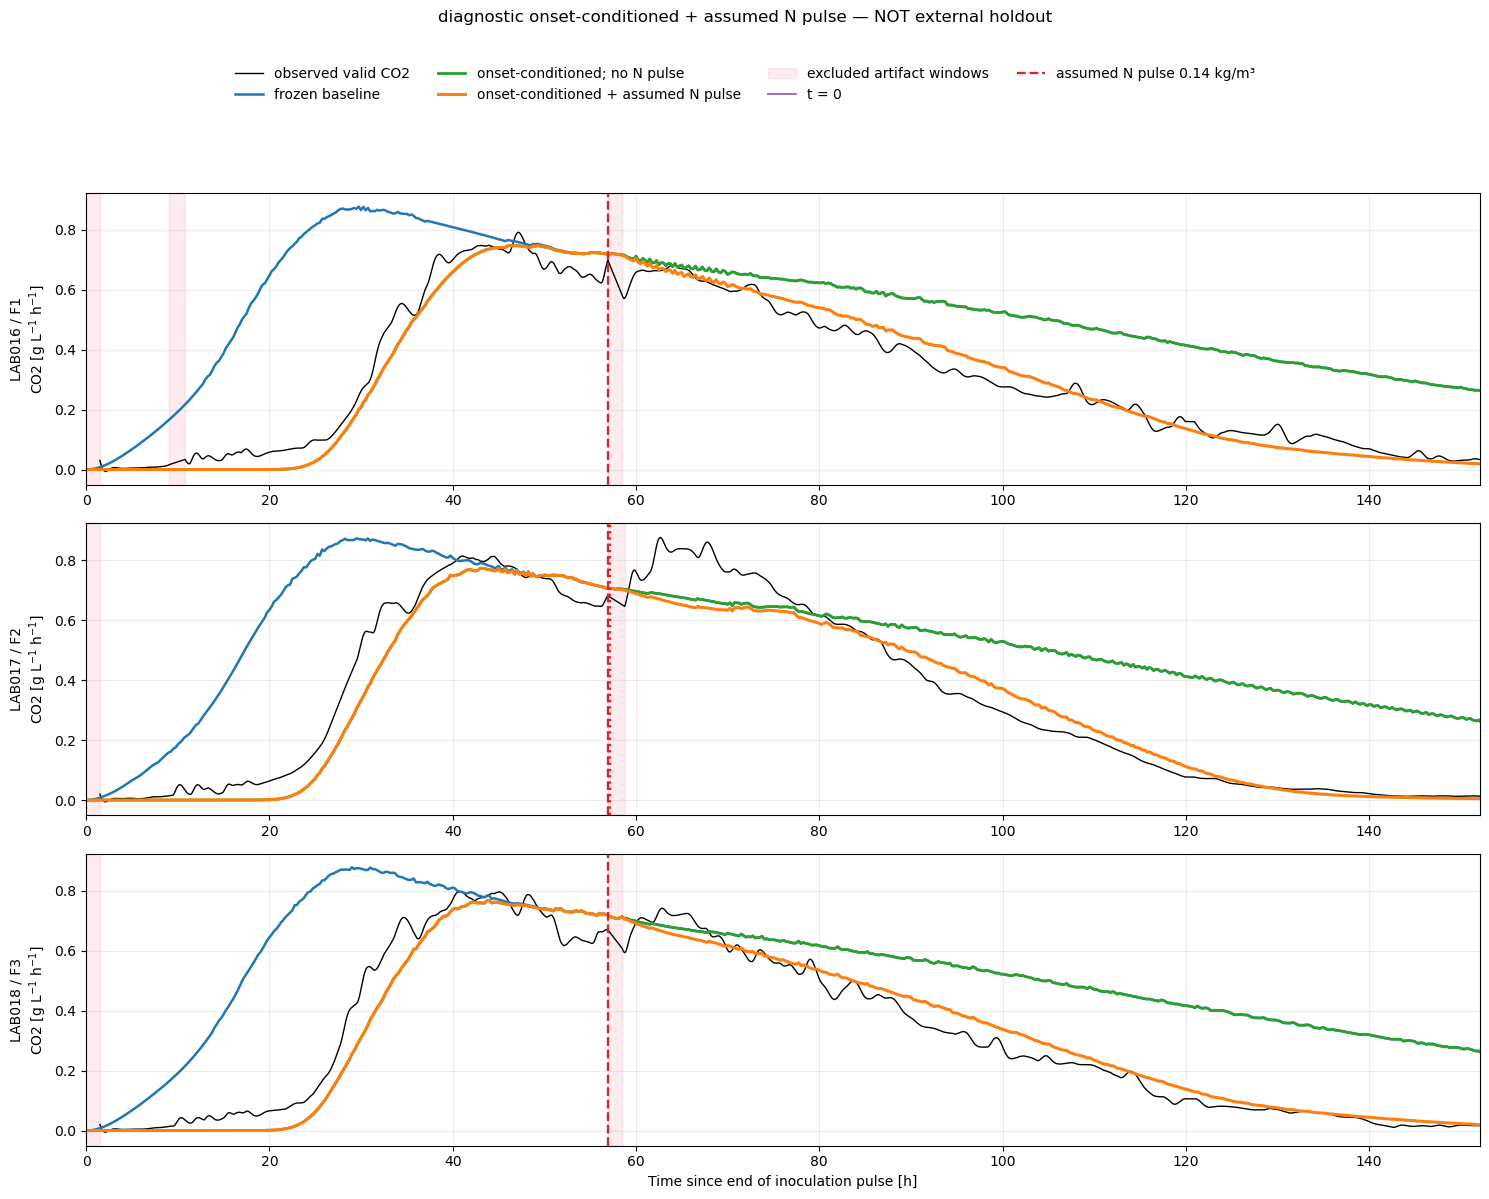

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=False, sharey=True)
for ax, lab in zip(axes, LABS):
    co2 = signals[lab]['co2_filt']
    baseline = predictions[(GATE_SCENARIO, lab)]
    conditioned = gate_predictions[lab]
    with_pulse = npulse_predictions[(NPULSE_PRIMARY_VARIANT, lab)]
    record = co2['time_h'].ge(0)
    valid = record & co2['co2_valid_for_fitting'] & np.isfinite(co2['CO2_obs_g_L_h'])
    x_max = float(co2.loc[record, 'time_h'].max())

    ax.plot(co2.loc[valid, 'time_h'], co2.loc[valid, 'CO2_obs_g_L_h'], color='black', lw=1.0, label='observed valid CO2')
    ax.plot(baseline['time_h'], baseline['CO2_pred_g_L_h'], color='tab:blue', lw=1.8, label='frozen baseline')
    ax.plot(conditioned['time_h'], conditioned['CO2_activation_conditioned_g_L_h'], color='tab:green', lw=2.0, label='onset-conditioned; no N pulse')
    ax.plot(with_pulse['time_h'], with_pulse['CO2_assumed_N_pulse_g_L_h'], color='tab:orange', lw=2.2, label='onset-conditioned + assumed N pulse')

    for number, (start, end) in enumerate(EXCLUSION_WINDOWS[lab]):
        start_h = (start - T0_BY_LAB[lab]).total_seconds() / 3600.0
        end_h = (end - T0_BY_LAB[lab]).total_seconds() / 3600.0
        if end_h >= 0 and start_h <= x_max:
            ax.axvspan(max(0.0, start_h), min(x_max, end_h), color='crimson', alpha=0.08, label='excluded artifact windows' if number == 0 else None)
    ax.axvline(0.0, color='tab:purple', lw=1.3, label='t = 0')
    for number, (pulse_h, amount) in enumerate(npulse_schedules[lab]):
        ax.axvline(pulse_h, color='tab:red', ls='--' if number == 0 else ':', lw=1.7, label=f'assumed N pulse {amount:.2f} kg/m³' if number == 0 else f'second assumed N pulse {amount:.2f} kg/m³')
    ax.set_xlim(0.0, x_max)
    ax.set_ylabel(f"{lab} / {LABS[lab]['fermenter']}\nCO2 [g L$^{{-1}}$ h$^{{-1}}$]")
    ax.grid(alpha=0.22)
axes[-1].set_xlabel('Time since end of inoculation pulse [h]')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.958))
fig.suptitle(NPULSE_DIAGNOSTIC_LABEL, y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()


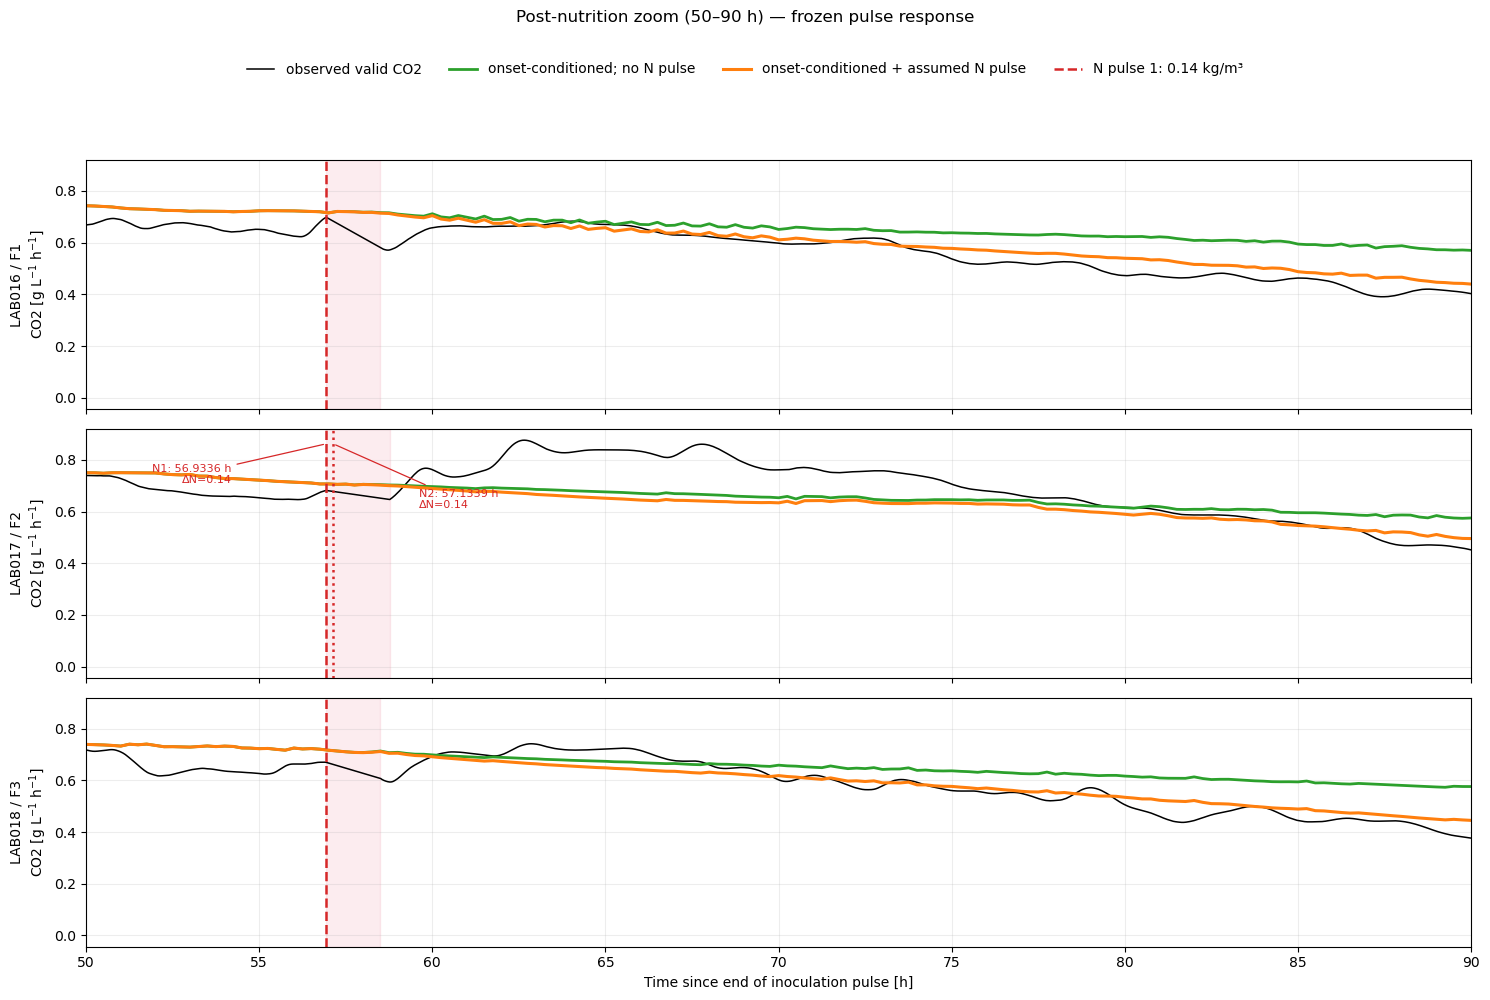

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True, sharey=True)
for ax, lab in zip(axes, LABS):
    co2 = signals[lab]['co2_filt']
    conditioned = gate_predictions[lab]
    with_pulse = npulse_predictions[(NPULSE_PRIMARY_VARIANT, lab)]
    valid = co2['time_h'].between(50.0, 90.0) & co2['co2_valid_for_fitting'] & np.isfinite(co2['CO2_obs_g_L_h'])
    ax.plot(co2.loc[valid, 'time_h'], co2.loc[valid, 'CO2_obs_g_L_h'], color='black', lw=1.1, label='observed valid CO2')
    ax.plot(conditioned['time_h'], conditioned['CO2_activation_conditioned_g_L_h'], color='tab:green', lw=2.0, label='onset-conditioned; no N pulse')
    ax.plot(with_pulse['time_h'], with_pulse['CO2_assumed_N_pulse_g_L_h'], color='tab:orange', lw=2.2, label='onset-conditioned + assumed N pulse')
    for start, end in EXCLUSION_WINDOWS[lab]:
        start_h = (start - T0_BY_LAB[lab]).total_seconds() / 3600.0
        end_h = (end - T0_BY_LAB[lab]).total_seconds() / 3600.0
        if end_h >= 50.0 and start_h <= 90.0:
            ax.axvspan(max(50.0, start_h), min(90.0, end_h), color='crimson', alpha=0.08)
    for number, (pulse_h, amount) in enumerate(npulse_schedules[lab]):
        ax.axvline(pulse_h, color='tab:red', ls='--' if number == 0 else ':', lw=1.8, label=f'N pulse {number + 1}: {amount:.2f} kg/m³')
        if lab == 'LAB017':
            ax.annotate(
                f'N{number + 1}: {pulse_h:.4f} h\nΔN={amount:.2f}',
                xy=(pulse_h, 0.94), xycoords=('data', 'axes fraction'),
                xytext=((54.2 if number == 0 else 59.6), (0.86 if number == 0 else 0.76)),
                textcoords=('data', 'axes fraction'), color='tab:red',
                ha='right' if number == 0 else 'left', va='top', fontsize=8,
                arrowprops={'arrowstyle': '-', 'color': 'tab:red', 'lw': 0.9},
            )
    ax.set_xlim(50.0, 90.0)
    ax.set_ylabel(f"{lab} / {LABS[lab]['fermenter']}\nCO2 [g L$^{{-1}}$ h$^{{-1}}$]")
    ax.grid(alpha=0.22)
axes[-1].set_xlabel('Time since end of inoculation pulse [h]')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.955))
fig.suptitle('Post-nutrition zoom (50–90 h) — frozen pulse response', y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.89))
plt.show()


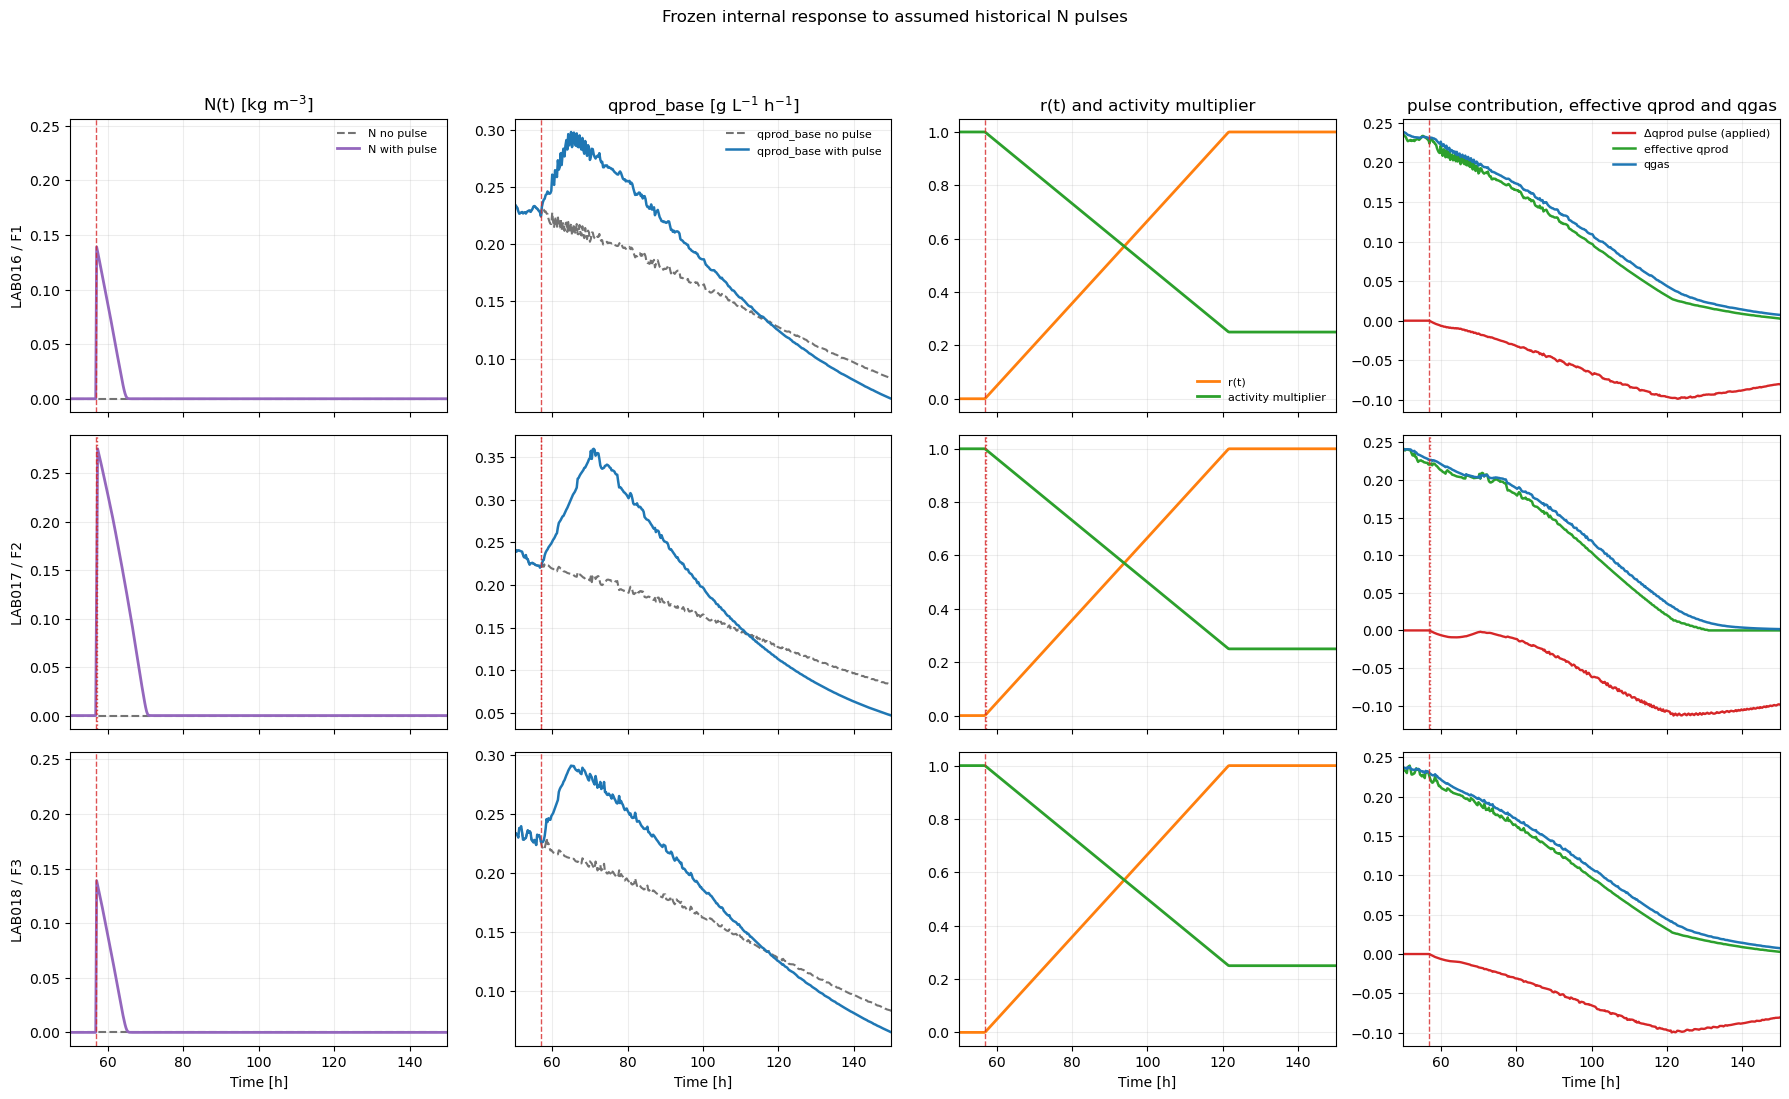

F1/F2/F3 frozen internal comparison:


,LAB,total_delta_N_kg_m3,time_h,N_kg_m3,delta_qprod_pulse_applied_g_L_h,effective_qprod_g_L_h,qgas_g_L_h
0,LAB016,0.14,57.00,0.138970,-0.000167,0.223934,0.229542
1,LAB016,0.14,57.25,0.134841,-0.000821,0.228700,0.231350
2,LAB016,0.14,60.00,0.086287,-0.006520,0.221241,0.226145
3,LAB016,0.14,80.00,0.000000,-0.031770,0.164929,0.173178
4,LAB016,0.14,100.00,0.000000,-0.067034,0.097268,0.109342
5,LAB016,0.14,120.00,0.000000,-0.096229,0.031298,0.043760
6,LAB016,0.14,150.00,0.000000,-0.080447,0.002538,0.007366
7,LAB017,0.28,57.00,0.138978,-0.000170,0.221205,0.226847
8,LAB017,0.28,57.25,0.275064,-0.000798,0.220520,0.226305
9,LAB017,0.28,60.00,0.227210,-0.006302,0.212978,0.221198


LAB017 two exact pulses versus one equivalent 0.28 kg/m3 pulse:


,variable,max_abs_two_minus_single,end_two_minus_single
0,N_kg_m3,0.139984,0.000000e+00
1,delta_qprod_pulse_applied_g_L_h,0.000006,1.700000e-06
2,effective_qprod_g_L_h,0.000006,0.000000e+00
3,qgas_g_L_h,0.000005,1.800000e-07


In [33]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11), sharex=True)
for row, lab in enumerate(LABS):
    profile = npulse_internal[(NPULSE_PRIMARY_VARIANT, lab)]
    no_pulse = predictions[(GATE_SCENARIO, lab)]
    window = profile['time_h'].between(50.0, min(150.0, float(profile['time_h'].max())))
    t = profile.loc[window, 'time_h']

    axes[row, 0].plot(no_pulse['time_h'], no_pulse['N'], color='0.45', ls='--', lw=1.5, label='N no pulse')
    axes[row, 0].plot(t, profile.loc[window, 'N_kg_m3'], color='tab:purple', lw=2.0, label='N with pulse')
    axes[row, 1].plot(t, profile.loc[window, 'qprod_base_no_pulse_g_L_h'], color='0.45', ls='--', lw=1.5, label='qprod_base no pulse')
    axes[row, 1].plot(t, profile.loc[window, 'qprod_base_with_pulse_g_L_h'], color='tab:blue', lw=1.8, label='qprod_base with pulse')
    axes[row, 2].plot(t, profile.loc[window, 'pulse_utilization_fraction_r'], color='tab:orange', lw=2.0, label='r(t)')
    axes[row, 2].plot(t, profile.loc[window, 'activity_multiplier'], color='tab:green', lw=2.0, label='activity multiplier')
    axes[row, 3].plot(t, profile.loc[window, 'delta_qprod_pulse_applied_g_L_h'], color='tab:red', lw=1.7, label='Δqprod pulse (applied)')
    axes[row, 3].plot(t, profile.loc[window, 'effective_qprod_g_L_h'], color='tab:green', lw=1.8, label='effective qprod')
    axes[row, 3].plot(t, profile.loc[window, 'qgas_g_L_h'], color='tab:blue', lw=1.8, label='qgas')
    for col in range(4):
        for number, (pulse_h, _) in enumerate(npulse_schedules[lab]):
            axes[row, col].axvline(pulse_h, color='tab:red', ls='--' if number == 0 else ':', lw=1.0, alpha=0.8)
        axes[row, col].set_xlim(50.0, min(150.0, float(profile['time_h'].max())))
        axes[row, col].grid(alpha=0.22)
    axes[row, 0].set_ylabel(f'{lab} / {LABS[lab]["fermenter"]}')
axes[0, 0].set_title('N(t) [kg m$^{-3}$]')
axes[0, 1].set_title('qprod_base [g L$^{-1}$ h$^{-1}$]')
axes[0, 2].set_title('r(t) and activity multiplier')
axes[0, 3].set_title('pulse contribution, effective qprod and qgas')
for col in range(4):
    axes[0, col].legend(fontsize=8, frameon=False)
    axes[-1, col].set_xlabel('Time [h]')
fig.suptitle('Frozen internal response to assumed historical N pulses', y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

npulse_dose_response_rows = []
for lab in LABS:
    profile = npulse_internal[(NPULSE_PRIMARY_VARIANT, lab)]
    for time_h in (57.0, 57.25, 60.0, 80.0, 100.0, 120.0, 150.0):
        if time_h > float(profile['time_h'].max()):
            continue
        npulse_dose_response_rows.append({
            'LAB': lab, 'total_delta_N_kg_m3': sum(amount for _, amount in npulse_schedules[lab]),
            'time_h': time_h,
            'N_kg_m3': float(np.interp(time_h, profile['time_h'], profile['N_kg_m3'])),
            'delta_qprod_pulse_applied_g_L_h': float(np.interp(time_h, profile['time_h'], profile['delta_qprod_pulse_applied_g_L_h'])),
            'effective_qprod_g_L_h': float(np.interp(time_h, profile['time_h'], profile['effective_qprod_g_L_h'])),
            'qgas_g_L_h': float(np.interp(time_h, profile['time_h'], profile['qgas_g_L_h'])),
        })
npulse_dose_response_table = pd.DataFrame(npulse_dose_response_rows)

f2_two = npulse_internal[(NPULSE_PRIMARY_VARIANT, 'LAB017')]
f2_single = npulse_internal[(NPULSE_SINGLE_EQUIVALENT_VARIANT, 'LAB017')]
npulse_f2_sensitivity_rows = []
for variable in ('N_kg_m3', 'delta_qprod_pulse_applied_g_L_h', 'effective_qprod_g_L_h', 'qgas_g_L_h'):
    difference = f2_two[variable].to_numpy(dtype=float) - f2_single[variable].to_numpy(dtype=float)
    npulse_f2_sensitivity_rows.append({
        'variable': variable,
        'max_abs_two_minus_single': float(np.max(np.abs(difference))),
        'end_two_minus_single': float(difference[-1]),
    })
npulse_f2_sensitivity_table = pd.DataFrame(npulse_f2_sensitivity_rows)
print('F1/F2/F3 frozen internal comparison:')
display(npulse_dose_response_table.round(6))
print('LAB017 two exact pulses versus one equivalent 0.28 kg/m3 pulse:')
display(npulse_f2_sensitivity_table.round(8))


### 13.1 Frozen upstream biomass check

The Oculyze samples near 8.9 h, 10.9 h and 56.2 h all precede the first assumed N pulse. They therefore test the unchanged upstream trajectory immediately before nutrition; no X0 or kinetic parameter is adjusted.


In [34]:
npulse_biomass_table = biomass_point_table[
    biomass_point_table['lab_id'].isin(LABS)
].copy().sort_values(['lab_id', 'time_h'])
npulse_biomass_table['X_onset_conditioned_no_pulse_kg_m3'] = [
    float(np.interp(
        row.time_h,
        predictions[(GATE_SCENARIO, row.lab_id)]['time_h'],
        predictions[(GATE_SCENARIO, row.lab_id)]['X'],
    ))
    for row in npulse_biomass_table.itertuples(index=False)
]
npulse_biomass_table['X_assumed_N_pulse_kg_m3'] = [
    float(np.interp(
        row.time_h,
        npulse_predictions[(NPULSE_PRIMARY_VARIANT, row.lab_id)]['time_h'],
        npulse_predictions[(NPULSE_PRIMARY_VARIANT, row.lab_id)]['X'],
    ))
    for row in npulse_biomass_table.itertuples(index=False)
]
npulse_biomass_table['pre_pulse_predictions_identical'] = np.isclose(
    npulse_biomass_table['X_onset_conditioned_no_pulse_kg_m3'],
    npulse_biomass_table['X_assumed_N_pulse_kg_m3'],
    rtol=0.0, atol=1e-10,
)
assert npulse_biomass_table['pre_pulse_predictions_identical'].all()
assert all(
    row.time_h < npulse_schedules[row.lab_id][0][0]
    for row in npulse_biomass_table.itertuples(index=False)
)
display(npulse_biomass_table[[
    'lab_id', 'sample_id', 'time_h', 'X_obs_kg_m3',
    'X_onset_conditioned_no_pulse_kg_m3', 'X_assumed_N_pulse_kg_m3',
    'pre_pulse_predictions_identical',
]].round(5))


,lab_id,sample_id,time_h,X_obs_kg_m3,X_onset_conditioned_no_pulse_kg_m3,X_assumed_N_pulse_kg_m3,pre_pulse_predictions_identical
27,LAB016,LAB016-1,8.93472,0.43215,0.67501,0.67501,True
28,LAB016,LAB016-2,10.93472,0.27192,0.73736,0.73736,True
29,LAB016,LAB016-8,56.18472,1.39875,1.36249,1.36249,True
30,LAB017,LAB017-1,8.93333,0.24067,0.66476,0.66476,True
31,LAB017,LAB017-2,10.93333,0.17170,0.72570,0.72570,True
32,LAB017,LAB017-8,56.18333,1.12215,1.36249,1.36249,True
33,LAB018,LAB018-1,8.93139,0.25796,0.67437,0.67437,True
34,LAB018,LAB018-2,10.93139,0.23153,0.73655,0.73655,True
35,LAB018,LAB018-8,56.18139,1.73975,1.36249,1.36249,True


In [35]:
npulse_post_metric_rows = []
for lab in LABS:
    scenario_profiles = {
        'onset-conditioned; no N pulse': gate_predictions[lab][
            ['time_h', 'CO2_activation_conditioned_g_L_h']
        ].rename(columns={'CO2_activation_conditioned_g_L_h': 'prediction'}),
        'onset-conditioned + assumed N pulse': npulse_predictions[
            (NPULSE_PRIMARY_VARIANT, lab)
        ][['time_h', 'CO2_assumed_N_pulse_g_L_h']].rename(
            columns={'CO2_assumed_N_pulse_g_L_h': 'prediction'}
        ),
    }
    if lab == 'LAB017':
        scenario_profiles['single equivalent 0.28 sensitivity'] = npulse_predictions[
            (NPULSE_SINGLE_EQUIVALENT_VARIANT, lab)
        ][['time_h', 'CO2_assumed_N_pulse_g_L_h']].rename(
            columns={'CO2_assumed_N_pulse_g_L_h': 'prediction'}
        )
    co2 = signals[lab]['co2_filt']
    time_h = co2['time_h'].to_numpy(dtype=float)
    observed_all = co2['CO2_obs_g_L_h'].to_numpy(dtype=float)
    valid = (
        (time_h >= npulse_schedules[lab][0][0])
        & co2['co2_valid_for_fitting'].to_numpy(dtype=bool)
        & np.isfinite(observed_all)
    )
    dt = np.diff(time_h)
    median_dt = float(np.median(dt[dt > 0]))
    for scenario_label, profile in scenario_profiles.items():
        predicted_all = np.interp(time_h, profile['time_h'], profile['prediction'])
        error = predicted_all[valid] - observed_all[valid]
        pair_ok = valid[:-1] & valid[1:] & (dt > 0) & (dt <= 1.5 * median_dt)
        row = {
            'LAB': lab, 'scenario': scenario_label,
            'post_start_h': npulse_schedules[lab][0][0],
            'n_valid': int(valid.sum()),
            'RMSE_post_pulse': float(np.sqrt(np.mean(error ** 2))),
            'bias_post_pulse': float(np.mean(error)),
            'AUC_obs_post_pulse': float(np.sum(0.5 * (observed_all[:-1] + observed_all[1:]) * dt * pair_ok)),
            'AUC_pred_post_pulse': float(np.sum(0.5 * (predicted_all[:-1] + predicted_all[1:]) * dt * pair_ok)),
        }
        valid_time = time_h[valid]
        valid_observed = observed_all[valid]
        for check_h in (80.0, 100.0, 120.0, 150.0):
            row[f'CO2_pred_{int(check_h)}h'] = float(np.interp(check_h, profile['time_h'], profile['prediction']))
            row[f'CO2_obs_{int(check_h)}h'] = float(np.interp(check_h, valid_time, valid_observed))
        npulse_post_metric_rows.append(row)
npulse_post_metrics_table = pd.DataFrame(npulse_post_metric_rows)
print('Separate post-pulse diagnostic metrics — never mixed with strict holdout metrics:')
display(npulse_post_metrics_table.round(5))

npulse_termination_rows = []
for lab in LABS:
    co2 = signals[lab]['co2_filt']
    valid = co2['time_h'].ge(0) & co2['co2_valid_for_fitting'] & np.isfinite(co2['CO2_obs_g_L_h'])
    obs_150 = float(np.interp(150.0, co2.loc[valid, 'time_h'], co2.loc[valid, 'CO2_obs_g_L_h']))
    without = gate_predictions[lab]
    with_pulse = npulse_predictions[(NPULSE_PRIMARY_VARIANT, lab)]
    no_150 = float(np.interp(150.0, without['time_h'], without['CO2_activation_conditioned_g_L_h']))
    pulse_150 = float(np.interp(150.0, with_pulse['time_h'], with_pulse['CO2_assumed_N_pulse_g_L_h']))
    npulse_termination_rows.append({
        'LAB': lab, 'obs_150h': obs_150, 'without_N_pulse_150h': no_150,
        'with_assumed_N_pulse_150h': pulse_150,
        'absolute_error_improvement': abs(no_150 - obs_150) - abs(pulse_150 - obs_150),
    })
npulse_termination_table = pd.DataFrame(npulse_termination_rows)
print('Termination audit at 150 h:')
display(npulse_termination_table.round(6))

lab = 'LAB017'
co2 = signals[lab]['co2_filt']
valid = co2['co2_valid_for_fitting'] & np.isfinite(co2['CO2_obs_g_L_h'])
first_pulse_h = npulse_schedules[lab][0][0]
last_pulse_h = npulse_schedules[lab][-1][0]
observed_pre = co2[valid & co2['time_h'].between(52.0, first_pulse_h)]
observed_post = co2[valid & co2['time_h'].between(last_pulse_h, 70.0)]
observed_min_row = observed_pre.loc[observed_pre['CO2_obs_g_L_h'].idxmin()]
observed_peak_row = observed_post.loc[observed_post['CO2_obs_g_L_h'].idxmax()]
npulse_reactivation_rows = [{
    'series': 'observed valid CO2',
    'reference_time_h': float(observed_min_row['time_h']),
    'reference_CO2': float(observed_min_row['CO2_obs_g_L_h']),
    'post_peak_time_h': float(observed_peak_row['time_h']),
    'post_peak_CO2': float(observed_peak_row['CO2_obs_g_L_h']),
}]
for label, profile in {
    'onset-conditioned; no N pulse': gate_predictions[lab][['time_h', 'CO2_activation_conditioned_g_L_h']].rename(columns={'CO2_activation_conditioned_g_L_h': 'prediction'}),
    'two assumed pulses 0.14 + 0.14': npulse_predictions[(NPULSE_PRIMARY_VARIANT, lab)][['time_h', 'CO2_assumed_N_pulse_g_L_h']].rename(columns={'CO2_assumed_N_pulse_g_L_h': 'prediction'}),
}.items():
    reference_value = float(np.interp(first_pulse_h, profile['time_h'], profile['prediction']))
    post = profile[profile['time_h'].between(last_pulse_h, 70.0)]
    peak = post.loc[post['prediction'].idxmax()]
    npulse_reactivation_rows.append({
        'series': label, 'reference_time_h': first_pulse_h,
        'reference_CO2': reference_value,
        'post_peak_time_h': float(peak['time_h']),
        'post_peak_CO2': float(peak['prediction']),
    })
npulse_lab017_reactivation_table = pd.DataFrame(npulse_reactivation_rows)
npulse_lab017_reactivation_table['increase_pct'] = 100.0 * (
    npulse_lab017_reactivation_table['post_peak_CO2']
    / npulse_lab017_reactivation_table['reference_CO2'] - 1.0
)
observed_increase = float(npulse_lab017_reactivation_table.iloc[0]['increase_pct'])
modeled_increase = float(npulse_lab017_reactivation_table.iloc[-1]['increase_pct'])
if modeled_increase <= 2.0:
    NPULSE_LAB017_REACTIVATION_VERDICT = 'solo atenuación; no genera una reactivación rápida'
elif modeled_increase < 0.5 * observed_increase:
    NPULSE_LAB017_REACTIVATION_VERDICT = 'la reactivación es demasiado pequeña'
elif float(npulse_lab017_reactivation_table.iloc[-1]['post_peak_time_h']) > 70.0:
    NPULSE_LAB017_REACTIVATION_VERDICT = 'la reactivación es demasiado tardía'
else:
    NPULSE_LAB017_REACTIVATION_VERDICT = 'la reactivación se representa aproximadamente a la escala observada'
print('LAB017 reactivation audit:', NPULSE_LAB017_REACTIVATION_VERDICT)
display(npulse_lab017_reactivation_table.round(5))


Separate post-pulse diagnostic metrics — never mixed with strict holdout metrics:


,LAB,scenario,post_start_h,n_valid,RMSE_post_pulse,bias_post_pulse,AUC_obs_post_pulse,AUC_pred_post_pulse,CO2_pred_80h,CO2_obs_80h,CO2_pred_100h,CO2_obs_100h,CO2_pred_120h,CO2_obs_120h,CO2_pred_150h,CO2_obs_150h
0,LAB016,onset-conditioned; no N pulse,56.93556,25561,0.20470,0.18643,26.30342,43.17923,0.62305,0.47242,0.52581,0.27582,0.41439,0.16042,0.27529,0.03092
1,LAB016,onset-conditioned + assumed N pulse,56.93556,25561,0.04046,0.01210,26.30342,27.25761,0.53958,0.47242,0.34068,0.27582,0.13634,0.16042,0.02295,0.03092
2,LAB017,onset-conditioned; no N pulse,56.93361,25468,0.23215,0.15721,28.29425,43.06264,0.61502,0.61559,0.52979,0.29403,0.41244,0.07699,0.27502,0.01299
3,LAB017,onset-conditioned + assumed N pulse,56.93361,25468,0.07449,-0.01122,28.29425,27.60380,0.58929,0.61559,0.37212,0.29403,0.11181,0.07699,0.00538,0.01299
4,LAB017,single equivalent 0.28 sensitivity,56.93361,25468,0.07449,-0.01123,28.29425,27.60334,0.58929,0.61559,0.37211,0.29403,0.11180,0.07699,0.00538,0.01299
5,LAB018,onset-conditioned; no N pulse,56.93167,25560,0.22672,0.19594,25.26452,43.16368,0.61660,0.50564,0.52192,0.27945,0.41715,0.10613,0.27421,0.01838
6,LAB018,onset-conditioned + assumed N pulse,56.93167,25560,0.04235,0.02155,25.26452,27.23504,0.53447,0.50564,0.33795,0.27945,0.13821,0.10613,0.02313,0.01838


Termination audit at 150 h:


,LAB,obs_150h,without_N_pulse_150h,with_assumed_N_pulse_150h,absolute_error_improvement
0,LAB016,0.030918,0.275288,0.022952,0.236405
1,LAB017,0.012988,0.275025,0.005381,0.254429
2,LAB018,0.018384,0.274213,0.023132,0.251081


LAB017 reactivation audit: solo atenuación; no genera una reactivación rápida


,series,reference_time_h,reference_CO2,post_peak_time_h,post_peak_CO2,increase_pct
0,observed valid CO2,56.11722,0.64613,62.64611,0.87610,35.59251
1,onset-conditioned; no N pulse,56.93361,0.70678,57.50000,0.70610,-0.09640
2,two assumed pulses 0.14 + 0.14,56.93361,0.70678,57.50000,0.70602,-0.10725


In [36]:
termination = npulse_termination_table.set_index('LAB')
post_metrics = npulse_post_metrics_table.set_index(['LAB', 'scenario'])
tail_ratio = termination['with_assumed_N_pulse_150h'] / termination['without_N_pulse_150h']
tail_answer = 'Sí' if bool((tail_ratio < 0.35).all()) else 'No en los tres LAB de forma uniforme'
f13_errors = {
    lab: abs(float(termination.loc[lab, 'with_assumed_N_pulse_150h'] - termination.loc[lab, 'obs_150h']))
    for lab in ('LAB016', 'LAB018')
}
f13_answer = 'sí, quedan próximos al observado' if max(f13_errors.values()) <= 0.05 else 'no quedan completamente alineados con el observado'
f2_no_rmse = float(post_metrics.loc[('LAB017', 'onset-conditioned; no N pulse'), 'RMSE_post_pulse'])
f2_pulse_rmse = float(post_metrics.loc[('LAB017', 'onset-conditioned + assumed N pulse'), 'RMSE_post_pulse'])
f2_effect = 'mejora' if f2_pulse_rmse < f2_no_rmse else 'empeora'
f1_profile = npulse_internal[(NPULSE_PRIMARY_VARIANT, 'LAB016')]
f2_profile = npulse_internal[(NPULSE_PRIMARY_VARIANT, 'LAB017')]
f3_profile = npulse_internal[(NPULSE_PRIMARY_VARIANT, 'LAB018')]
f1_peak_n = float(f1_profile.loc[f1_profile['time_h'] >= npulse_schedules['LAB016'][0][0], 'N_kg_m3'].max())
f2_peak_n = float(f2_profile.loc[f2_profile['time_h'] >= npulse_schedules['LAB017'][0][0], 'N_kg_m3'].max())
f3_peak_n = float(f3_profile.loc[f3_profile['time_h'] >= npulse_schedules['LAB018'][0][0], 'N_kg_m3'].max())
f2_split_vs_single_qgas = float(npulse_f2_sensitivity_table.loc[
    npulse_f2_sensitivity_table['variable'].eq('qgas_g_L_h'),
    'max_abs_two_minus_single',
].iloc[0])
onset_max_delay = float(gate_onset_table['error_activation_conditioned_h'].abs().max())

display(Markdown(f'''
### 13.2 Conclusiones del forward con dosis presumida

1. **¿El pulso N elimina la cola larga?** {tail_answer}: a 150 h la razón con/sin pulso es {tail_ratio.min():.2f}–{tail_ratio.max():.2f} según LAB.
2. **¿F1/F3 con 0.14 kg/m³ terminan razonablemente?** {f13_answer}. Los errores absolutos a 150 h son LAB016={f13_errors['LAB016']:.3f} y LAB018={f13_errors['LAB018']:.3f} g L⁻¹ h⁻¹.
3. **¿F2 con 0.28 kg/m³ se comporta distinto?** La implementación sí respeta la dosis: el máximo transitorio de N es LAB016={f1_peak_n:.3f}, LAB017={f2_peak_n:.3f} y LAB018={f3_peak_n:.3f} kg/m³. Sin embargo, separar F2 en dos saltos o concentrarlo en uno equivalente cambia `qgas` como máximo {f2_split_vs_single_qgas:.2e} g L⁻¹ h⁻¹; para esta capa congelada ambas representaciones son prácticamente indistinguibles.
4. **¿La dosis doble mejora F2?** {f2_effect.capitalize()} la comparación post-pulso: RMSE {f2_no_rmse:.3f} → {f2_pulse_rmse:.3f} g L⁻¹ h⁻¹ frente al escenario sin pulso. La diferencia entre dos saltos exactos y un salto equivalente se reporta aparte y no se ajusta.
5. **¿Reproduce la reactivación rápida de LAB017?** {NPULSE_LAB017_REACTIVATION_VERDICT.capitalize()}.
6. **¿O corrige principalmente la terminación/cola?** La respuesta congelada actúa principalmente sobre la caída y la cola; no se modificó `pulse_t_rise_h={co2_parameters_frozen['pulse_t_rise_h']:.3f} h` ni `pulse_activity_gain={co2_parameters_frozen['pulse_activity_gain']:.3f}` para forzar el bump.
7. **Discrepancias restantes.** El onset mantiene exactamente el diagnóstico anterior (máximo retraso absoluto {onset_max_delay:.2f} h). Tras declarar el pulso, permanecen discrepancias en la rapidez y amplitud de la respuesta post-nutrición, especialmente en LAB017.
8. **Revisión futura indicada.** La parte restante apunta a revisar estructuralmente la representación temporal de utilización/actividad del pulso y, solo después de confirmar las dosis, evaluar una recalibración separada. Nada de eso se realiza aquí.

*La dosis sigue “reported by operator with ~90% confidence, pending final confirmation”; por ello esta prueba continúa siendo diagnóstica y no un holdout definitivo.*
'''))



### 13.2 Conclusiones del forward con dosis presumida

1. **¿El pulso N elimina la cola larga?** Sí: a 150 h la razón con/sin pulso es 0.02–0.08 según LAB.
2. **¿F1/F3 con 0.14 kg/m³ terminan razonablemente?** sí, quedan próximos al observado. Los errores absolutos a 150 h son LAB016=0.008 y LAB018=0.005 g L⁻¹ h⁻¹.
3. **¿F2 con 0.28 kg/m³ se comporta distinto?** La implementación sí respeta la dosis: el máximo transitorio de N es LAB016=0.139, LAB017=0.275 y LAB018=0.139 kg/m³. Sin embargo, separar F2 en dos saltos o concentrarlo en uno equivalente cambia `qgas` como máximo 5.47e-06 g L⁻¹ h⁻¹; para esta capa congelada ambas representaciones son prácticamente indistinguibles.
4. **¿La dosis doble mejora F2?** Mejora la comparación post-pulso: RMSE 0.232 → 0.074 g L⁻¹ h⁻¹ frente al escenario sin pulso. La diferencia entre dos saltos exactos y un salto equivalente se reporta aparte y no se ajusta.
5. **¿Reproduce la reactivación rápida de LAB017?** Solo atenuación; no genera una reactivación rápida.
6. **¿O corrige principalmente la terminación/cola?** La respuesta congelada actúa principalmente sobre la caída y la cola; no se modificó `pulse_t_rise_h=64.659 h` ni `pulse_activity_gain=0.250` para forzar el bump.
7. **Discrepancias restantes.** El onset mantiene exactamente el diagnóstico anterior (máximo retraso absoluto 3.13 h). Tras declarar el pulso, permanecen discrepancias en la rapidez y amplitud de la respuesta post-nutrición, especialmente en LAB017.
8. **Revisión futura indicada.** La parte restante apunta a revisar estructuralmente la representación temporal de utilización/actividad del pulso y, solo después de confirmar las dosis, evaluar una recalibración separada. Nada de eso se realiza aquí.

*La dosis sigue “reported by operator with ~90% confidence, pending final confirmation”; por ello esta prueba continúa siendo diagnóstica y no un holdout definitivo.*


In [37]:
pd.testing.assert_frame_equal(co2_metrics, NPULSE_STRICT_METRICS_SNAPSHOT)
pd.testing.assert_frame_equal(diagnostic_metrics_table, NPULSE_TIME_SHIFT_SNAPSHOT)
assert theta_frozen == NPULSE_THETA_SNAPSHOT
assert co2_parameters_frozen == NPULSE_CO2_PARAMETER_SNAPSHOT
assert sha256(THETA_PATH) == HASHES_BEFORE[str(THETA_PATH.relative_to(ROOT))]
assert sha256(CO2_PARAMETER_PATH) == HASHES_BEFORE[str(CO2_PARAMETER_PATH.relative_to(ROOT))]
assert {str(path.relative_to(ROOT)): sha256(path) for path in protected_paths} == HASHES_BEFORE
for lab in LABS:
    pd.testing.assert_frame_equal(gate_predictions[lab], NPULSE_GATE_PREDICTION_SNAPSHOT[lab])
    assert scenario_batches[GATE_SCENARIO][lab].pulses['N'] == tuple()
    pulse_batch = npulse_batches[(NPULSE_PRIMARY_VARIANT, lab)]
    assert pulse_batch.pulses['N'] == npulse_schedules[lab]
    pulse_prediction = npulse_predictions[(NPULSE_PRIMARY_VARIANT, lab)]
    no_pulse_prediction = predictions[(GATE_SCENARIO, lab)]
    pre = pulse_prediction['time_h'] < npulse_schedules[lab][0][0]
    for state in UPSTREAM_STATES:
        assert np.allclose(
            pulse_prediction.loc[pre, state], no_pulse_prediction.loc[pre, state],
            rtol=1e-9, atol=1e-10,
        )
assert np.allclose(
    npulse_jump_table['requested_delta_N_kg_m3'],
    npulse_jump_table['realized_N_jump_kg_m3'],
    rtol=0.0, atol=1e-12,
)
assert len(npulse_schedules['LAB017']) == 2
assert np.isclose(sum(amount for _, amount in npulse_schedules['LAB017']), 0.28)
assert HASHES_AFTER == HASHES_BEFORE
print('ASSUMED HISTORICAL N-PULSE DIAGNOSTIC VALIDATION PASSED')
print('- strict holdout, time-shift and onset-conditioned diagnostics unchanged')
print('- exact base.simulate N jumps verified at every ledger event')
print('- LAB017 evaluated as two 0.14 pulses plus one 0.28 sensitivity case')
print('- optimizer/fitting calls added: 0')
print('- theta, CO2 parameters, activation, continuous_release and matrix_gain changes: 0')
print('- protected data/artifact hashes changed: 0')


ASSUMED HISTORICAL N-PULSE DIAGNOSTIC VALIDATION PASSED
- strict holdout, time-shift and onset-conditioned diagnostics unchanged
- exact base.simulate N jumps verified at every ledger event
- LAB017 evaluated as two 0.14 pulses plus one 0.28 sensitivity case
- optimizer/fitting calls added: 0
- theta, CO2 parameters, activation, continuous_release and matrix_gain changes: 0
- protected data/artifact hashes changed: 0


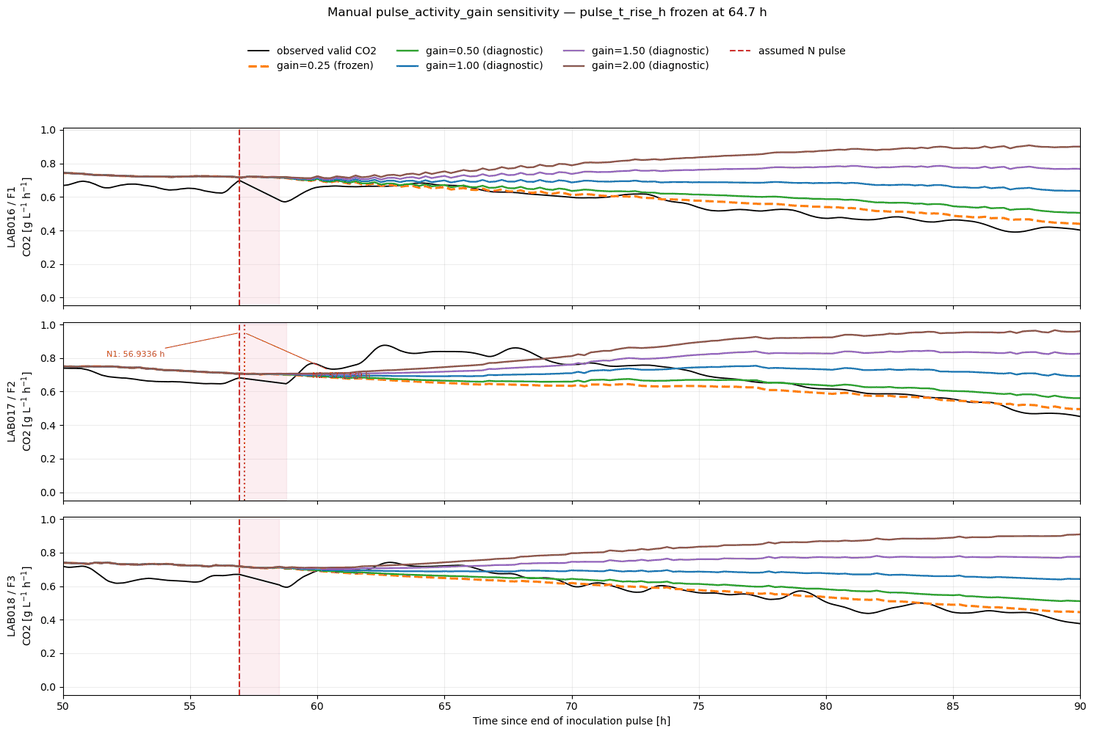

Manual forward grid only; no fitting or optimizer was used.


       LAB  gain  post_pulse_change_pct  predicted_post_pulse_peak_g_L_h  \
0   LAB016  0.25                0.62734                          0.72083   
1   LAB016  0.50                0.62734                          0.72083   
2   LAB016  1.00                0.62734                          0.72083   
3   LAB016  1.50                9.64054                          0.78539   
4   LAB016  2.00               26.71469                          0.90770   
5   LAB017  0.25               -0.10725                          0.70602   
6   LAB017  0.50               -0.10499                          0.70603   
7   LAB017  1.00                6.64591                          0.75375   
8   LAB017  1.50               19.38534                          0.84379   
9   LAB017  2.00               36.67708                          0.96600   
10  LAB018  0.25               -0.15037                          0.71675   
11  LAB018  0.50               -0.15037                          0.71675   
12  LAB018  

GAIN SENSITIVITY VALIDATION PASSED — frozen parameter dictionaries unchanged


In [38]:
PULSE_ACTIVITY_GAIN_SENSITIVITY = (0.25, 0.5, 1.0, 1.5, 2.0)
GAIN_SENSITIVITY_THETA_SNAPSHOT = dict(theta_frozen)
GAIN_SENSITIVITY_CO2_SNAPSHOT = dict(co2_parameters_frozen)
GAIN_SENSITIVITY_PRIMARY_SNAPSHOT = {
    lab: npulse_predictions[(NPULSE_PRIMARY_VARIANT, lab)].copy(deep=True)
    for lab in LABS
}
assert np.isclose(co2_parameters_frozen['pulse_activity_gain'], 0.25)
assert np.isclose(co2_parameters_frozen['pulse_t_rise_h'], 64.7, atol=0.1)

gain_sensitivity_predictions = {}
gain_sensitivity_rows = []
observed_bump_rows = []
for lab in LABS:
    co2 = signals[lab]['co2_filt']
    time_obs = co2['time_h'].to_numpy(dtype=float)
    observed = co2['CO2_obs_g_L_h'].to_numpy(dtype=float)
    valid_obs = co2['co2_valid_for_fitting'].to_numpy(dtype=bool) & np.isfinite(observed)
    first_pulse_h = npulse_schedules[lab][0][0]
    last_pulse_h = npulse_schedules[lab][-1][0]
    observed_pre = valid_obs & (time_obs >= 52.0) & (time_obs <= first_pulse_h)
    observed_post = valid_obs & (time_obs >= last_pulse_h) & (time_obs <= 90.0)
    pre_indices = np.flatnonzero(observed_pre)
    post_indices = np.flatnonzero(observed_post)
    reference_index = int(pre_indices[np.argmin(observed[pre_indices])])
    peak_index = int(post_indices[np.argmax(observed[post_indices])])
    observed_bump_pct = 100.0 * (observed[peak_index] / observed[reference_index] - 1.0)
    observed_bump_rows.append({
        'LAB': lab, 'reference_time_h': time_obs[reference_index],
        'post_peak_time_h': time_obs[peak_index],
        'observed_bump_pct': observed_bump_pct,
    })

    cache = npulse_caches[(NPULSE_PRIMARY_VARIANT, lab)]
    metric_support = valid_obs & (time_obs >= 50.0) & (time_obs <= 90.0)
    for gain in PULSE_ACTIVITY_GAIN_SENSITIVITY:
        local_forward_kwargs = dict(GATE_FORWARD_KWARGS)
        local_forward_kwargs['pulse_activity_gain'] = float(gain)
        qgas, _, _, _ = co2_cross.raw_qgas_grid_prediction(
            cache, **local_forward_kwargs,
        )
        prediction = co2_parameters_frozen['matrix_gain'] * qgas
        gain_sensitivity_predictions[(lab, gain)] = prediction
        predicted_at_observations = np.interp(time_obs, cache.time_h, prediction)
        error = predicted_at_observations[metric_support] - observed[metric_support]
        post_grid = (cache.time_h >= last_pulse_h) & (cache.time_h <= 90.0)
        post_positions = np.flatnonzero(post_grid)
        predicted_peak_index = int(post_positions[np.argmax(prediction[post_positions])])
        reference_prediction = float(np.interp(first_pulse_h, cache.time_h, prediction))
        predicted_bump_pct = 100.0 * (
            float(prediction[predicted_peak_index]) / reference_prediction - 1.0
        )
        gain_sensitivity_rows.append({
            'LAB': lab, 'pulse_activity_gain_diagnostic': gain,
            'pulse_t_rise_h_frozen': co2_parameters_frozen['pulse_t_rise_h'],
            'observed_bump_pct': observed_bump_pct,
            'predicted_bump_pct': predicted_bump_pct,
            'bump_error_percentage_points': predicted_bump_pct - observed_bump_pct,
            'predicted_post_peak_g_L_h': float(prediction[predicted_peak_index]),
            'predicted_post_peak_time_h': float(cache.time_h[predicted_peak_index]),
            'observed_post_peak_time_h': float(time_obs[peak_index]),
            'RMSE_50_90h': float(np.sqrt(np.mean(error ** 2))),
        })

gain_sensitivity_table = pd.DataFrame(gain_sensitivity_rows)
gain_sensitivity_display = gain_sensitivity_table[[
    'LAB', 'pulse_activity_gain_diagnostic', 'predicted_bump_pct',
    'predicted_post_peak_g_L_h', 'predicted_post_peak_time_h', 'RMSE_50_90h',
]].rename(columns={
    'pulse_activity_gain_diagnostic': 'gain',
    'predicted_bump_pct': 'post_pulse_change_pct',
    'predicted_post_peak_g_L_h': 'predicted_post_pulse_peak_g_L_h',
    'predicted_post_peak_time_h': 'predicted_post_pulse_peak_time_h',
})
observed_bump_table = pd.DataFrame(observed_bump_rows)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True, sharey=True)
gain_colors = {
    0.25: 'tab:orange', 0.5: 'tab:green', 1.0: 'tab:blue',
    1.5: 'tab:purple', 2.0: 'tab:brown',
}
for ax, lab in zip(axes, LABS):
    co2 = signals[lab]['co2_filt']
    valid = (
        co2['time_h'].between(50.0, 90.0)
        & co2['co2_valid_for_fitting']
        & np.isfinite(co2['CO2_obs_g_L_h'])
    )
    ax.plot(
        co2.loc[valid, 'time_h'], co2.loc[valid, 'CO2_obs_g_L_h'],
        color='black', lw=1.3, label='observed valid CO2',
    )
    cache = npulse_caches[(NPULSE_PRIMARY_VARIANT, lab)]
    for gain in PULSE_ACTIVITY_GAIN_SENSITIVITY:
        ax.plot(
            cache.time_h, gain_sensitivity_predictions[(lab, gain)],
            color=gain_colors[gain], lw=2.2 if gain == 0.25 else 1.7,
            ls='--' if gain == 0.25 else '-',
            label=f'gain={gain:.2f}' + (' (frozen)' if gain == 0.25 else ' (diagnostic)'),
        )
    for start, end in EXCLUSION_WINDOWS[lab]:
        start_h = (start - T0_BY_LAB[lab]).total_seconds() / 3600.0
        end_h = (end - T0_BY_LAB[lab]).total_seconds() / 3600.0
        if end_h >= 50.0 and start_h <= 90.0:
            ax.axvspan(max(50.0, start_h), min(90.0, end_h), color='crimson', alpha=0.07)
    for number, (pulse_h, amount) in enumerate(npulse_schedules[lab]):
        ax.axvline(
            pulse_h, color='tab:red', ls='--' if number == 0 else ':', lw=1.5,
            label='assumed N pulse' if number == 0 else 'second assumed N pulse',
        )
        if lab == 'LAB017':
            ax.annotate(
                f'N{number + 1}: {pulse_h:.4f} h',
                xy=(pulse_h, 0.94), xycoords=('data', 'axes fraction'),
                xytext=((54.0 if number == 0 else 59.8), (0.84 if number == 0 else 0.72)),
                textcoords=('data', 'axes fraction'), color='tab:red',
                ha='right' if number == 0 else 'left', va='top', fontsize=8,
                arrowprops={'arrowstyle': '-', 'color': 'tab:red', 'lw': 0.8},
            )
    ax.set_xlim(50.0, 90.0)
    ax.set_ylabel(f"{lab} / {LABS[lab]['fermenter']}\nCO2 [g L$^{{-1}}$ h$^{{-1}}$]")
    ax.grid(alpha=0.22)
axes[-1].set_xlabel('Time since end of inoculation pulse [h]')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.955))
fig.suptitle('Manual pulse_activity_gain sensitivity — pulse_t_rise_h frozen at 64.7 h', y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

print('Manual forward grid only; no fitting or optimizer was used.')
display(gain_sensitivity_display.round(5))
assert theta_frozen == GAIN_SENSITIVITY_THETA_SNAPSHOT
assert co2_parameters_frozen == GAIN_SENSITIVITY_CO2_SNAPSHOT
for lab in LABS:
    pd.testing.assert_frame_equal(
        npulse_predictions[(NPULSE_PRIMARY_VARIANT, lab)],
        GAIN_SENSITIVITY_PRIMARY_SNAPSHOT[lab],
    )
print('GAIN SENSITIVITY VALIDATION PASSED — frozen parameter dictionaries unchanged')


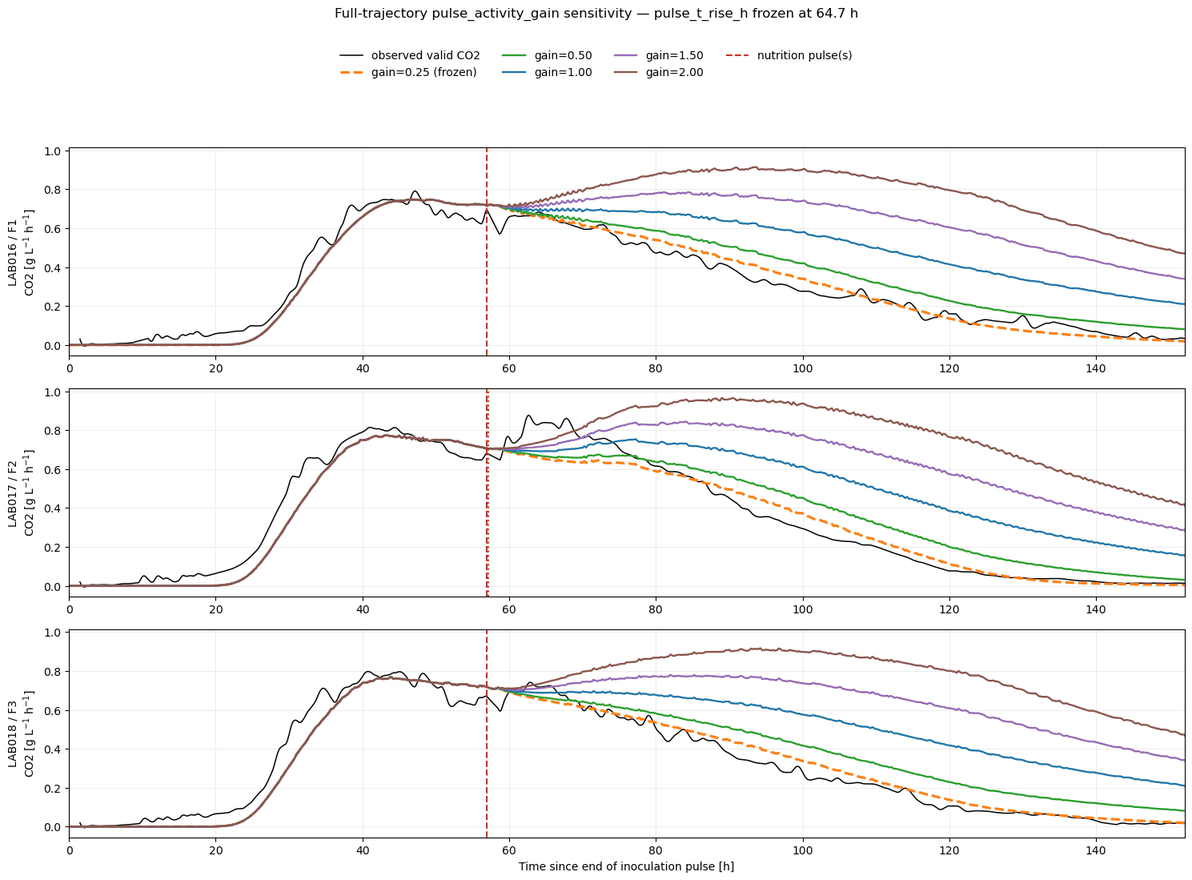

       LAB  gain  RMSE 50-90 h  qCO2 @120 h  qCO2 @150 h  observed @150 h
0   LAB016  0.25       0.04831      0.13634      0.02295          0.03092
1   LAB016  0.50       0.07284      0.22732      0.08800          0.03092
2   LAB016  1.00       0.13568      0.41465      0.22260          0.03092
3   LAB016  1.50       0.20294      0.60456      0.35755          0.03092
4   LAB016  2.00       0.27154      0.79550      0.49239          0.03092
5   LAB017  0.25       0.10056      0.11181      0.00538          0.01299
6   LAB017  0.50       0.09461      0.20038      0.03642          0.01299
7   LAB017  1.00       0.11769      0.38547      0.16760          0.01299
8   LAB017  1.50       0.16883      0.57436      0.30202          0.01299
9   LAB017  2.00       0.23024      0.76481      0.43679          0.01299
10  LAB018  0.25       0.05286      0.13821      0.02313          0.01838
11  LAB018  0.50       0.06947      0.22983      0.08781          0.01838
12  LAB018  1.00       0.12636      0.

FULL GAIN TRAJECTORY VALIDATION PASSED — existing sensitivity curves reused


In [39]:
GAIN_FULL_TRAJECTORY_TITLE = (
    'Full-trajectory pulse_activity_gain sensitivity — '
    'pulse_t_rise_h frozen at 64.7 h'
)
GAIN_FULL_THETA_SNAPSHOT = dict(theta_frozen)
GAIN_FULL_CO2_SNAPSHOT = dict(co2_parameters_frozen)
GAIN_FULL_PREDICTION_KEYS = set(gain_sensitivity_predictions)

def supported_interpolation(target_h, time_h, values, valid=None):
    time_h = np.asarray(time_h, dtype=float)
    values = np.asarray(values, dtype=float)
    support = np.isfinite(time_h) & np.isfinite(values)
    if valid is not None:
        support &= np.asarray(valid, dtype=bool)
    x = time_h[support]
    y = values[support]
    if x.size == 0 or target_h < x.min() or target_h > x.max():
        return np.nan
    return float(np.interp(target_h, x, y))

gain_tail_rows = []
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=False, sharey=True)
gain_colors = {
    0.25: 'tab:orange', 0.50: 'tab:green', 1.00: 'tab:blue',
    1.50: 'tab:purple', 2.00: 'tab:brown',
}
for ax, lab in zip(axes, LABS):
    co2 = signals[lab]['co2_filt']
    time_obs = co2['time_h'].to_numpy(dtype=float)
    observed = co2['CO2_obs_g_L_h'].to_numpy(dtype=float)
    valid_obs = (
        co2['co2_valid_for_fitting'].to_numpy(dtype=bool)
        & np.isfinite(observed) & (time_obs >= 0.0)
    )
    cache = npulse_caches[(NPULSE_PRIMARY_VARIANT, lab)]
    x_max = min(
        float(np.nanmax(time_obs[time_obs >= 0.0])),
        float(np.nanmax(cache.time_h)),
    )
    ax.plot(
        time_obs[valid_obs], observed[valid_obs],
        color='black', lw=1.1, label='observed valid CO2',
    )
    observed_150 = supported_interpolation(150.0, time_obs, observed, valid_obs)
    for gain in PULSE_ACTIVITY_GAIN_SENSITIVITY:
        prediction = gain_sensitivity_predictions[(lab, gain)]
        ax.plot(
            cache.time_h, prediction, color=gain_colors[gain],
            lw=2.2 if gain == 0.25 else 1.7,
            ls='--' if gain == 0.25 else '-',
            label=f'gain={gain:.2f}' + (' (frozen)' if gain == 0.25 else ''),
        )
        rmse = gain_sensitivity_table.loc[
            gain_sensitivity_table['LAB'].eq(lab)
            & gain_sensitivity_table['pulse_activity_gain_diagnostic'].eq(gain),
            'RMSE_50_90h',
        ].iloc[0]
        gain_tail_rows.append({
            'LAB': lab,
            'gain': gain,
            'RMSE 50-90 h': float(rmse),
            'qCO2 @120 h': supported_interpolation(120.0, cache.time_h, prediction),
            'qCO2 @150 h': supported_interpolation(150.0, cache.time_h, prediction),
            'observed @150 h': observed_150,
        })
    for pulse_number, (pulse_h, _) in enumerate(npulse_schedules[lab]):
        ax.axvline(
            pulse_h, color='tab:red',
            ls='--' if pulse_number == 0 else ':', lw=1.5,
            label='nutrition pulse(s)' if pulse_number == 0 else None,
        )
    ax.set_xlim(0.0, x_max)
    ax.set_ylabel(f"{lab} / {LABS[lab]['fermenter']}\nCO2 [g L$^{{-1}}$ h$^{{-1}}$]")
    ax.grid(alpha=0.22)
axes[-1].set_xlabel('Time since end of inoculation pulse [h]')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.958))
fig.suptitle(GAIN_FULL_TRAJECTORY_TITLE, y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

gain_tail_table = pd.DataFrame(gain_tail_rows)
display(gain_tail_table.round(5))
assert theta_frozen == GAIN_FULL_THETA_SNAPSHOT
assert co2_parameters_frozen == GAIN_FULL_CO2_SNAPSHOT
assert set(gain_sensitivity_predictions) == GAIN_FULL_PREDICTION_KEYS
print('FULL GAIN TRAJECTORY VALIDATION PASSED — existing sensitivity curves reused')


1. **¿Aumentar `pulse_activity_gain` genera finalmente una reactivación visible?** Sí. Con `gain = 1.50–2.00` aparece una reactivación visible en los tres LAB; con `gain = 1.00` solo aparece un bump pequeño en LAB017.

2. **¿Qué gain se aproxima más al bump observado de LAB017 (~35%)?** Dentro de la grilla manual, `gain = 2.00`: predice 36.68% frente a 35.59% observado. Sin embargo, el peak queda en 89.00 h frente a 62.65 h observado y el RMSE aumenta de 0.10056 (baseline) a 0.23024.

3. **¿Ese mismo gain empeora LAB016 o LAB018?** Sí. En LAB016 predice 26.71% frente a 9.65% observado y el RMSE sube de 0.04831 a 0.27154; en LAB018 predice 26.62% frente a 20.17% y el RMSE sube de 0.05286 a 0.25893.

4. **¿Incluso con gain alto la respuesta sigue demasiado lenta por `pulse_t_rise_h = 64.7 h`?** Sí. Con `gain = 2.00`, los peaks predichos quedan en 88.00, 89.00 y 90.00 h, mientras los observados ocurren en 64.01, 62.65 y 62.84 h. El gain recupera amplitud, pero no corrige el retraso impuesto por `pulse_t_rise_h = 64.65871 h`.


## 14. Diagnostic transient post-nutrition activity bump

This is a manual structural sensitivity, not a calibration or fit. The frozen historical architecture remains unchanged: theta, onset-conditioned chemical activation, matrix gain, continuous release, pulse times/doses, pulse activity gain = 0.25, pulse rise time = 64.7 h, and all remaining CO2 parameters. A normalized, causal rise-decay multiplier is applied locally to historical effective qprod before the dissolved-CO2 pool.


In [40]:
TRANSIENT_A_GRID = (0.10, 0.20, 0.30)
TRANSIENT_TAU_RISE_GRID_H = (1.0, 2.0, 4.0)
TRANSIENT_TAU_DECAY_GRID_H = (4.0, 8.0, 12.0)
TRANSIENT_SCENARIOS = tuple(
    (A, tau_rise_h, tau_decay_h)
    for A in TRANSIENT_A_GRID
    for tau_rise_h in TRANSIENT_TAU_RISE_GRID_H
    for tau_decay_h in TRANSIENT_TAU_DECAY_GRID_H
)
TRANSIENT_ZOOM_REPRESENTATIVES = (
    (0.10, 1.0, 4.0),
    (0.20, 2.0, 8.0),
    (0.30, 1.0, 8.0),
    (0.30, 4.0, 12.0),
)
TRANSIENT_FULL_REPRESENTATIVES = (
    (0.20, 2.0, 8.0),
    (0.30, 1.0, 8.0),
    (0.30, 4.0, 12.0),
)
TRANSIENT_THETA_SNAPSHOT = dict(theta_frozen)
TRANSIENT_CO2_SNAPSHOT = dict(co2_parameters_frozen)
TRANSIENT_PRIMARY_SNAPSHOT = {
    lab: npulse_predictions[(NPULSE_PRIMARY_VARIANT, lab)].copy(deep=True)
    for lab in LABS
}
assert len(TRANSIENT_SCENARIOS) == 27
assert np.isclose(co2_parameters_frozen['pulse_activity_gain'], 0.25)
assert np.isclose(co2_parameters_frozen['pulse_t_rise_h'], 64.7, atol=0.1)
assert GATE_FORWARD_KWARGS['continuous_release'] is True
assert {
    lab: tuple(amount for _, amount in schedule)
    for lab, schedule in npulse_schedules.items()
} == {
    'LAB016': (0.14,),
    'LAB017': (0.14, 0.14),
    'LAB018': (0.14,),
}


def transient_normalized_rise_decay(time_h, pulse_h, tau_rise_h, tau_decay_h):
    elapsed = np.asarray(time_h, dtype=float) - float(pulse_h)
    raw = np.zeros_like(elapsed)
    causal = elapsed >= 0.0
    dt = elapsed[causal]
    raw[causal] = (
        (1.0 - np.exp(-dt / float(tau_rise_h)))
        * np.exp(-dt / float(tau_decay_h))
    )
    peak = float(np.max(raw))
    if peak <= 0.0:
        raise RuntimeError('Transient rise-decay profile has no positive support')
    return raw / peak


def transient_pool_qgas(cache, qprod_effective):
    time_h = np.asarray(cache.time_h, dtype=float)
    qprod_effective = np.asarray(qprod_effective, dtype=float)
    if qprod_effective.shape != time_h.shape:
        raise ValueError('qprod/time grid mismatch')
    k_release_h = float(GATE_FORWARD_KWARGS['k_release_h'])
    csat = float(GATE_FORWARD_KWARGS['sat_scale']) * cache.csat_base_g_l
    dissolved = 0.0
    qgas = np.zeros(len(time_h), dtype=float)
    for idx in range(1, len(time_h)):
        dt = max(float(time_h[idx] - time_h[idx - 1]), 1e-9)
        available = dissolved / dt + max(float(qprod_effective[idx - 1]), 0.0)
        dissolved_fraction = dissolved / max(dissolved + float(csat[idx]), 1e-12)
        release_fraction = co2_cross.CO2_CONTINUOUS_RELEASE_FLOOR + (
            1.0 - co2_cross.CO2_CONTINUOUS_RELEASE_FLOOR
        ) * dissolved_fraction
        potential_release = max(k_release_h, 1e-9) * dissolved * release_fraction
        qgas[idx] = min(potential_release, available)
        dissolved = max(
            dissolved + dt * (max(float(qprod_effective[idx - 1]), 0.0) - qgas[idx]),
            0.0,
        )
    return qgas


def transient_supported_value(target_h, time_h, values, valid=None):
    time_h = np.asarray(time_h, dtype=float)
    values = np.asarray(values, dtype=float)
    support = np.isfinite(time_h) & np.isfinite(values)
    if valid is not None:
        support &= np.asarray(valid, dtype=bool)
    x = time_h[support]
    y = values[support]
    if x.size == 0 or target_h < x.min() or target_h > x.max():
        return np.nan
    return float(np.interp(target_h, x, y))


def transient_shape_metrics(time_h, values, first_pulse_h, valid=None):
    time_h = np.asarray(time_h, dtype=float)
    values = np.asarray(values, dtype=float)
    support = np.isfinite(time_h) & np.isfinite(values)
    if valid is not None:
        support &= np.asarray(valid, dtype=bool)
    prepulse = support & (time_h >= first_pulse_h - 5.0) & (time_h <= first_pulse_h)
    postpulse = support & (time_h >= first_pulse_h) & (time_h <= first_pulse_h + 12.0)
    pre_positions = np.flatnonzero(prepulse)
    post_positions = np.flatnonzero(postpulse)
    if pre_positions.size == 0 or post_positions.size == 0:
        return {
            'minimum_prepulse_g_L_h': np.nan,
            'peak_postpulse_g_L_h': np.nan,
            'reactivation_pct': np.nan,
            'hours_to_postpulse_peak': np.nan,
        }
    minimum_index = int(pre_positions[np.argmin(values[pre_positions])])
    peak_index = int(post_positions[np.argmax(values[post_positions])])
    minimum = float(values[minimum_index])
    peak = float(values[peak_index])
    return {
        'minimum_prepulse_g_L_h': minimum,
        'peak_postpulse_g_L_h': peak,
        'reactivation_pct': 100.0 * (peak - minimum) / max(minimum, 1e-12),
        'hours_to_postpulse_peak': float(time_h[peak_index] - first_pulse_h),
    }


transient_historical_qprod = {}
transient_historical_predictions = {}
transient_bump_profiles = {}
transient_predictions = {}
transient_observed_rows = []
transient_metric_rows = []

for lab in LABS:
    cache = npulse_caches[(NPULSE_PRIMARY_VARIANT, lab)]
    historical_qprod, _, _ = co2_cross.effective_qprod_grid(
        cache,
        o2_qmax_mg_gdw_h=GATE_FORWARD_KWARGS['o2_qmax_mg_gdw_h'],
        o2_initial_scale=GATE_FORWARD_KWARGS['o2_initial_scale'],
        chemistry_aligned=GATE_FORWARD_KWARGS['chemistry_aligned'],
        nitrogen_boost_transition=GATE_FORWARD_KWARGS['nitrogen_boost_transition'],
        pulse_t_rise_h=GATE_FORWARD_KWARGS['pulse_t_rise_h'],
        pulse_activity_gain=GATE_FORWARD_KWARGS['pulse_activity_gain'],
        bounded_chemical_activation=GATE_FORWARD_KWARGS['bounded_chemical_activation'],
        chem_activation_start_fraction=GATE_FORWARD_KWARGS['chem_activation_start_fraction'],
        chem_activation_duration_fraction=GATE_FORWARD_KWARGS['chem_activation_duration_fraction'],
    )
    historical_qgas = transient_pool_qgas(cache, historical_qprod)
    historical_prediction = co2_parameters_frozen['matrix_gain'] * historical_qgas
    assert np.allclose(
        historical_prediction,
        gain_sensitivity_predictions[(lab, 0.25)],
        rtol=1e-11, atol=1e-12,
    )
    transient_historical_qprod[lab] = historical_qprod
    transient_historical_predictions[lab] = historical_prediction

    co2 = signals[lab]['co2_filt']
    time_obs = co2['time_h'].to_numpy(dtype=float)
    observed = co2['CO2_obs_g_L_h'].to_numpy(dtype=float)
    valid_obs = co2['co2_valid_for_fitting'].to_numpy(dtype=bool) & np.isfinite(observed)
    first_pulse_h = float(npulse_schedules[lab][0][0])
    observed_shape = transient_shape_metrics(
        time_obs, observed, first_pulse_h, valid=valid_obs,
    )
    transient_observed_rows.append({
        'LAB': lab,
        **observed_shape,
        'qCO2_120h_g_L_h': transient_supported_value(
            120.0, time_obs, observed, valid_obs,
        ),
        'qCO2_150h_g_L_h': transient_supported_value(
            150.0, time_obs, observed, valid_obs,
        ),
    })

    metric_support = valid_obs & (time_obs >= 50.0) & (time_obs <= 90.0)
    historical_at_obs = np.interp(time_obs, cache.time_h, historical_prediction)
    historical_shape = transient_shape_metrics(
        cache.time_h, historical_prediction, first_pulse_h,
    )
    transient_metric_rows.append({
        'LAB': lab,
        'scenario': 'historical gain=0.25; no transient',
        'A_base': 0.0,
        'tau_rise_h': np.nan,
        'tau_decay_h': np.nan,
        **historical_shape,
        'RMSE_50_90h': float(np.sqrt(np.mean(
            (historical_at_obs[metric_support] - observed[metric_support]) ** 2
        ))),
        'qCO2_120h_g_L_h': transient_supported_value(
            120.0, cache.time_h, historical_prediction,
        ),
        'qCO2_150h_g_L_h': transient_supported_value(
            150.0, cache.time_h, historical_prediction,
        ),
    })

    for A_base, tau_rise_h, tau_decay_h in TRANSIENT_SCENARIOS:
        bump = np.zeros_like(cache.time_h, dtype=float)
        for pulse_h, amount in npulse_schedules[lab]:
            bump += (
                float(amount) / 0.14
                * transient_normalized_rise_decay(
                    cache.time_h, pulse_h, tau_rise_h, tau_decay_h,
                )
            )
        qprod_transient = historical_qprod * (1.0 + A_base * bump)
        qgas_transient = transient_pool_qgas(cache, qprod_transient)
        prediction = co2_parameters_frozen['matrix_gain'] * qgas_transient
        key = (lab, A_base, tau_rise_h, tau_decay_h)
        transient_bump_profiles[(lab, tau_rise_h, tau_decay_h)] = bump
        transient_predictions[key] = prediction

        predicted_at_obs = np.interp(time_obs, cache.time_h, prediction)
        shape = transient_shape_metrics(
            cache.time_h, prediction, first_pulse_h,
        )
        transient_metric_rows.append({
            'LAB': lab,
            'scenario': (
                f'A={A_base:.2f}; rise={tau_rise_h:g} h; decay={tau_decay_h:g} h'
            ),
            'A_base': A_base,
            'tau_rise_h': tau_rise_h,
            'tau_decay_h': tau_decay_h,
            **shape,
            'RMSE_50_90h': float(np.sqrt(np.mean(
                (predicted_at_obs[metric_support] - observed[metric_support]) ** 2
            ))),
            'qCO2_120h_g_L_h': transient_supported_value(
                120.0, cache.time_h, prediction,
            ),
            'qCO2_150h_g_L_h': transient_supported_value(
                150.0, cache.time_h, prediction,
            ),
        })

transient_observed_metrics = pd.DataFrame(transient_observed_rows)
transient_metrics_table = pd.DataFrame(transient_metric_rows)
assert len(transient_metrics_table) == len(LABS) * (1 + len(TRANSIENT_SCENARIOS))
print(
    'Manual grid complete:',
    len(TRANSIENT_SCENARIOS), 'transient scenarios x', len(LABS), 'LABs;',
    'no optimizer or parameter fitting used.',
)
display(pd.DataFrame({
    'A_base': TRANSIENT_A_GRID,
    'interpretation': ['10% max per 0.14 pulse', '20% max per 0.14 pulse', '30% max per 0.14 pulse'],
}))


Manual grid complete: 27 transient scenarios x 3 LABs; no optimizer or parameter fitting used.


   A_base          interpretation
0     0.1  10% max per 0.14 pulse
1     0.2  20% max per 0.14 pulse
2     0.3  30% max per 0.14 pulse

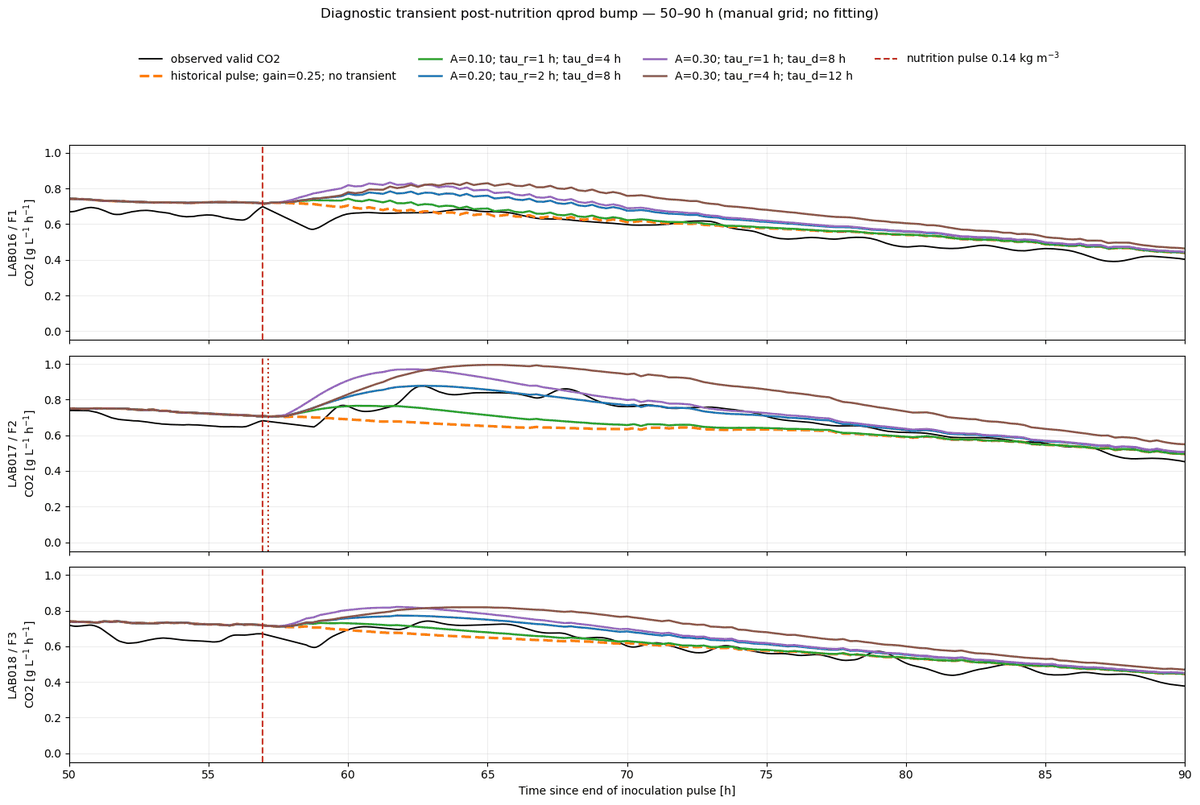

In [41]:
TRANSIENT_ZOOM_TITLE = (
    'Diagnostic transient post-nutrition qprod bump — 50–90 h '
    '(manual grid; no fitting)'
)
transient_colors = ('tab:green', 'tab:blue', 'tab:purple', 'tab:brown')
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True, sharey=True)
for ax, lab in zip(axes, LABS):
    co2 = signals[lab]['co2_filt']
    observed_zoom = (
        co2['time_h'].between(50.0, 90.0)
        & co2['co2_valid_for_fitting']
        & np.isfinite(co2['CO2_obs_g_L_h'])
    )
    ax.plot(
        co2.loc[observed_zoom, 'time_h'],
        co2.loc[observed_zoom, 'CO2_obs_g_L_h'],
        color='black', lw=1.3, label='observed valid CO2',
    )
    cache = npulse_caches[(NPULSE_PRIMARY_VARIANT, lab)]
    ax.plot(
        cache.time_h, transient_historical_predictions[lab],
        color='tab:orange', lw=2.3, ls='--',
        label='historical pulse; gain=0.25; no transient',
    )
    for scenario, color in zip(TRANSIENT_ZOOM_REPRESENTATIVES, transient_colors):
        A_base, tau_rise_h, tau_decay_h = scenario
        ax.plot(
            cache.time_h,
            transient_predictions[(lab, A_base, tau_rise_h, tau_decay_h)],
            color=color, lw=1.8,
            label=(
                f'A={A_base:.2f}; tau_r={tau_rise_h:g} h; '
                f'tau_d={tau_decay_h:g} h'
            ),
        )
    for pulse_number, (pulse_h, amount) in enumerate(npulse_schedules[lab]):
        ax.axvline(
            pulse_h, color='tab:red',
            ls='--' if pulse_number == 0 else ':', lw=1.5,
            label=(
                f'nutrition pulse {amount:.2f} kg m$^{{-3}}$'
                if pulse_number == 0 else None
            ),
        )
    ax.set_xlim(50.0, 90.0)
    ax.set_ylabel(
        f"{lab} / {LABS[lab]['fermenter']}\nCO2 [g L$^{{-1}}$ h$^{{-1}}$]"
    )
    ax.grid(alpha=0.22)
axes[-1].set_xlabel('Time since end of inoculation pulse [h]')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc='upper center', ncol=4,
    frameon=False, bbox_to_anchor=(0.5, 0.955),
)
fig.suptitle(TRANSIENT_ZOOM_TITLE, y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.87))
plt.show()


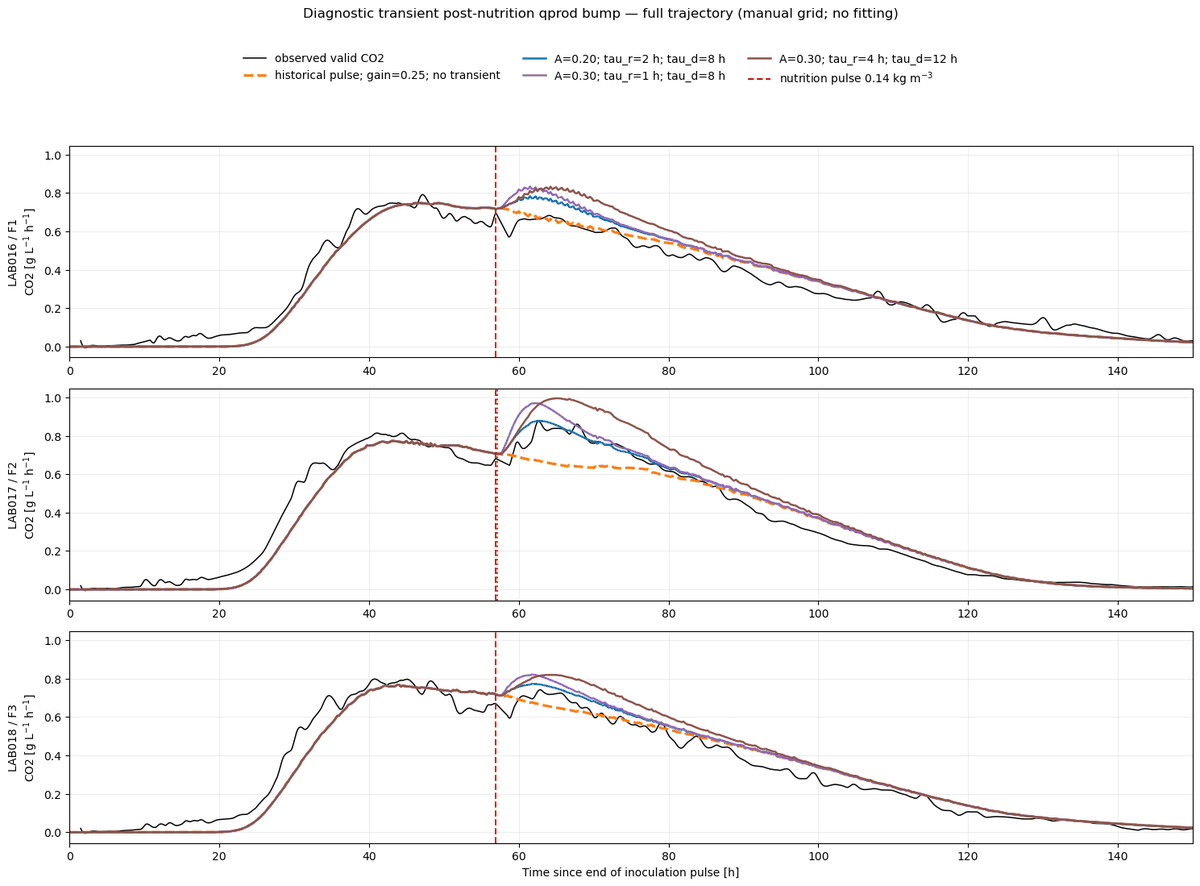

In [42]:
TRANSIENT_FULL_TITLE = (
    'Diagnostic transient post-nutrition qprod bump — full trajectory '
    '(manual grid; no fitting)'
)
full_colors = ('tab:blue', 'tab:purple', 'tab:brown')
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=False, sharey=True)
for ax, lab in zip(axes, LABS):
    co2 = signals[lab]['co2_filt']
    time_obs = co2['time_h'].to_numpy(dtype=float)
    observed = co2['CO2_obs_g_L_h'].to_numpy(dtype=float)
    valid_obs = (
        co2['co2_valid_for_fitting'].to_numpy(dtype=bool)
        & np.isfinite(observed) & (time_obs >= 0.0)
    )
    cache = npulse_caches[(NPULSE_PRIMARY_VARIANT, lab)]
    x_max = min(
        float(np.nanmax(time_obs[time_obs >= 0.0])),
        float(np.nanmax(cache.time_h)),
    )
    ax.plot(
        time_obs[valid_obs], observed[valid_obs],
        color='black', lw=1.1, label='observed valid CO2',
    )
    ax.plot(
        cache.time_h, transient_historical_predictions[lab],
        color='tab:orange', lw=2.3, ls='--',
        label='historical pulse; gain=0.25; no transient',
    )
    for scenario, color in zip(TRANSIENT_FULL_REPRESENTATIVES, full_colors):
        A_base, tau_rise_h, tau_decay_h = scenario
        ax.plot(
            cache.time_h,
            transient_predictions[(lab, A_base, tau_rise_h, tau_decay_h)],
            color=color, lw=1.8,
            label=(
                f'A={A_base:.2f}; tau_r={tau_rise_h:g} h; '
                f'tau_d={tau_decay_h:g} h'
            ),
        )
    for pulse_number, (pulse_h, amount) in enumerate(npulse_schedules[lab]):
        ax.axvline(
            pulse_h, color='tab:red',
            ls='--' if pulse_number == 0 else ':', lw=1.5,
            label=(
                f'nutrition pulse {amount:.2f} kg m$^{{-3}}$'
                if pulse_number == 0 else None
            ),
        )
    ax.set_xlim(0.0, min(150.0, x_max))
    ax.set_ylabel(
        f"{lab} / {LABS[lab]['fermenter']}\nCO2 [g L$^{{-1}}$ h$^{{-1}}$]"
    )
    ax.grid(alpha=0.22)
axes[-1].set_xlabel('Time since end of inoculation pulse [h]')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc='upper center', ncol=3,
    frameon=False, bbox_to_anchor=(0.5, 0.955),
)
fig.suptitle(TRANSIENT_FULL_TITLE, y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()


In [43]:
print('Observed reference metrics (pre-pulse minimum and next-12-h peak):')
display(transient_observed_metrics.round(5))

print('All 27 manual rise-decay combinations plus the frozen historical baseline:')
with pd.option_context(
    'display.max_rows', len(transient_metrics_table),
    'display.max_columns', len(transient_metrics_table.columns),
    'display.width', 220,
):
    display(transient_metrics_table.round(5))

assert theta_frozen == TRANSIENT_THETA_SNAPSHOT
assert co2_parameters_frozen == TRANSIENT_CO2_SNAPSHOT
for lab in LABS:
    pd.testing.assert_frame_equal(
        npulse_predictions[(NPULSE_PRIMARY_VARIANT, lab)],
        TRANSIENT_PRIMARY_SNAPSHOT[lab],
    )
assert np.isclose(co2_parameters_frozen['pulse_activity_gain'], 0.25)
assert np.isclose(co2_parameters_frozen['pulse_t_rise_h'], 64.7, atol=0.1)
assert len(transient_predictions) == len(LABS) * len(TRANSIENT_SCENARIOS)
print(
    'TRANSIENT BUMP VALIDATION PASSED — frozen theta/CO2 parameters and '
    'historical pulse predictions unchanged; no fitting performed.'
)


Observed reference metrics (pre-pulse minimum and next-12-h peak):


      LAB  minimum_prepulse_g_L_h  peak_postpulse_g_L_h  reactivation_pct  \
0  LAB016                 0.62302               0.68314           9.64995   
1  LAB017                 0.64613               0.87610          35.59251   
2  LAB018                 0.61726               0.74176          20.17047   

   hours_to_postpulse_peak  qCO2_120h_g_L_h  qCO2_150h_g_L_h  
0                  7.07778          0.16042          0.03092  
1                  5.71250          0.07699          0.01299  
2                  5.91278          0.10613          0.01838  

All 27 manual rise-decay combinations plus the frozen historical baseline:


       LAB                            scenario  A_base  tau_rise_h  tau_decay_h  minimum_prepulse_g_L_h  peak_postpulse_g_L_h  reactivation_pct  hours_to_postpulse_peak  RMSE_50_90h  qCO2_120h_g_L_h  qCO2_150h_g_L_h
0   LAB016  historical gain=0.25; no transient     0.0         NaN          NaN                 0.71951               0.72083           0.18277                  0.31444      0.04831          0.13634          0.02295
1   LAB016         A=0.10; rise=1 h; decay=4 h     0.1         1.0          4.0                 0.71951               0.74318           3.28845                  3.06444      0.05484          0.13634          0.02295
2   LAB016         A=0.10; rise=1 h; decay=8 h     0.1         1.0          8.0                 0.71951               0.74240           3.18116                  3.06444      0.05864          0.13636          0.02295
3   LAB016        A=0.10; rise=1 h; decay=12 h     0.1         1.0         12.0                 0.71951               0.74138           

TRANSIENT BUMP VALIDATION PASSED — frozen theta/CO2 parameters and historical pulse predictions unchanged; no fitting performed.


### Structural interpretation

1. **Can a transient rise-decay response reproduce the LAB017 bump without destroying the tail?** Yes. As a diagnostic example, `A=0.30`, `tau_rise=2 h`, `tau_decay=4 h` gives 35.74% reactivation versus 35.59% observed. Its peak occurs 4.82 h after the first nutrition event versus 5.71 h observed, while qCO2 at 150 h returns to 0.00538 g L⁻¹ h⁻¹, identical to the historical gain=0.25 trajectory (observed: 0.01299).

2. **What order of magnitude appears necessary?** Within this finite manual grid, the relevant scale is `A ≈ 0.30` per 0.14 kg m⁻³ pulse, a rise time of a few hours (`tau_rise ≈ 2–4 h`), and a short decay (`tau_decay ≈ 4 h`). These are diagnostic scales, not calibrated parameters.

3. **Does the double F2 dose naturally generate a larger response?** Yes. For `A=0.30`, `tau_rise=2 h`, `tau_decay=4 h`, reactivation is 35.74% in F2, compared with 15.36% in F1 and 13.88% in F3. The summed, dose-scaled pulse contributions therefore amplify F2 without a fermenter-specific gain.

4. **Is there a combination that gives a clear F2 response, a small or null F1/F3 response, and then returns to gain=0.25 termination?** No combination in the tested grid satisfies all three conditions. The short-decay cases return to the historical tail, but the `A ≈ 0.30` cases needed for the ~35% F2 bump still create moderate ~14–16% responses in F1/F3.

5. **Structural implication.** The transient multiplier can explain LAB017 amplitude and timing without a permanent tail penalty, but it cannot reproduce the apparent fermenter selectivity. If that selectivity is required, the next structural question is how N changes the upstream state/production response rather than adding another universal multiplicative gain.

This diagnostic is **not a new calibration**. It tests: nutrition → rapid reactivation → transient peak → decay of the nutrition effect → return to the historical gain=0.25 termination trajectory. No optimizer or automatic parameter selection was used.


## Comparación con fermentaciones históricas a ~20 °C

Esta sección es exclusivamente exploratoria: no recalibra, ajusta ni ejecuta el modelo. LAB016–LAB018 conservan su origen temporal documentado (`t = 0`, fin del pulso real de inoculación). Para LAB001, LAB002 y LAB290226 no hay un timestamp de inoculación homologado en los artefactos usados aquí; por ello se adopta como ancla explícita el primer registro comparable de CO₂ y la alineación se considera aproximada.

Todas las señales de CO₂ se expresan con la misma conversión oficial del logger (SCCM → g L⁻¹ h⁻¹, volumen de trabajo de 2 L y factor 0.74). LAB001/LAB002 usan sus fragmentos filtrados ya existentes; LAB290226 usa la misma cascada causal Hampel + Butterworth documentada en el notebook histórico. Las medianas de 5 min se usan solo para hacer legibles las figuras y no modifican ningún dato crudo.

**Cautelas de comparabilidad.** El repositorio marca LAB001/LAB002 como perfiles de CO₂ no confiables para calibración, de modo que aquí son contexto visual, no evidencia cuantitativa. Además, el registro cosido de LAB001 muestra SP 18→21 °C (no 21 °C isotérmico durante toda la cobertura); LAB002 sí está a SP 21 °C durante su registro comparable. LAB290226 incluye una fase extensa a 20 °C, pero parte a 23 °C y el medio no está plenamente documentado.


Loaded without modifying raw data; 1 SCCM = 0.04044 g L^-1 h^-1


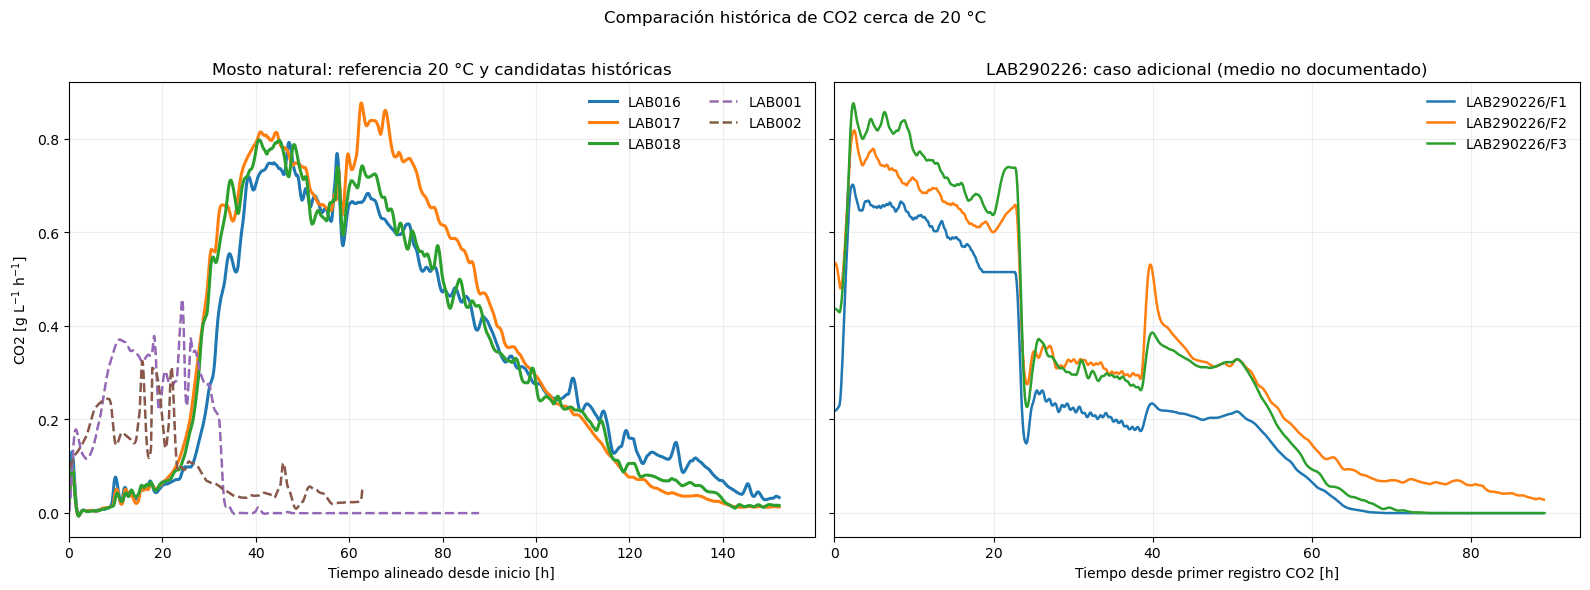

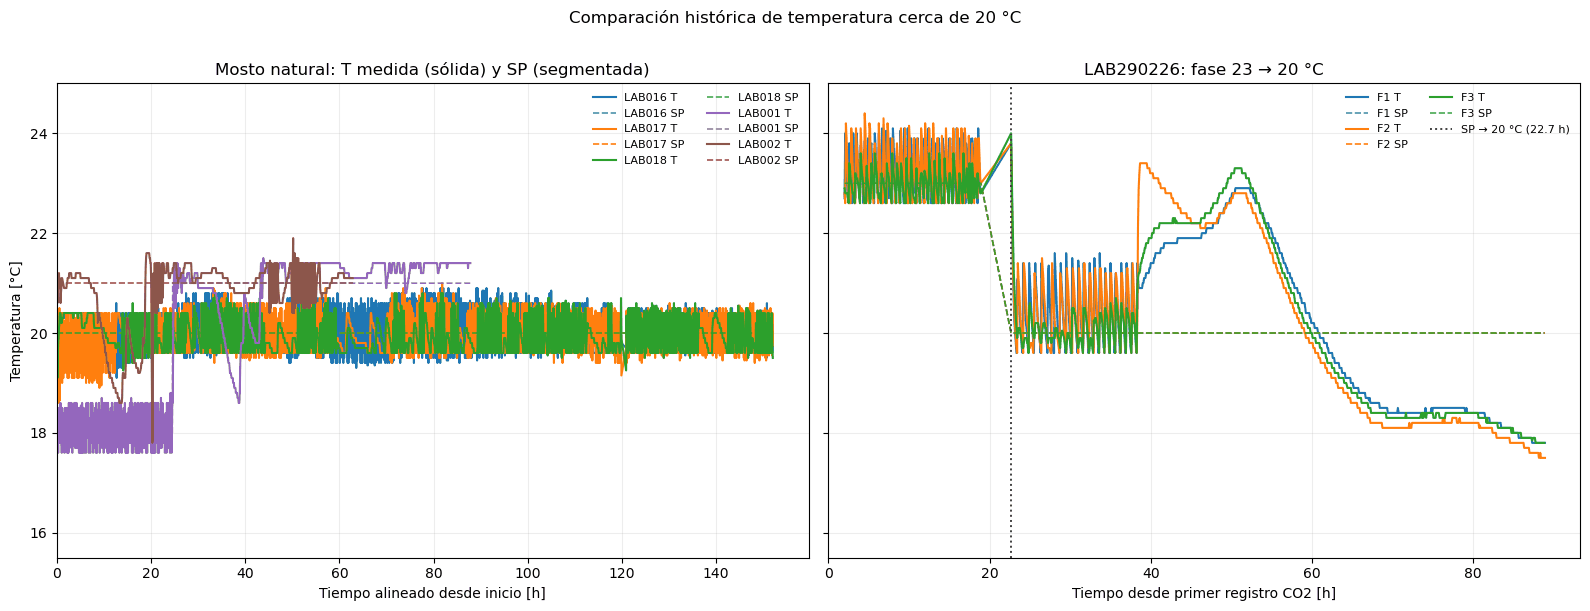

,experimento,tipo de medio,programa térmico resumido,duración aproximada [h],comparabilidad con LAB016–018
0,LAB016/F1,mosto natural (confirmado),20 °C isotérmico,152.1,referencia principal; misma campaña y setpoint
1,LAB017/F2,mosto natural (confirmado),20 °C isotérmico,152.1,referencia principal; misma campaña y setpoint
2,LAB018/F3,mosto natural (confirmado),20 °C isotérmico,152.1,referencia principal; misma campaña y setpoint
3,LAB001/F1,mosto natural; descriptivo,SP 18 → 21 °C; 21 °C desde ~24.6 h,87.9,secundaria; no isotérmica y CO2 excluido por QC
4,LAB002/F2,mosto natural; descriptivo,21 °C durante la cobertura CO2,62.9,mejor candidata térmica; CO2 excluido por QC
5,LAB290226/F1–F3,no plenamente documentado en el repo,SP 23 → 20 °C desde ~22.7 h,89.3,contexto térmico secundario; medio/programa inicial distintos


In [3]:
from collections import deque
from scipy import signal as scipy_signal

HIST_RAW = FM / 'data' / 'Laboratorio 2026' / 'raw_data'
HIST_290 = FM / 'data' / 'mem2026' / 'LAB290226'
SCCM_TO_G_L_H = 44.0095 * 60.0 * 0.74 / (1000.0 * 24.16 * 2.0)
PLOT_BIN_H = 5.0 / 60.0

def stitch_history(paths, columns):
    frames = []
    for order, path in enumerate(paths):
        if not path.exists():
            raise FileNotFoundError(path)
        frame = pd.read_csv(path, parse_dates=['timestamp'])
        missing = set(columns).difference(frame.columns)
        if missing:
            raise ValueError(f'{path.name}: missing {sorted(missing)}')
        frames.append(frame[['timestamp', *columns]].assign(_order=order))
    return (
        pd.concat(frames, ignore_index=True)
        .dropna(subset=['timestamp'])
        .sort_values(['timestamp', '_order'])
        .drop_duplicates('timestamp', keep='last')
        .drop(columns='_order')
        .reset_index(drop=True)
    )

def elapsed_history(frame, t0):
    out = frame.copy()
    out['time_h'] = (out['timestamp'] - pd.Timestamp(t0)).dt.total_seconds() / 3600.0
    return out[out['time_h'].ge(0.0)].reset_index(drop=True)

def plot_view(frame, columns):
    out = frame[['time_h', *columns]].replace([np.inf, -np.inf], np.nan)
    out = out.dropna(subset=['time_h'])
    out = out[out['time_h'].ge(0.0)].copy()
    out['_bin'] = np.floor(out['time_h'] / PLOT_BIN_H) * PLOT_BIN_H
    return out.groupby('_bin', as_index=False)[columns].median().rename(
        columns={'_bin': 'time_h'}
    )

def causal_history_filter(timestamp, values):
    # Fixed historical audit: causal Hampel 120 s/k=3.5/min=0.5 SCCM,
    # followed by causal Butterworth tau=1200 s/order=3, all in SCCM.
    values = np.asarray(values, dtype=float)
    dt_s = np.diff(pd.to_datetime(timestamp).to_numpy())
    sample_s = float(np.median(dt_s.astype('timedelta64[ns]').astype(float) / 1e9))
    buffer = deque(maxlen=max(1, int(round(120.0 / sample_s))))
    despiked = np.empty_like(values)
    for i, value in enumerate(values):
        buffer.append(float(value))
        if len(buffer) < 3:
            despiked[i] = value
            continue
        local = np.asarray(buffer)
        median = float(np.median(local))
        sigma = 1.4826 * float(np.median(np.abs(local - median)))
        despiked[i] = median if abs(value - median) > max(3.5 * sigma, 0.5) else value
    fs_hz = 1.0 / sample_s
    cutoff_hz = 1.0 / (2.0 * np.pi * 1200.0)
    wn = min(max(cutoff_hz / (fs_hz / 2.0), 1e-8), 0.999999)
    sos = scipy_signal.butter(3, wn, btype='low', output='sos')
    filtered, _ = scipy_signal.sosfilt(
        sos, despiked, zi=scipy_signal.sosfilt_zi(sos) * despiked[0]
    )
    return filtered

def inoculation_time(row):
    time_part = row['Hora']
    if not hasattr(time_part, 'hour'):
        time_part = pd.to_datetime(str(time_part)).time()
    return pd.Timestamp.combine(pd.Timestamp(row['Fecha']).date(), time_part)

history_runs = {}
for lab in LABS:
    t0 = inoculation_time(
        initial_sheet.loc[initial_sheet['CodigoLab'].eq(lab)].iloc[0]
    )
    co2 = elapsed_history(signals[lab]['co2_filt'].copy(), t0)
    temp = elapsed_history(signals[lab]['temp'].copy(), t0)
    co2['qCO2_g_L_h'] = pd.to_numeric(
        co2['flow_filt_sccm'], errors='coerce'
    ) * SCCM_TO_G_L_H
    history_runs[lab] = {'co2': co2, 'temp': temp, 't0': t0}

legacy = {
    'LAB001': (
        [
            HIST_RAW / 'CO2_FILT_lab001_28_03_26_1700.csv',
            HIST_RAW / 'lab001_co2f_pt2.csv',
            FM / 'data' / 'Laboratorio 2026' / 'Vendimia_2026' / 'Lote_1'
            / 'LAB001' / 'CO2_FILT_F1_lab001_pt3.csv',
        ],
        [
            HIST_RAW / 'ing26_lab001.csv',
            HIST_RAW / 'lab001_T_pt2.csv',
            HIST_RAW / 'Temp_F1_lab001_pt3.csv',
        ],
    ),
    'LAB002': (
        [
            HIST_RAW / 'CO2_FILT_lab002_29_03_26_1700.csv',
            HIST_RAW / 'lab002_co2f_pt2.csv',
            HIST_RAW / 'Desktop_CyT_Tablero_Proceso'
            / 'CO2_FILT_F2_lab002_pt3.csv',
        ],
        [
            HIST_RAW / 'ing26_lab002.csv',
            HIST_RAW / 'lab002_T_pt2.csv',
            HIST_RAW / 'Temp_F2_lab002_pt3.csv',
        ],
    ),
}
for lab, (co2_paths, temp_paths) in legacy.items():
    raw_co2 = stitch_history(co2_paths, ['flow_filt_sccm'])
    t0 = raw_co2['timestamp'].min()
    co2 = elapsed_history(raw_co2, t0)
    co2['qCO2_g_L_h'] = co2['flow_filt_sccm'] * SCCM_TO_G_L_H
    history_runs[lab] = {
        'co2': co2,
        'temp': elapsed_history(stitch_history(temp_paths, ['T', 'SP']), t0),
        't0': t0,
    }

history_290 = {}
for fermenter in ('F1', 'F2', 'F3'):
    raw_co2 = pd.read_csv(
        HIST_290 / f'{fermenter}_co2.csv', parse_dates=['timestamp']
    ).sort_values('timestamp')
    t0 = raw_co2['timestamp'].min()
    filtered = causal_history_filter(raw_co2['timestamp'], raw_co2['flow_sccm'])
    co2 = elapsed_history(
        raw_co2[['timestamp']].assign(qCO2_g_L_h=filtered * SCCM_TO_G_L_H), t0
    )
    raw_temp = pd.read_csv(
        HIST_290 / f'Temp_{fermenter}.csv', parse_dates=['timestamp']
    ).sort_values('timestamp')
    history_290[fermenter] = {
        'co2': co2,
        'temp': elapsed_history(raw_temp[['timestamp', 'T', 'SP']], t0),
    }

assert np.isclose(SCCM_TO_G_L_H, 0.04044, atol=5e-5)
print(f'Loaded without modifying raw data; 1 SCCM = {SCCM_TO_G_L_H:.5f} g L^-1 h^-1')

history_colors = {
    'LAB016': 'tab:blue', 'LAB017': 'tab:orange', 'LAB018': 'tab:green',
    'LAB001': 'tab:purple', 'LAB002': 'tab:brown',
}
fig, axes = plt.subplots(1, 2, figsize=(16, 5.8), sharey=True)
for lab in ('LAB016', 'LAB017', 'LAB018', 'LAB001', 'LAB002'):
    view = plot_view(history_runs[lab]['co2'], ['qCO2_g_L_h'])
    axes[0].plot(
        view['time_h'], view['qCO2_g_L_h'], color=history_colors[lab],
        lw=2.2 if lab in LABS else 1.8,
        ls='-' if lab in LABS else '--', label=lab,
    )
axes[0].set_title('Mosto natural: referencia 20 °C y candidatas históricas')
axes[0].set_xlabel('Tiempo alineado desde inicio [h]')
axes[0].set_ylabel('CO2 [g L$^{-1}$ h$^{-1}$]')
axes[0].legend(ncol=2, frameon=False)
for fermenter, color in zip(
    ('F1', 'F2', 'F3'), ('tab:blue', 'tab:orange', 'tab:green')
):
    view = plot_view(history_290[fermenter]['co2'], ['qCO2_g_L_h'])
    axes[1].plot(
        view['time_h'], view['qCO2_g_L_h'], color=color, lw=1.8,
        label=f'LAB290226/{fermenter}',
    )
axes[1].set_title('LAB290226: caso adicional (medio no documentado)')
axes[1].set_xlabel('Tiempo desde primer registro CO2 [h]')
axes[1].legend(frameon=False)
for ax in axes:
    ax.set_xlim(left=0.0)
    ax.grid(alpha=0.22)
fig.suptitle('Comparación histórica de CO2 cerca de 20 °C', y=1.01)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6.0), sharey=True)
for lab in ('LAB016', 'LAB017', 'LAB018', 'LAB001', 'LAB002'):
    view = plot_view(history_runs[lab]['temp'], ['T', 'SP'])
    color = history_colors[lab]
    axes[0].plot(view['time_h'], view['T'], color=color, lw=1.5, label=f'{lab} T')
    axes[0].plot(
        view['time_h'], view['SP'], color=color, lw=1.2, ls='--',
        alpha=0.9, label=f'{lab} SP',
    )
axes[0].set_title('Mosto natural: T medida (sólida) y SP (segmentada)')
axes[0].set_xlabel('Tiempo alineado desde inicio [h]')
axes[0].set_ylabel('Temperatura [°C]')
axes[0].legend(ncol=2, fontsize=8, frameon=False)
transition_hours = []
for fermenter, color in zip(
    ('F1', 'F2', 'F3'), ('tab:blue', 'tab:orange', 'tab:green')
):
    temp = history_290[fermenter]['temp']
    view = plot_view(temp, ['T', 'SP'])
    axes[1].plot(view['time_h'], view['T'], color=color, lw=1.5, label=f'{fermenter} T')
    axes[1].plot(
        view['time_h'], view['SP'], color=color, lw=1.2, ls='--',
        alpha=0.9, label=f'{fermenter} SP',
    )
    at_20 = temp.loc[pd.to_numeric(temp['SP'], errors='coerce').eq(20.0), 'time_h']
    if not at_20.empty:
        transition_hours.append(float(at_20.min()))
transition_h = float(np.median(transition_hours))
axes[1].axvline(
    transition_h, color='0.25', ls=':', lw=1.4,
    label=f'SP → 20 °C ({transition_h:.1f} h)',
)
axes[1].set_title('LAB290226: fase 23 → 20 °C')
axes[1].set_xlabel('Tiempo desde primer registro CO2 [h]')
axes[1].legend(ncol=2, fontsize=8, frameon=False)
for ax in axes:
    ax.set_xlim(left=0.0)
    ax.set_ylim(15.5, 25.0)
    ax.grid(alpha=0.22)
fig.suptitle('Comparación histórica de temperatura cerca de 20 °C', y=1.01)
fig.tight_layout()
plt.show()

history_summary = pd.DataFrame([
    {
        'experimento': f'{lab}/{LABS[lab]["fermenter"]}',
        'tipo de medio': 'mosto natural (confirmado)',
        'programa térmico resumido': '20 °C isotérmico',
        'duración aproximada [h]': history_runs[lab]['co2']['time_h'].max(),
        'comparabilidad con LAB016–018': 'referencia principal; misma campaña y setpoint',
    }
    for lab in ('LAB016', 'LAB017', 'LAB018')
] + [
    {
        'experimento': 'LAB001/F1',
        'tipo de medio': 'mosto natural; descriptivo',
        'programa térmico resumido': 'SP 18 → 21 °C; 21 °C desde ~24.6 h',
        'duración aproximada [h]': history_runs['LAB001']['co2']['time_h'].max(),
        'comparabilidad con LAB016–018': 'secundaria; no isotérmica y CO2 excluido por QC',
    },
    {
        'experimento': 'LAB002/F2',
        'tipo de medio': 'mosto natural; descriptivo',
        'programa térmico resumido': '21 °C durante la cobertura CO2',
        'duración aproximada [h]': history_runs['LAB002']['co2']['time_h'].max(),
        'comparabilidad con LAB016–018': 'mejor candidata térmica; CO2 excluido por QC',
    },
    {
        'experimento': 'LAB290226/F1–F3',
        'tipo de medio': 'no plenamente documentado en el repo',
        'programa térmico resumido': f'SP 23 → 20 °C desde ~{transition_h:.1f} h',
        'duración aproximada [h]': max(
            item['co2']['time_h'].max() for item in history_290.values()
        ),
        'comparabilidad con LAB016–018': 'contexto térmico secundario; medio/programa inicial distintos',
    },
])
history_summary['duración aproximada [h]'] = (
    history_summary['duración aproximada [h]'].round(1)
)
display(history_summary)


### Resumen térmico

LAB016, LAB017 y LAB018 son las referencias directamente comparables: mosto natural, misma campaña y 20 °C isotérmicos. Entre las corridas históricas adicionales, **LAB002** es la más cercana desde el punto de vista térmico porque su cobertura comparable permanece a 21 °C, aunque su CO₂ solo debe leerse de forma exploratoria por los problemas de calidad ya documentados. **LAB001** aporta contexto de mosto natural, pero su programa registrado 18→21 °C impide tratarla como isotérmica equivalente. **LAB290226** es una referencia térmica secundaria por su fase a 20 °C; el tramo inicial a 23 °C y la falta de documentación completa del medio limitan cualquier comparación más fuerte.
